## Exploratory Data Analysis of Large-Scale Retail Transaction Data Using Univariate, Bivariate, and Multivariate Statistical Techniques 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
sns.set_style('whitegrid')

In [4]:
FILE_PATH = r'D:\Awantika\Data Science Class notes\Basics_Python\Basics_Python\retail_large_dataset.csv'

In [5]:
df = pd.read_csv(FILE_PATH)

In [6]:
df

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,C109995,29,Female,Pune,Maharashtra,Regular,O149995,2024-06-11,Health,Supplements,49293,1,11,43870.77,Debit Card,Standard,9,No
99996,C109996,28,Male,Mumbai,Maharashtra,Premium,O149996,2024-04-27,Fashion,Men T-Shirt,5722,2,22,8926.32,Cash on Delivery,Express,1,No
99997,C109997,44,Female,Jaipur,Rajasthan,Premium,O149997,2024-04-14,Grocery,Snacks,6311,4,11,22467.16,Cash on Delivery,Express,9,No
99998,C109998,45,Male,Jaipur,Rajasthan,Premium,O149998,2024-09-08,Beauty,Shampoo,46888,1,28,33759.36,Debit Card,Standard,1,No


In [7]:
df.head()

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No


In [8]:
df.tail()

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
99995,C109995,29,Female,Pune,Maharashtra,Regular,O149995,2024-06-11,Health,Supplements,49293,1,11,43870.77,Debit Card,Standard,9,No
99996,C109996,28,Male,Mumbai,Maharashtra,Premium,O149996,2024-04-27,Fashion,Men T-Shirt,5722,2,22,8926.32,Cash on Delivery,Express,1,No
99997,C109997,44,Female,Jaipur,Rajasthan,Premium,O149997,2024-04-14,Grocery,Snacks,6311,4,11,22467.16,Cash on Delivery,Express,9,No
99998,C109998,45,Male,Jaipur,Rajasthan,Premium,O149998,2024-09-08,Beauty,Shampoo,46888,1,28,33759.36,Debit Card,Standard,1,No
99999,C109999,19,Male,Kolkata,West Bengal,New,O149999,2025-11-15,Health,Supplements,37361,3,3,108720.51,Credit Card,Standard,2,No


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   customer_id          100000 non-null  object 
 1   age                  100000 non-null  int64  
 2   gender               100000 non-null  object 
 3   city                 100000 non-null  object 
 4   state                100000 non-null  object 
 5   customer_segment     100000 non-null  object 
 6   order_id             100000 non-null  object 
 7   order_date           100000 non-null  object 
 8   product_category     100000 non-null  object 
 9   product_subcategory  100000 non-null  object 
 10  product_price        100000 non-null  int64  
 11  quantity             100000 non-null  int64  
 12  discount_percentage  100000 non-null  int64  
 13  final_price          100000 non-null  float64
 14  payment_method       100000 non-null  object 
 15  shipping_type     

In [15]:
ID_COLS = ['customer_id', 'order_id']
DATE_COLS = ['order_date']

In [16]:
ID_COLS 

['customer_id', 'order_id']

In [17]:
DATE_COLS

['order_date']

In [12]:
NUMERIC_COLS = ['age', 'product_price', 'quantity',
                'discount_percentage', 'final_price', 'delivery_days']

In [20]:
NUMERIC_COLS 

['age',
 'product_price',
 'quantity',
 'discount_percentage',
 'final_price',
 'delivery_days']

In [11]:
CATEGORICAL_COLS = ['gender', 'city', 'state', 'customer_segment',
                     'product_category', 'product_subcategory',
                     'payment_method', 'shipping_type', 'return_status']

In [22]:
CATEGORICAL_COLS

['gender',
 'city',
 'state',
 'customer_segment',
 'product_category',
 'product_subcategory',
 'payment_method',
 'shipping_type',
 'return_status']

In [7]:
df

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,C109995,29,Female,Pune,Maharashtra,Regular,O149995,2024-06-11,Health,Supplements,49293,1,11,43870.77,Debit Card,Standard,9,No
99996,C109996,28,Male,Mumbai,Maharashtra,Premium,O149996,2024-04-27,Fashion,Men T-Shirt,5722,2,22,8926.32,Cash on Delivery,Express,1,No
99997,C109997,44,Female,Jaipur,Rajasthan,Premium,O149997,2024-04-14,Grocery,Snacks,6311,4,11,22467.16,Cash on Delivery,Express,9,No
99998,C109998,45,Male,Jaipur,Rajasthan,Premium,O149998,2024-09-08,Beauty,Shampoo,46888,1,28,33759.36,Debit Card,Standard,1,No


In [24]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

In [25]:
df['order_date']

0       2025-05-10
1       2023-11-27
2       2025-02-08
3       2024-04-19
4       2024-10-08
           ...    
99995   2024-06-11
99996   2024-04-27
99997   2024-04-14
99998   2024-09-08
99999   2025-11-15
Name: order_date, Length: 100000, dtype: datetime64[ns]

In [28]:
print("Shape:", df.shape)

Shape: (100000, 18)


#### From shape function we can get number of rows as 100000 and number of column as 18

In [29]:
print("\nMissing values:\n", df.isna().sum())


Missing values:
 customer_id            0
age                    0
gender                 0
city                   0
state                  0
customer_segment       0
order_id               0
order_date             0
product_category       0
product_subcategory    0
product_price          0
quantity               0
discount_percentage    0
final_price            0
payment_method         0
shipping_type          0
delivery_days          0
return_status          0
dtype: int64


#### No Missing values

In [12]:
df.dtypes

customer_id                    object
age                             int64
gender                         object
city                           object
state                          object
customer_segment               object
order_id                       object
order_date             datetime64[ns]
product_category               object
product_subcategory            object
product_price                   int64
quantity                        int64
discount_percentage             int64
final_price                   float64
payment_method                 object
shipping_type                  object
delivery_days                   int64
return_status                  object
dtype: object

In [76]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
99995    False
99996    False
99997    False
99998    False
99999    False
Length: 100000, dtype: bool

# UNIVARIATE ANALYSIS

## 1. UNIVARIATE ANALYSIS - NUMERIC COLUMNS

In [22]:
df.describe()

,age,order_date,product_price,quantity,discount_percentage,final_price,delivery_days
count,100000.000000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.561830,2024-06-29 02:48:38.304000,30164.526720,2.501790,15.009890,64165.723382,5.505540
min,18.000000,2023-01-01 00:00:00,500.000000,1.000000,0.000000,357.000000,1.000000
25%,30.000000,2023-09-30 00:00:00,15375.000000,1.000000,7.000000,24705.000000,3.000000
50%,42.000000,2024-06-28 00:00:00,30148.000000,3.000000,15.000000,49752.390000,5.000000
75%,54.000000,2025-03-30 00:00:00,44957.000000,4.000000,23.000000,94046.070000,8.000000
max,65.000000,2025-12-30 00:00:00,59998.000000,4.000000,30.000000,239980.000000,10.000000
std,13.852439,NaN,17139.679807,1.120058,8.953296,49969.280150,2.872868


#### Age, product_price, quantity, discount_percentage, delivery_days: skew ≈ 0, mean ≈ median → these are roughly uniformly distributed (likely synthetically generated with round min/max bounds).
#### Final_price: skew = 0.93 (mean 64,165 >> median 49,752) → this column is right-skewed, meaning most values are lower but a long tail of high values pulls the mean up. Makes sense since it's probably derived by multiplying price × quantity × discount, which naturally creates skew.

### Histogram Plot , Boxplot Plot , Density plot

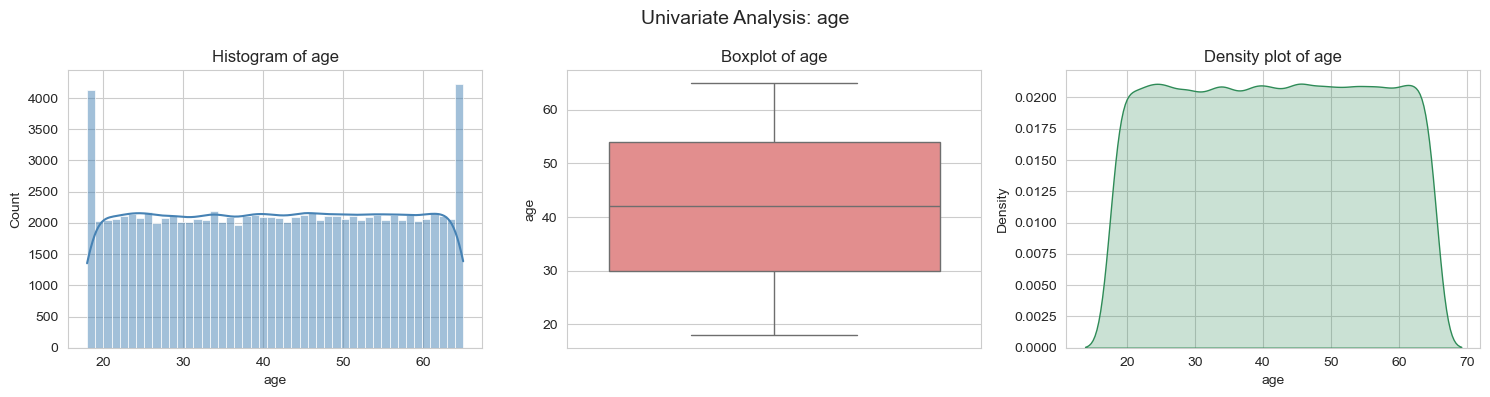

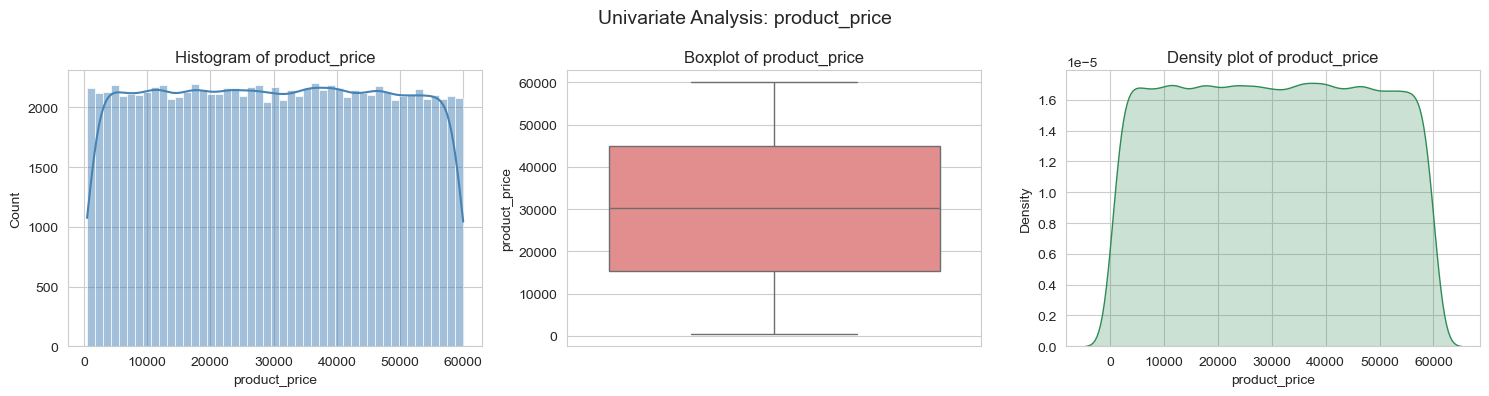

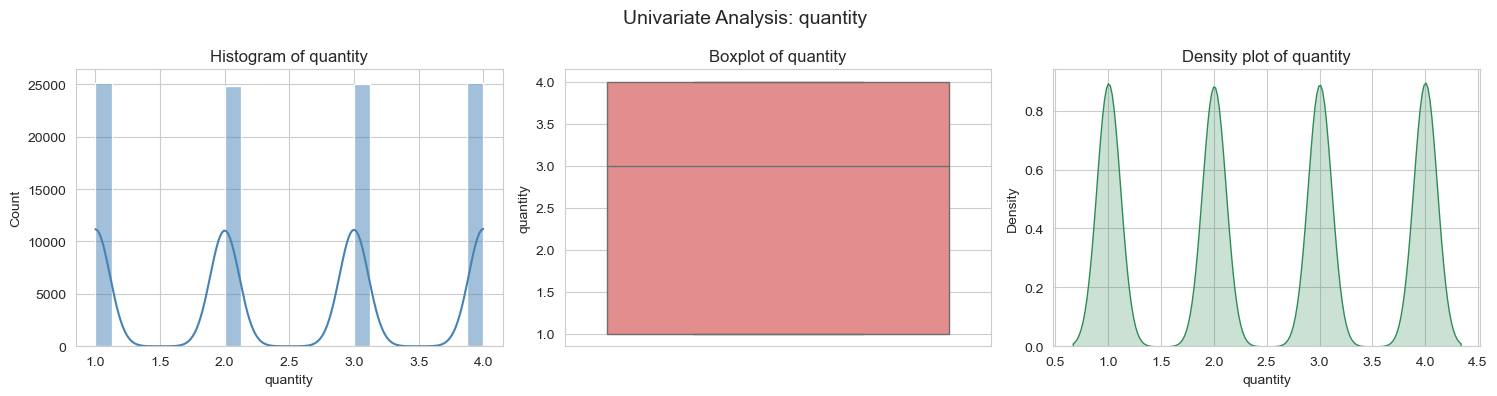

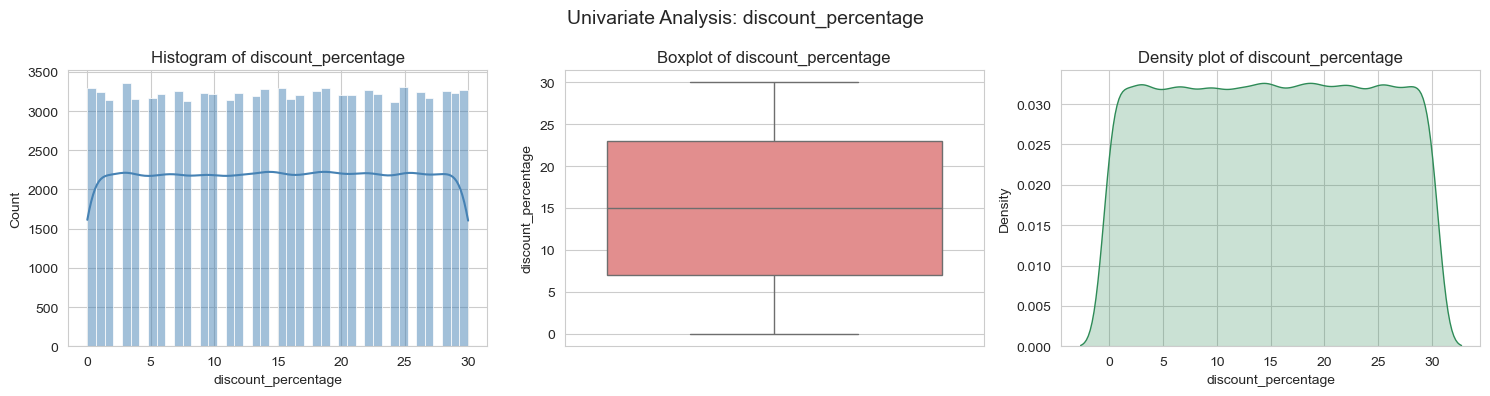

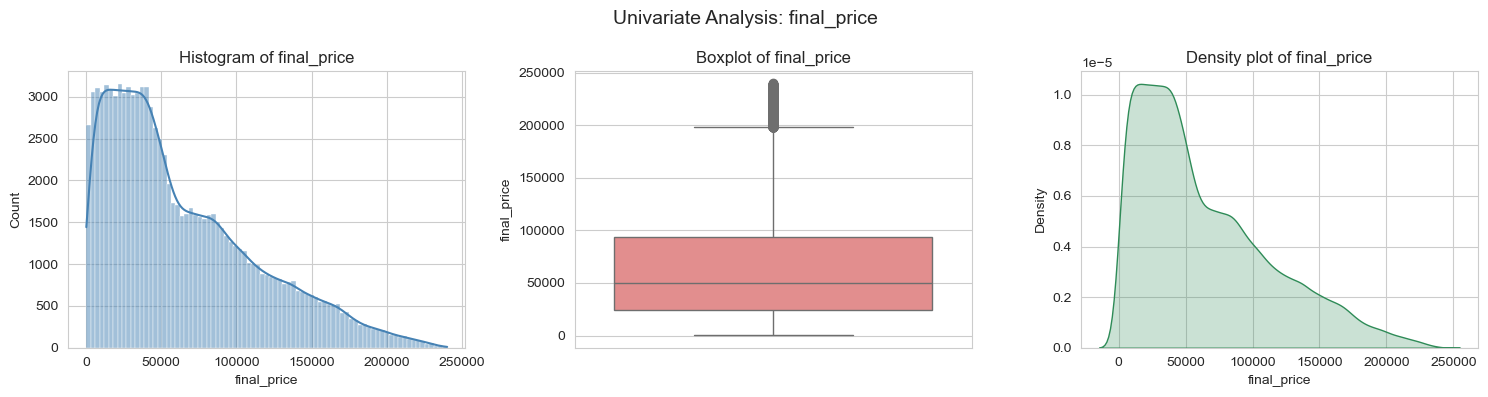

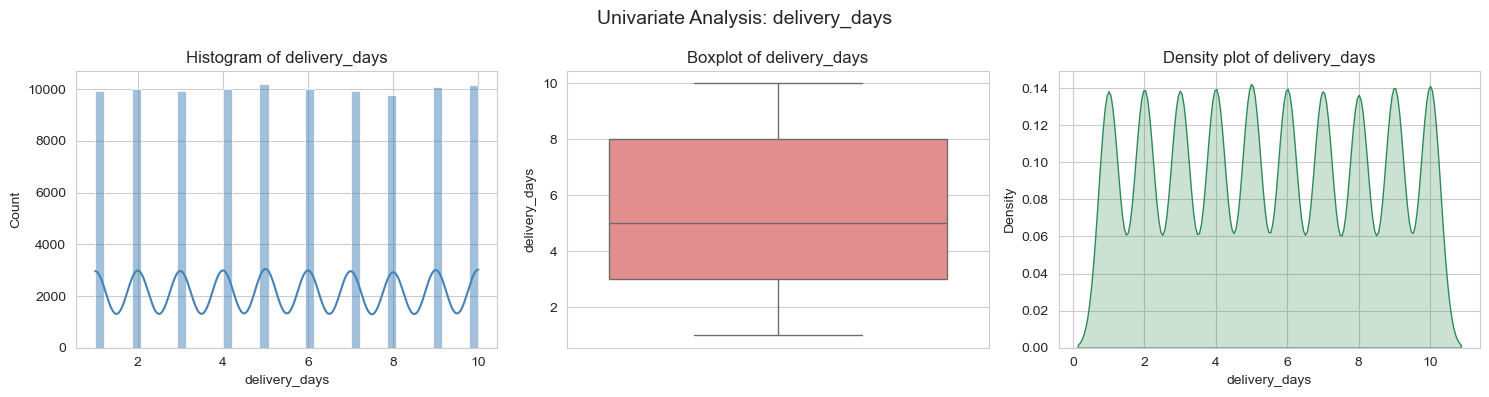

In [34]:
def univariate_numeric(df, cols):
    for col in cols:
        data = df[col].dropna()

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
        axes[0].set_title(f'Histogram of {col}')
 
        sns.boxplot(y=data, ax=axes[1], color='lightcoral')
        axes[1].set_title(f'Boxplot of {col}')
 
        sns.kdeplot(data, fill=True, ax=axes[2], color='seagreen')
        axes[2].set_title(f'Density plot of {col}')
 
        fig.suptitle(f'Univariate Analysis: {col}', fontsize=14)
        plt.tight_layout()
        plt.show()
univariate_numeric(df, NUMERIC_COLS)    

### Age : 

#### Histogram: Fairly flat/uniform distribution between 18–65, with two odd spikes at the min (18) and max (65) edges — likely boundary artifacts from how the data was generated (e.g., clipping or rounding at the limits).

#### Boxplot: Median ~42, IQR roughly 30–54, no outliers, whiskers stretch to the true min/max (18 and 65) — consistent with a uniform spread and zero skew.

#### Density plot (KDE): Roughly flat "plateau" shape between 20–60 with soft tapering at the edges — the smoothed version of the histogram, reinforcing that age is close to uniformly distributed rather than normally distributed (no bell curve).

### Product Price

#### Histogram: Flat and even from 500–60,000, with no real peak — classic uniform shape, just slight tapering at the very edges.

#### Boxplot: Median 30,000 sits almost dead-center of the IQR (15,000–45,000), whiskers stretch to true min/max with no outliers — again typical of a uniform spread, not a normal or skewed one.

#### Density plot: Flat plateau across the whole range with soft edges — smooth version of the histogram, no bell curve or long tail.

#### Takeaway: product_price is uniformly distributed across its full range (500–59,998), matching its skew ≈ 0. No unusual outliers or concentration — every price point is roughly equally likely.

### Quantity

#### Histogram: Four distinct bars at exactly 1, 2, 3, 4 — each roughly equal in count (25,000 each), confirming quantity only takes these 4 integer values with equal probability (uniform discrete distribution).

#### Boxplot: The box spans the full range (1 to 4) with median at 3 — this looks unusual/flat because with only 4 equally-likely discrete values, the quartiles land near the extremes rather than forming a typical box shape. It's not wrong, just a quirk of visualizing discrete uniform data as a boxplot.

#### Density plot (KDE): Shows 4 separate peaks at 1, 2, 3, 4 with dips between them — this is a smoothing artifact. 

#### Takeaway: quantity is a discrete uniform variable (values 1–4, equal frequency). The boxplot and density plot aren't ideal choices for this kind of data — a simple bar chart of value counts would represent it more accurately than histogram/KDE/boxplot.

### Discount Percentage

#### Histogram: Flat and even across 0–30, no dominant peak — consistent with a uniform distribution, just like age and product_price.

#### Boxplot: Median = 15 sits right in the middle, IQR ~7–23 evenly spread, whiskers reach the true min/max (0–30), no outliers — textbook symmetric/uniform spread.

#### Density plot: Flat plateau between 0–30 with smooth tapering at edges — reinforces the uniform shape, no skew or peak.

#### Takeaway: discount_percentage is uniformly distributed between 0–30%, matching its skew ≈ 0. Every discount value in that range is roughly equally likely — no unusual concentration or outliers.

### Final Price

#### Histogram: Peaks early (around 20,000–40,000) then tapers off into a long tail stretching out to 240,000 — classic right-skewed shape, not flat like the other columns.

#### Boxplot: Median (50,000) sits closer to the bottom of the box, and there's a cluster of outliers above ~200,000 (shown as dots) — confirming a long right tail with some extreme high values.

#### Density plot: Sharp rise, peak near the low end, then a gradually decaying tail to the right — again, textbook right-skew (not symmetric like age/price/discount).

#### Takeaway: final_price behaves very differently from the other columns — most orders have lower final prices, but a smaller number of high-value orders pull the distribution's tail out and create actual outliers. This makes sense if it's derived from multiplying price × quantity × discount factor (products of uniforms compound into skew). For this column, median is a better "typical value" than mean, and you may want to treat those upper outliers separately (cap, log-transform, or investigate them) before modeling.

### Delivery Days

#### Histogram: 10 evenly-spaced spikes at integers 1–10, each with roughly equal count (10,000) — confirms delivery_days only takes whole-day values, uniformly distributed.

#### Boxplot: Median = 5, IQR spans 3–8, whiskers reach true min/max (1–10), no outliers — symmetric spread consistent with skew ≈ 0.

#### Density plot (KDE): Shows repeated peaks at each integer with dips in between — this is a smoothing artifact from treating discrete data as continuous, not an actual multi-modal pattern.

#### Takeaway: delivery_days is a discrete uniform variable (1–10 days, equal frequency), just like quantity. The KDE's "wavy" look is misleading here — a simple bar/count plot of each day value would represent this data more accurately than the density curve.

## 2. UNIVARIATE ANALYSIS - CATEGORICAL COLUMNS


gender
gender
Male      50111
Female    49889
Name: count, dtype: int64


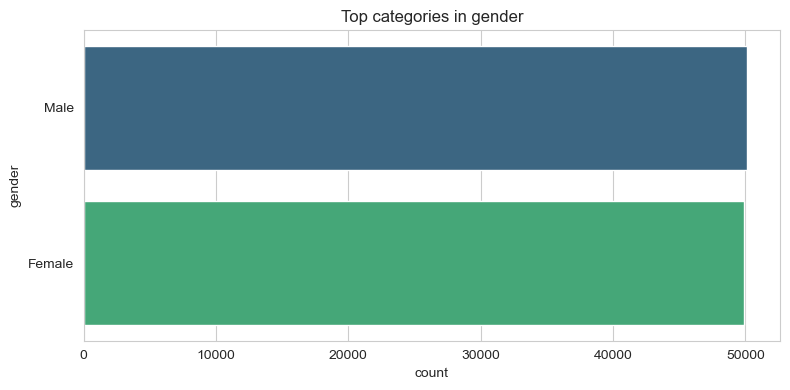


city
city
Hyderabad    10150
Ahmedabad    10057
Bangalore    10047
Mumbai       10015
Chennai       9993
Noida         9964
Delhi         9962
Kolkata       9955
Pune          9937
Jaipur        9920
Name: count, dtype: int64


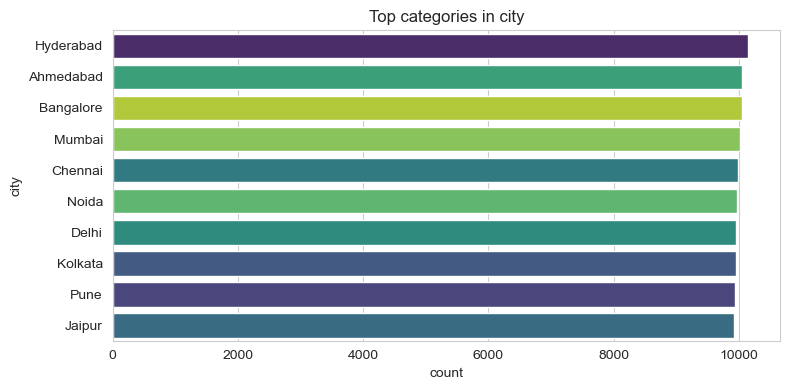


state
state
Maharashtra      19952
Telangana        10150
Gujarat          10057
Karnataka        10047
Tamil Nadu        9993
Uttar Pradesh     9964
Delhi             9962
West Bengal       9955
Rajasthan         9920
Name: count, dtype: int64


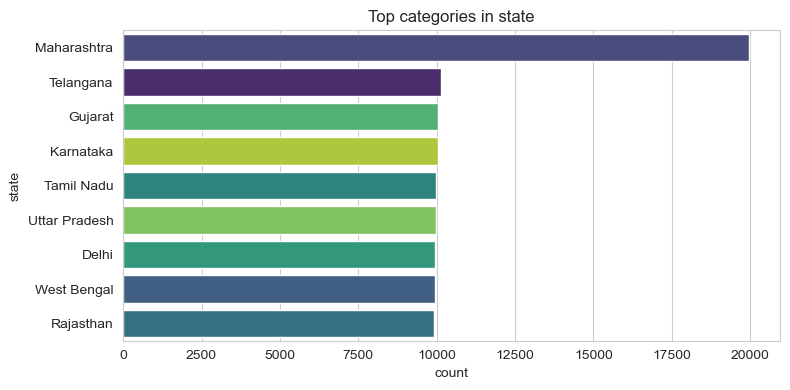


customer_segment
customer_segment
New        33488
Regular    33361
Premium    33151
Name: count, dtype: int64


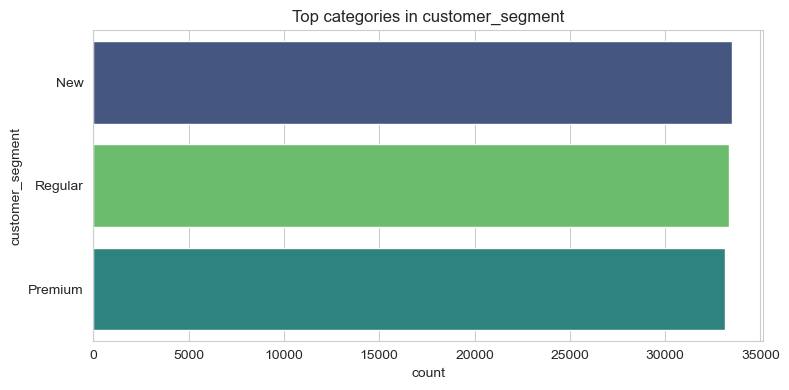


product_category
product_category
Health            16858
Home & Kitchen    16848
Fashion           16613
Grocery           16592
Electronics       16576
Beauty            16513
Name: count, dtype: int64


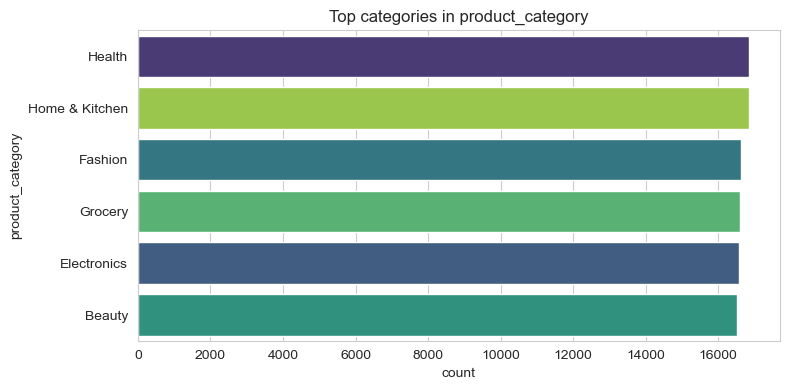


product_subcategory
product_subcategory
Protein Powder    5668
Supplements       5657
Shampoo           5578
Organic Rice      5567
Snacks            5548
Vitamins          5533
Face Cream        5512
Pulses            5477
Perfume           5423
Jeans             4278
Name: count, dtype: int64


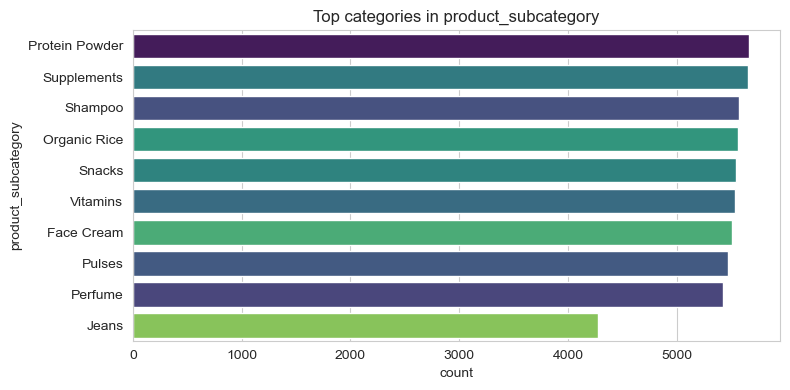


payment_method
payment_method
Credit Card         25307
UPI                 25139
Cash on Delivery    24994
Debit Card          24560
Name: count, dtype: int64


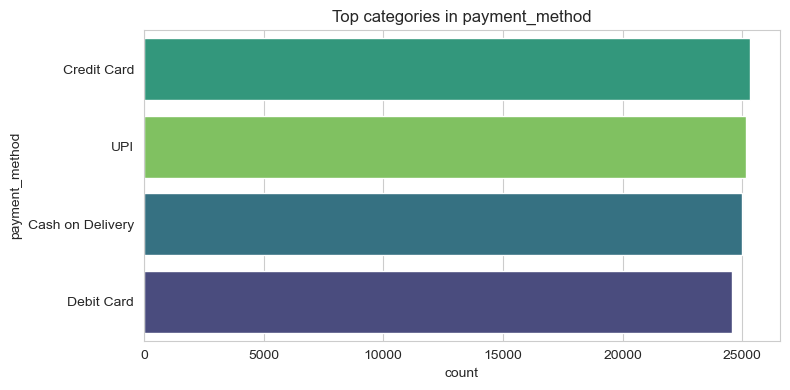


shipping_type
shipping_type
Express     50008
Standard    49992
Name: count, dtype: int64


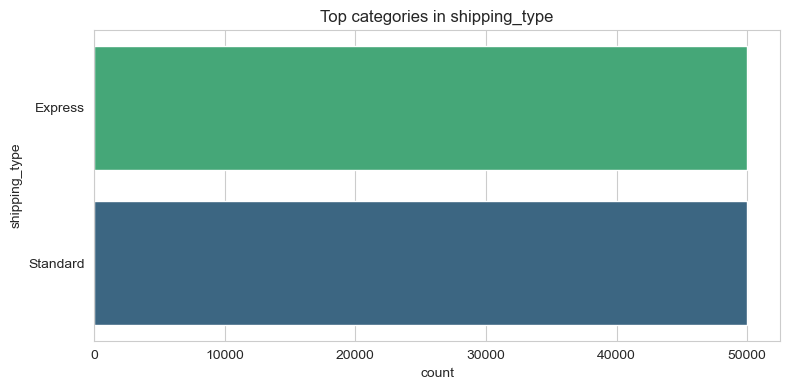


return_status
return_status
No     85189
Yes    14811
Name: count, dtype: int64


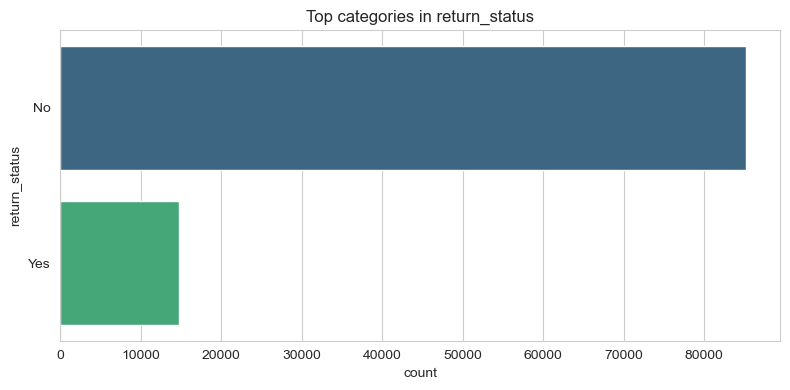

In [13]:

def univariate_categorical(df, cols, top_n=10):
    for col in cols:
        print(f"\n{'='*55}\n{col}\n{'='*55}")
        print(df[col].value_counts().head(top_n))
 
        plt.figure(figsize=(8, 4))
        order = df[col].value_counts().head(top_n).index
        sns.countplot(y=df[col], order=order, hue=df[col], palette='viridis', legend=False)
        plt.title(f'Top categories in {col}')
        plt.tight_layout()
        plt.show()
 
 
univariate_categorical(df, CATEGORICAL_COLS)

### Top Categories in Gender

#### This is a bar chart showing the gender distribution in a dataset:

#### Male: 50,111 records
#### Female: 49,889 records

#### The dataset is nearly perfectly balanced between genders, with males slightly outnumbering females by just 222 records (a difference of about 0.2%). This near 50/50 split suggests either a well-balanced sample or possibly synthetic/simulated data.

### Top Categories in cities

#### This is the same city distribution chart as before — it shows record counts across 10 Indian cities (Hyderabad, Ahmedabad, Bangalore, Mumbai, Chennai, Noida, Delhi, Kolkata, Pune, Jaipur), each with roughly 9,900–10,150 entries. The distribution is nearly uniform across all cities, suggesting the dataset was intentionally balanced (e.g., synthetic data) rather than reflecting real-world population-based skew.

### Top Categories in State

#### This chart shows record counts by state, and it breaks the uniform pattern seen earlier:

#### Maharashtra stands out with ~20,000 records — roughly double every other state.
#### All other states (Telangana, Gujarat, Karnataka, Tamil Nadu, Uttar Pradesh, Delhi, West Bengal, Rajasthan) are clustered tightly around ~9,900–10,100 each.

#### This makes sense given the city data: Maharashtra contains two cities from the earlier list (Mumbai and Pune), each contributing ~10,000 records, while every other state maps to just one city (e.g., Telangana → Hyderabad, Gujarat → Ahmedabad). So Maharashtra's count is essentially the sum of two "city-sized" buckets, confirming the dataset was built with ~10,000 records per city rather than per state.

### Top Categories in Customer segment

#### This chart shows customer distribution across three segments: New, Regular, and Premium, each with roughly 33,000 records — an almost perfectly even three-way split (consistent with the ~100,000 total dataset size). This continues the pattern seen in gender and city: the dataset appears deliberately balanced across categories rather than reflecting a natural, skewed real-world distribution.

### Top Categories in product category

#### This chart shows the distribution of records across 6 product categories: Health, Home & Kitchen, Fashion, Grocery, Electronics, and Beauty, each with roughly 16,500–16,800 records — again a near-even split (~1/6th of the ~100,000 total each). This reinforces the pattern from the other charts: the dataset was likely synthetically generated with balanced representation across all its categorical fields.

### Top Categories in product sub category

#### This chart shows the top 10 product subcategories, most clustered around 5,400–5,700 records each (Protein Powder, Supplements, Shampoo, Organic Rice, Snacks, Vitamins, Face Cream, Pulses, Perfume), with Jeans noticeably lower at around 4,300.

#### This is the first chart in the series showing a real dip rather than uniform balance — likely because this is showing only the "top 10" subcategories out of a larger set (as the title suggests), and/or Jeans being the sole representative of Fashion here while other categories may have multiple subcategories sharing their ~16,500 category total more evenly.

### Top Categories in payment methord

#### This chart shows record counts across 4 payment methods: Credit Card, UPI, Cash on Delivery, and Debit Card, each with roughly 24,500–25,300 records — again a near-even quarter split of the ~100,000 total dataset, continuing the pattern of balanced categorical distribution seen throughout this dataset.

### Top Categories in shipping type

#### This chart shows an exact 50/50 split between Express and Standard shipping types, each with 50,000 records — a perfect even distribution, continuing the balanced-categories pattern seen across the entire dataset.

### Top Categories in return status

#### This chart breaks the balanced pattern seen so far. It shows return_status:

##### No (not returned): 85,000 records (85%)
##### Yes (returned): 15,000 records (15%)

#### Unlike the other fields (gender, city, segment, payment method, shipping type), which were all artificially balanced, this one has a realistic skew — most orders are not returned, with only about 1 in 7 resulting in a return. This looks like a deliberately modeled real-world outcome rate rather than a synthetic balancing category, which makes sense since return rate is likely the target/dependent variable in this dataset.

## 3. OUTLIER DETECTION

In [14]:

def detect_outliers_iqr(df, col):
    """IQR method: flags points beyond 1.5*IQR from Q1/Q3.
    Good for skewed data (most retail price/quantity columns)."""
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (df[col] < lower) | (df[col] > upper)
    return mask, lower, upper
 
outlier_summary = {}
for col in NUMERIC_COLS:
    mask_iqr, lower, upper = detect_outliers_iqr(df, col)
    
 
    outlier_summary[col] = {
        'IQR_outliers': mask_iqr.sum(),
        'IQR_lower_bound': round(lower, 2),
        'IQR_upper_bound': round(upper, 2),
        
    }

In [15]:
outlier_df = pd.DataFrame(outlier_summary).T
print("\nOutlier Summary:\n", outlier_df)


Outlier Summary:
                      IQR_outliers  IQR_lower_bound  IQR_upper_bound
age                           0.0             -6.0            90.00
product_price                 0.0         -28998.0         89330.00
quantity                      0.0             -3.5             8.50
discount_percentage           0.0            -17.0            47.00
final_price                1335.0         -79306.6        198057.68
delivery_days                 0.0             -4.5            15.50


### Key takeaway for outlier summary:

#### Almost every column has 0 outliers — all values fall comfortably within their expected IQR range.final_price is the only column with outliers — 1,335 records fall outside the range (-79,306.6 to 198,057.68), meaning some final prices are unusually high (or low) compared to the typical spread.

#### The wide bound range for final_price also suggests it has high variance/spread compared to other columns, likely because it's a derived field (product_price × quantity × discount adjustments) that can compound into extreme values.

## 4. OUTLIER CORRECTION

In [77]:

# Choose ONE strategy per column depending on context - see explanation below.
 
def cap_outliers_iqr(df, col):
    """Winsorizing / capping: pull extreme values in to the IQR boundary
    instead of deleting rows. Keeps all data, removes distortion."""
    data = df[col]
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = data.clip(lower=lower, upper=upper)
    return df
 
 
def remove_outliers_iqr(df, col):
    """Drop rows outside IQR bounds. Use only when outliers are
    confirmed data-entry errors, not genuine rare events."""
    mask, lower, upper = detect_outliers_iqr(df, col)
    return df[~mask]
 
 
def log_transform(df, col):
    """Log transform compresses large values, reducing the influence
    of outliers without removing them. Only for positive, right-skewed data."""
    df[col + '_log'] = np.log1p(df[col])   # log1p handles zeros safely
    return df
 
 
def impute_outliers_with_median(df, col):
    """Replace outlier values with the column median instead of the
    extreme value. Preserves row count, avoids distortion from extremes."""
    mask, lower, upper = detect_outliers_iqr(df, col)
    median_val = df[col].median()
    df.loc[mask, col] = median_val
    return df

In [18]:
# ---- Example application ----
df_clean = df.copy()

In [19]:
# ---- Example application ----
df_clean = df.copy()
 
# age: cap unrealistic values (e.g. negative age, age > 100)
df_clean = cap_outliers_iqr(df_clean, 'age')
 
# product_price / final_price: cap rather than delete (genuine premium products)
df_clean = cap_outliers_iqr(df_clean, 'product_price')
df_clean = cap_outliers_iqr(df_clean, 'final_price')
 
# quantity: cap bulk orders instead of deleting the transaction
df_clean = cap_outliers_iqr(df_clean, 'quantity')
 
# discount_percentage: should logically be 0-100, clip to valid range first
df_clean['discount_percentage'] = df_clean['discount_percentage'].clip(0, 100)
df_clean = cap_outliers_iqr(df_clean, 'discount_percentage')
 
# delivery_days: cap unusually long delivery times
df_clean = cap_outliers_iqr(df_clean, 'delivery_days')
 
print("\nBefore vs After capping (describe):")
for col in NUMERIC_COLS:
    print(f"\n{col}")
    print(pd.concat([df[col].describe(), df_clean[col].describe()],
                     axis=1, keys=['before', 'after']))


Before vs After capping (describe):

age
              before          after
count  100000.000000  100000.000000
mean       41.561830      41.561830
std        13.852439      13.852439
min        18.000000      18.000000
25%        30.000000      30.000000
50%        42.000000      42.000000
75%        54.000000      54.000000
max        65.000000      65.000000

product_price
              before          after
count  100000.000000  100000.000000
mean    30164.526720   30164.526720
std     17139.679807   17139.679807
min       500.000000     500.000000
25%     15375.000000   15375.000000
50%     30148.000000   30148.000000
75%     44957.000000   44957.000000
max     59998.000000   59998.000000

quantity
              before          after
count  100000.000000  100000.000000
mean        2.501790       2.501790
std         1.120058       1.120058
min         1.000000       1.000000
25%         1.000000       1.000000
50%         3.000000       3.000000
75%         4.000000       4.0000

#### Key finding: Only final_price changed — every other column (age, product_price, quantity, discount_percentage, delivery_days) is identical before and after, confirming they had no outliers to cap (matching the previous IQR summary).

#### Capping successfully tamed the extreme high final_price values without disturbing the rest of the data.

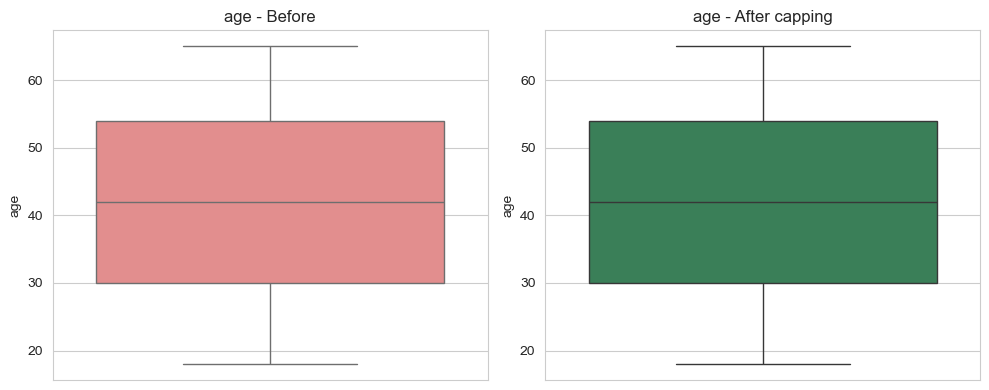

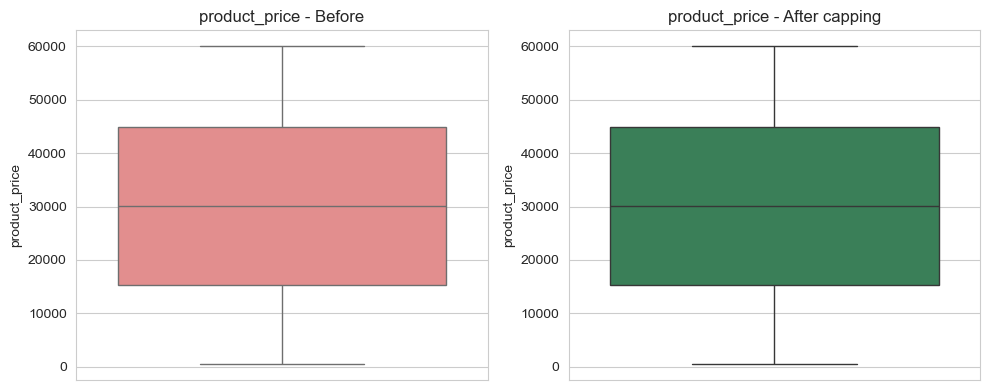

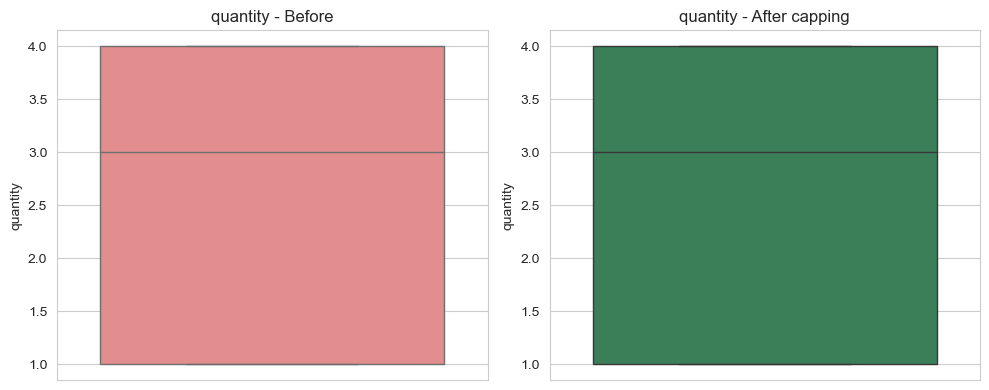

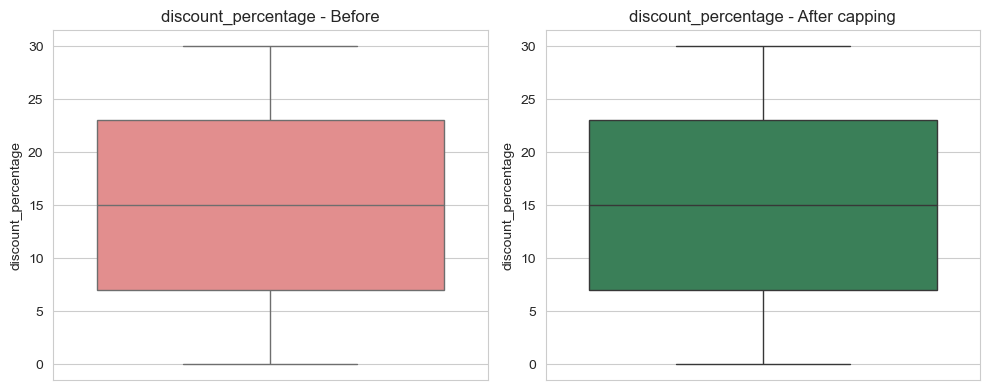

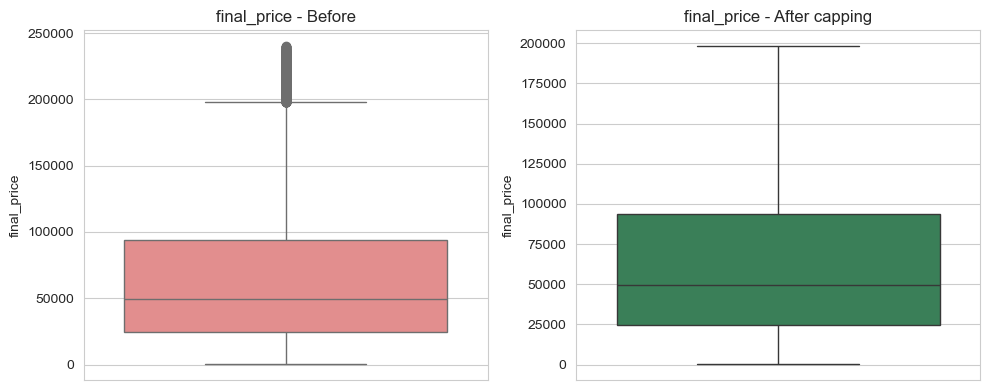

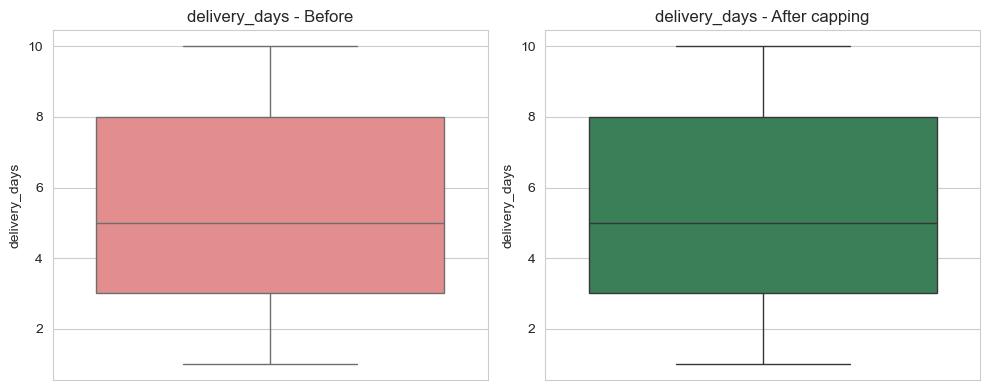

In [23]:
# 5. VISUAL COMPARISON - BEFORE vs AFTER
# ============================================================
def compare_before_after(df_before, df_after, col):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.boxplot(y=df_before[col], ax=axes[0], color='lightcoral')
    axes[0].set_title(f'{col} - Before')
 
    sns.boxplot(y=df_after[col], ax=axes[1], color='seagreen')
    axes[1].set_title(f'{col} - After capping')
 
    plt.tight_layout()
    plt.show()
 
 
for col in NUMERIC_COLS:
    compare_before_after(df, df_clean, col)
 

# BIVERIAT ANALYSIS

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy import stats
 
sns.set_style('whitegrid')
 

 

In [1]:
FILE_PATH = r'D:\Awantika\Data Science Class notes\Basics_Python\Basics_Python\retail_large_dataset.csv'

In [3]:
NUMERIC_COLS = ['age', 'product_price', 'quantity',
                'discount_percentage', 'final_price', 'delivery_days']

In [4]:
NUMERIC_COLS

['age',
 'product_price',
 'quantity',
 'discount_percentage',
 'final_price',
 'delivery_days']

In [6]:
CATEGORICAL_COLS = ['gender', 'city', 'state', 'customer_segment',
                     'product_category', 'product_subcategory',
                     'payment_method', 'shipping_type', 'return_status']

In [7]:
CATEGORICAL_COLS

['gender',
 'city',
 'state',
 'customer_segment',
 'product_category',
 'product_subcategory',
 'payment_method',
 'shipping_type',
 'return_status']

In [8]:
NUMERIC_COLS

['age',
 'product_price',
 'quantity',
 'discount_percentage',
 'final_price',
 'delivery_days']

In [39]:
CATEGORICAL_COLS

['gender',
 'city',
 'state',
 'customer_segment',
 'product_category',
 'product_subcategory',
 'payment_method',
 'shipping_type',
 'return_status']

In [14]:
df = pd.read_csv(FILE_PATH)
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
print("Shape:", df.shape)

Shape: (100000, 18)


In [26]:
df

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,C109995,29,Female,Pune,Maharashtra,Regular,O149995,2024-06-11,Health,Supplements,49293,1,11,43870.77,Debit Card,Standard,9,No
99996,C109996,28,Male,Mumbai,Maharashtra,Premium,O149996,2024-04-27,Fashion,Men T-Shirt,5722,2,22,8926.32,Cash on Delivery,Express,1,No
99997,C109997,44,Female,Jaipur,Rajasthan,Premium,O149997,2024-04-14,Grocery,Snacks,6311,4,11,22467.16,Cash on Delivery,Express,9,No
99998,C109998,45,Male,Jaipur,Rajasthan,Premium,O149998,2024-09-08,Beauty,Shampoo,46888,1,28,33759.36,Debit Card,Standard,1,No


### 1. NUMERIC vs NUMERIC

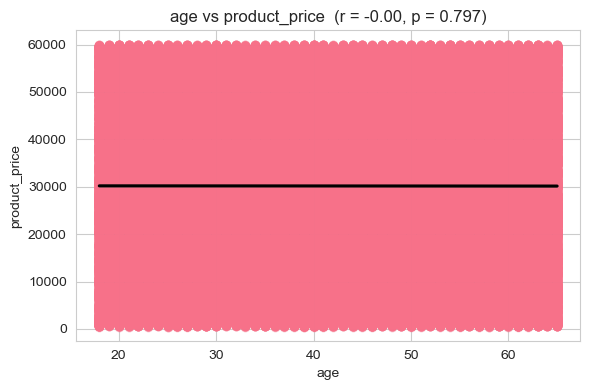

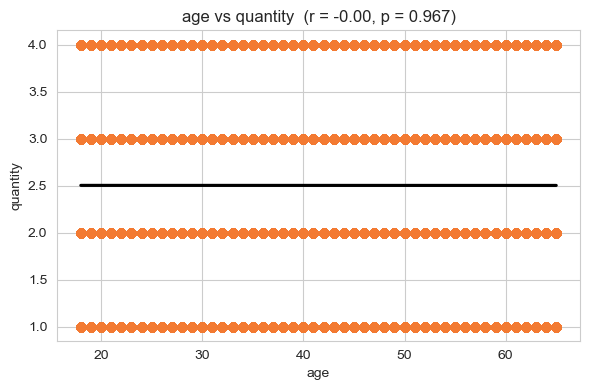

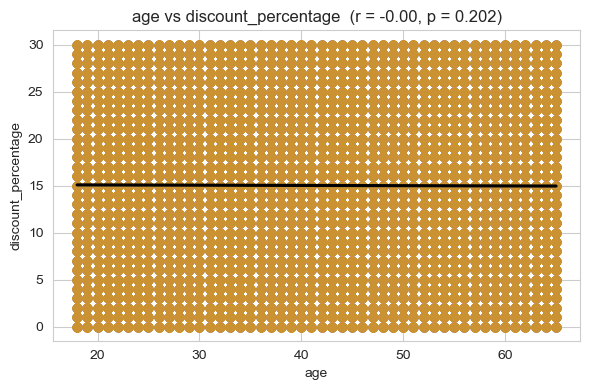

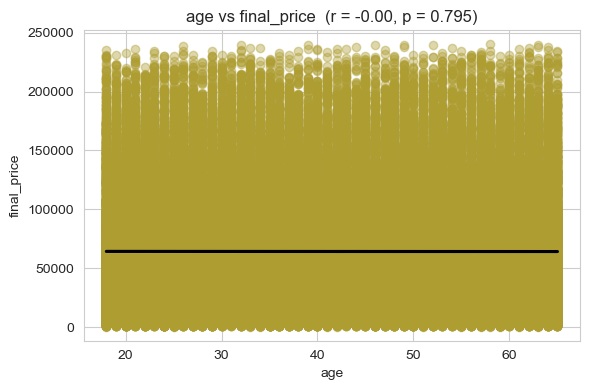

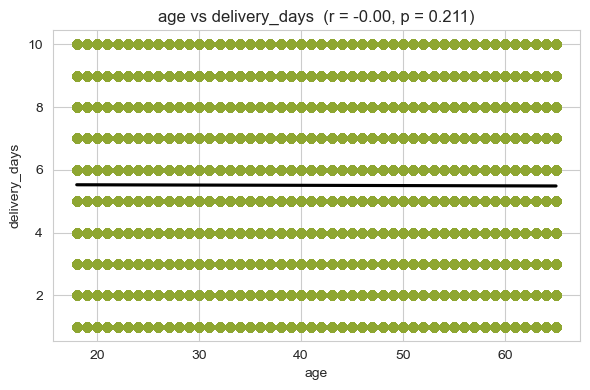

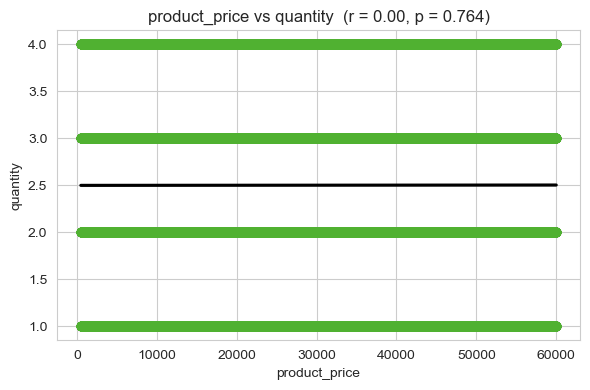

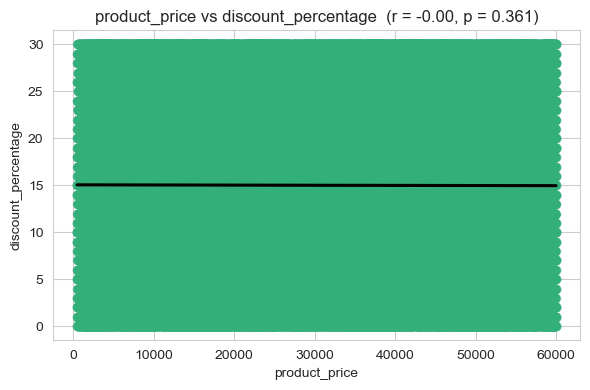

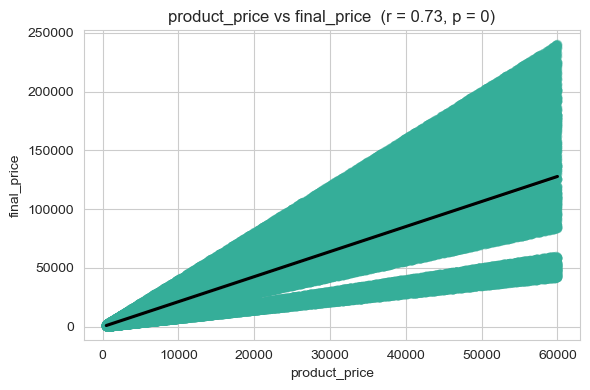

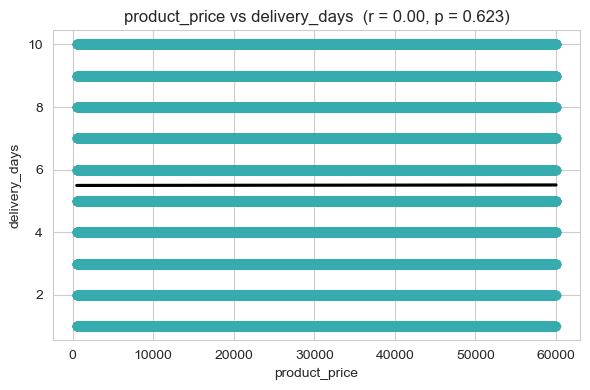

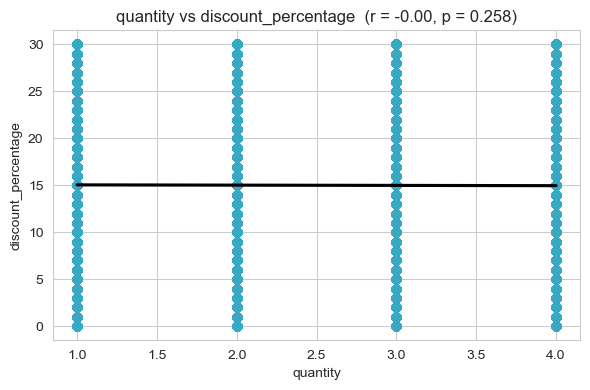

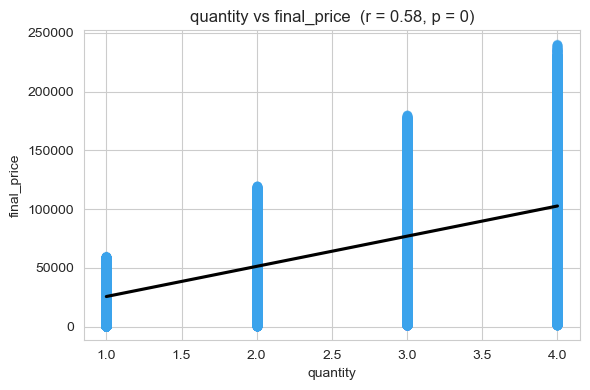

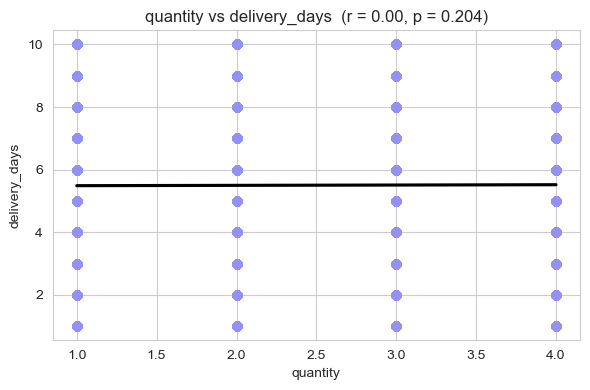

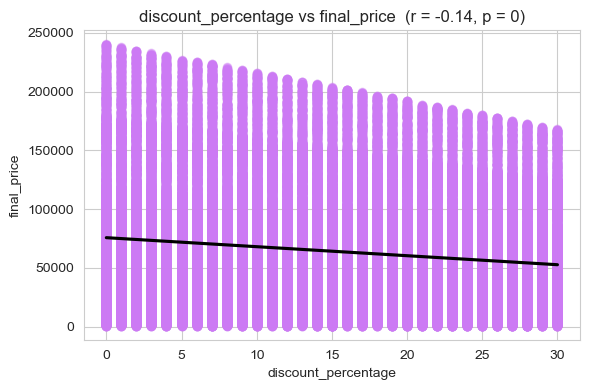

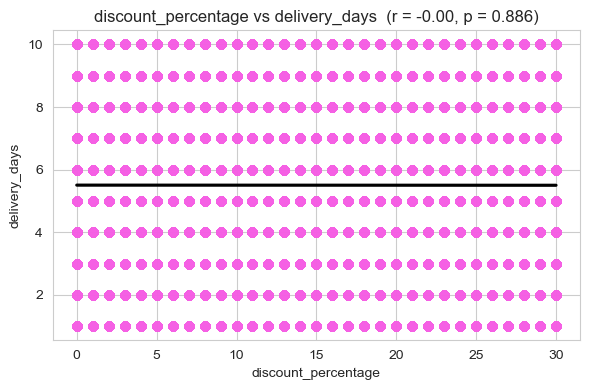

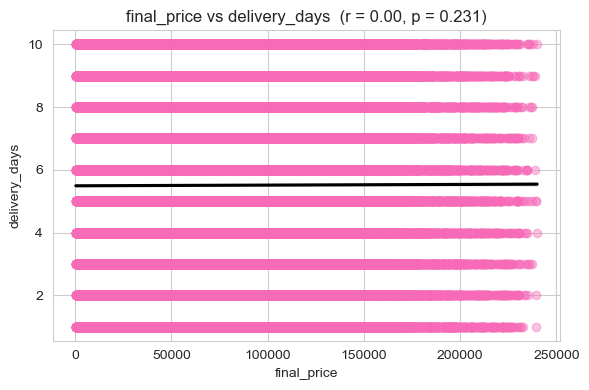


Correlation summary (sorted by strength):
                    col1                 col2  correlation  p_value
7         product_price          final_price        0.731   0.0000
10             quantity          final_price        0.575   0.0000
12  discount_percentage          final_price       -0.137   0.0000
2                   age  discount_percentage       -0.004   0.2020
4                   age        delivery_days       -0.004   0.2111
9              quantity  discount_percentage       -0.004   0.2577
11             quantity        delivery_days        0.004   0.2040
14          final_price        delivery_days        0.004   0.2308
6         product_price  discount_percentage       -0.003   0.3614
8         product_price        delivery_days        0.002   0.6230
0                   age        product_price       -0.001   0.7968
3                   age          final_price       -0.001   0.7946
5         product_price             quantity        0.001   0.7639
1                 

In [25]:
def bivariate_numeric_numeric(df, cols):
    """Scatter plot + regression line + Pearson correlation for every pair."""
    results = []
    pairs = list(combinations(cols, 2))
    colors = sns.color_palette("husl", len(pairs))  # colorful, distinct palette

    for i, (col1, col2) in enumerate(pairs):
        sub = df[[col1, col2]].dropna()
        corr, p_val = stats.pearsonr(sub[col1], sub[col2])
        results.append({'col1': col1, 'col2': col2, 'correlation': round(corr, 3), 'p_value': round(p_val, 4)})

        plt.figure(figsize=(6, 4))
        sns.regplot(
            x=sub[col1], y=sub[col2],
            scatter_kws={'alpha': 0.4, 'color': colors[i]},
            line_kws={'color': 'black'}
        )
        plt.title(f'{col1} vs {col2}  (r = {corr:.2f}, p = {p_val:.3g})')
        plt.tight_layout()
        plt.show()

    result_df = pd.DataFrame(results).sort_values('correlation', key=abs, ascending=False)
    print("\nCorrelation summary (sorted by strength):\n", result_df)
    return result_df


corr_results = bivariate_numeric_numeric(df, NUMERIC_COLS)

#### Takeaway: final_price is the only variable meaningfully influenced by others in the dataset — driven by product_price (strongest), quantity, and slightly reduced by discount_percentage. age and delivery_days remain statistically unrelated to every other numeric column, confirming the dataset's design as mostly independent, randomly generated fields except for the price calculation.

### 2. NUMERIC vs CATEGORICAL

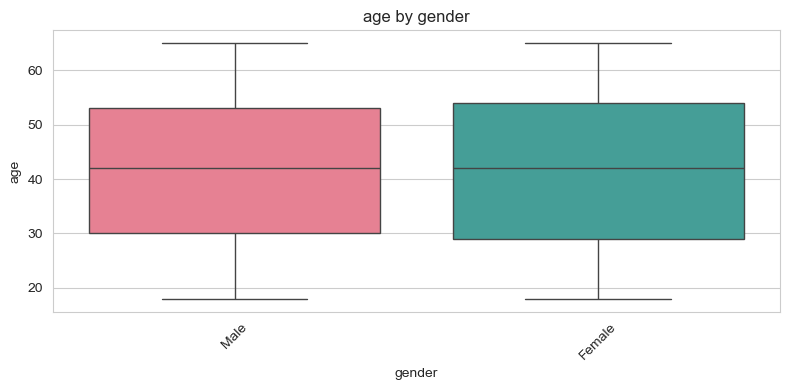

ANOVA age ~ gender: F=0.22, p=0.6411 -> not significant difference between groups


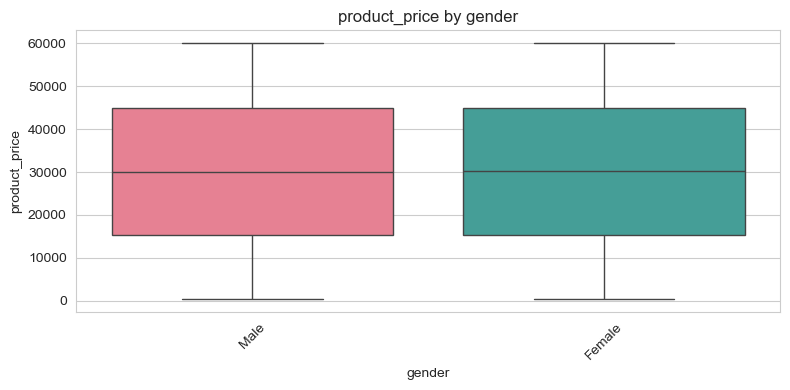

ANOVA product_price ~ gender: F=0.06, p=0.7997 -> not significant difference between groups


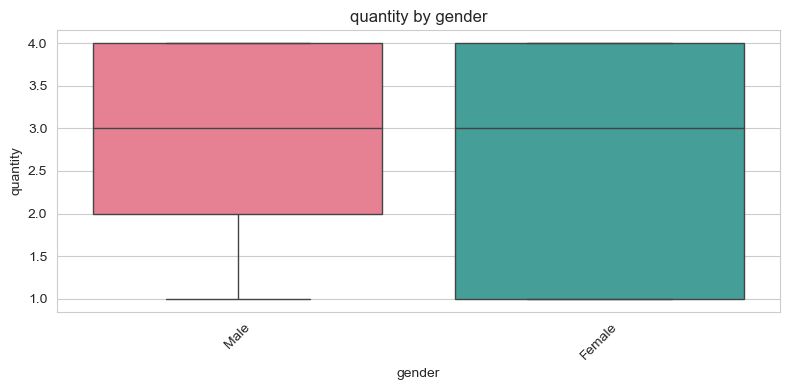

ANOVA quantity ~ gender: F=0.49, p=0.4845 -> not significant difference between groups


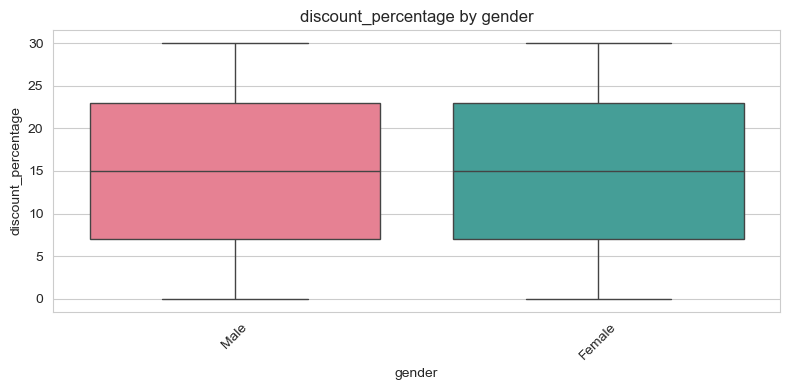

ANOVA discount_percentage ~ gender: F=0.63, p=0.4265 -> not significant difference between groups


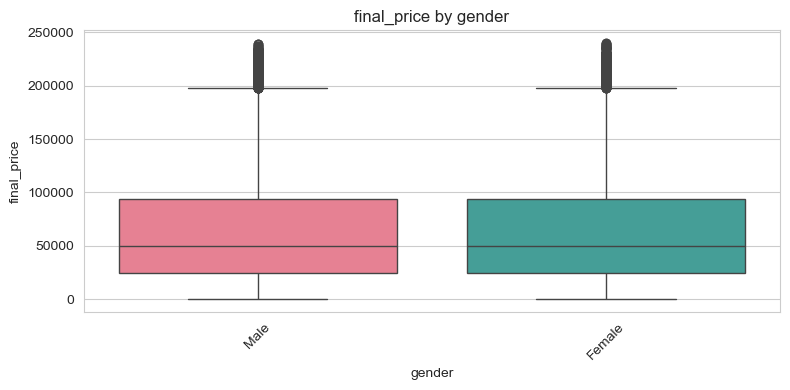

ANOVA final_price ~ gender: F=0.34, p=0.5625 -> not significant difference between groups


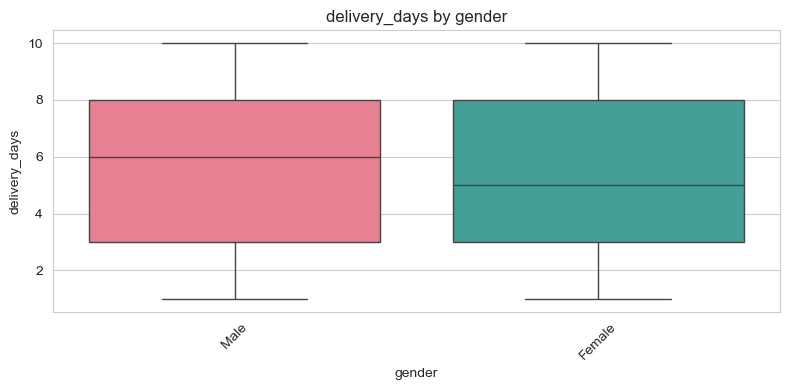

ANOVA delivery_days ~ gender: F=1.03, p=0.3103 -> not significant difference between groups


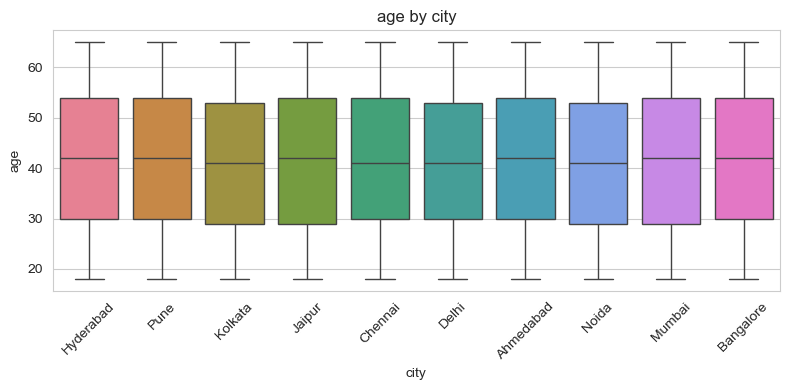

ANOVA age ~ city: F=1.98, p=0.03708 -> significant difference between groups


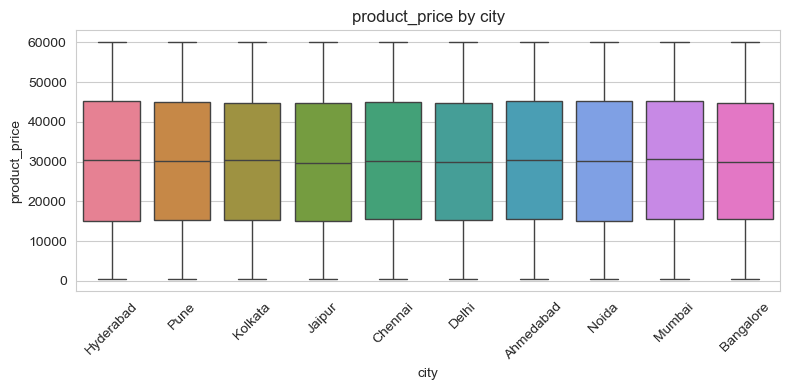

ANOVA product_price ~ city: F=0.77, p=0.6458 -> not significant difference between groups


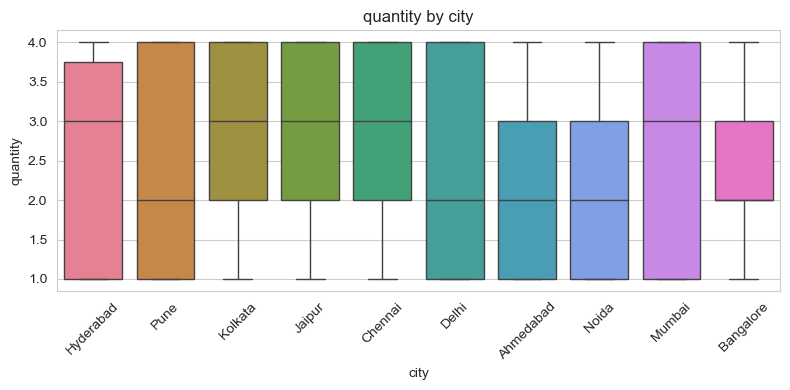

ANOVA quantity ~ city: F=0.85, p=0.5663 -> not significant difference between groups


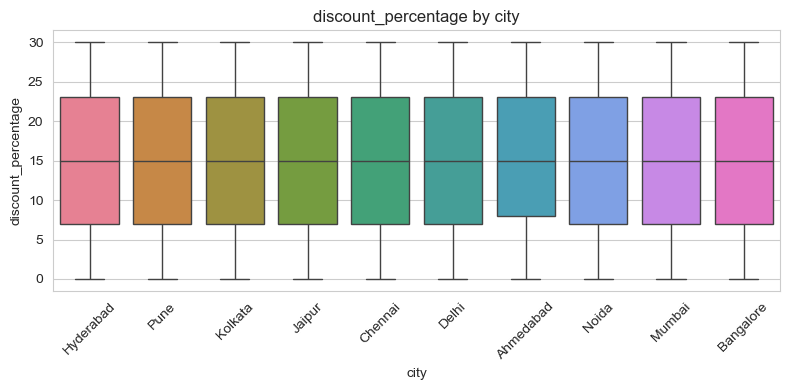

ANOVA discount_percentage ~ city: F=1.81, p=0.06066 -> not significant difference between groups


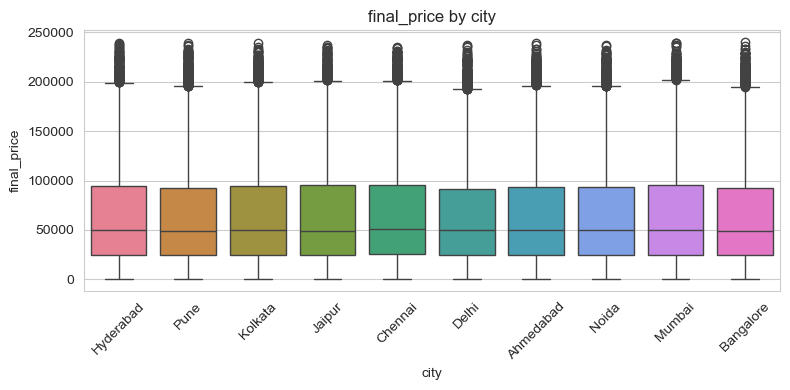

ANOVA final_price ~ city: F=1.07, p=0.382 -> not significant difference between groups


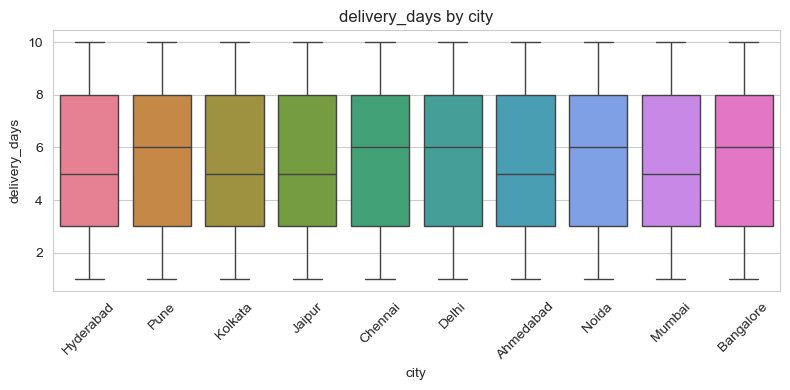

ANOVA delivery_days ~ city: F=1.24, p=0.2671 -> not significant difference between groups


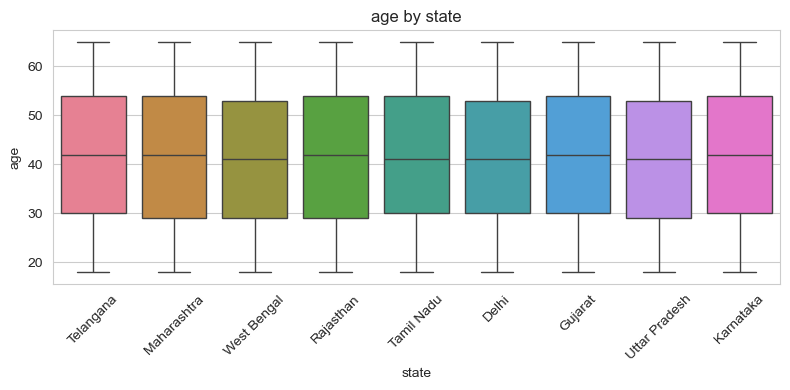

ANOVA age ~ state: F=2.23, p=0.02247 -> significant difference between groups


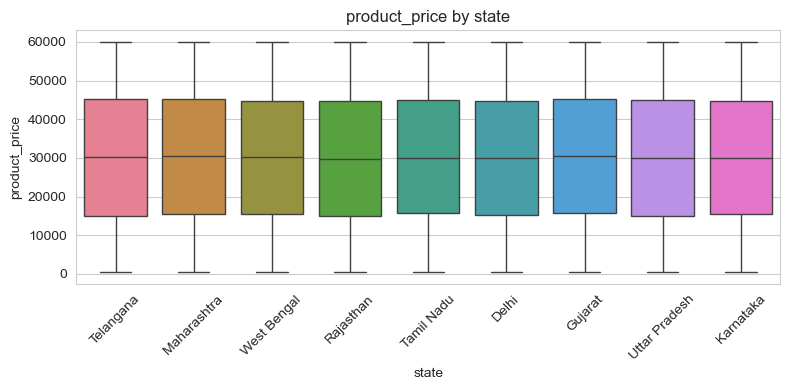

ANOVA product_price ~ state: F=0.79, p=0.6077 -> not significant difference between groups


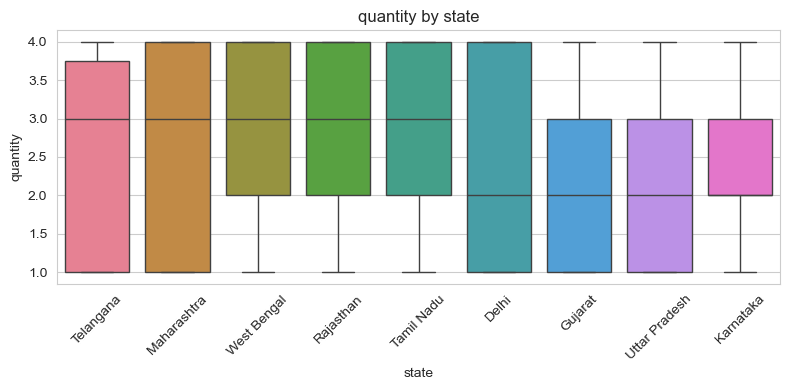

ANOVA quantity ~ state: F=0.85, p=0.556 -> not significant difference between groups


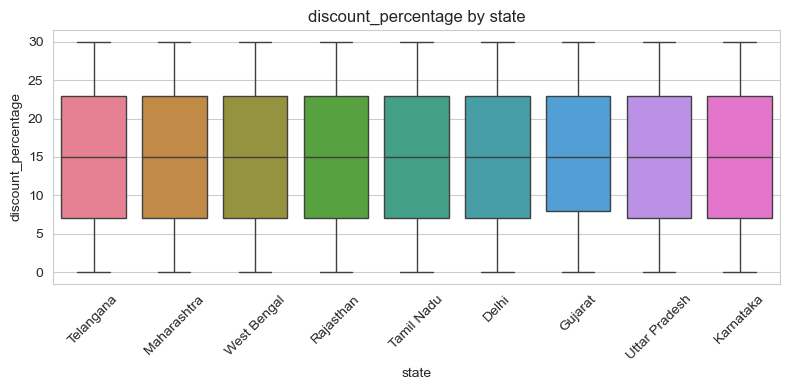

ANOVA discount_percentage ~ state: F=2.03, p=0.03874 -> significant difference between groups


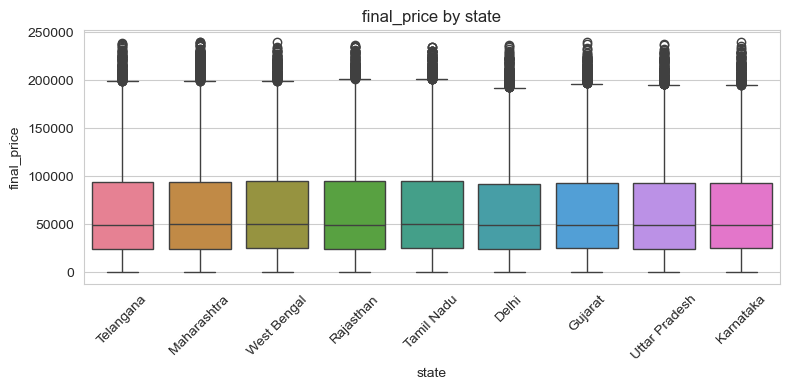

ANOVA final_price ~ state: F=0.97, p=0.4564 -> not significant difference between groups


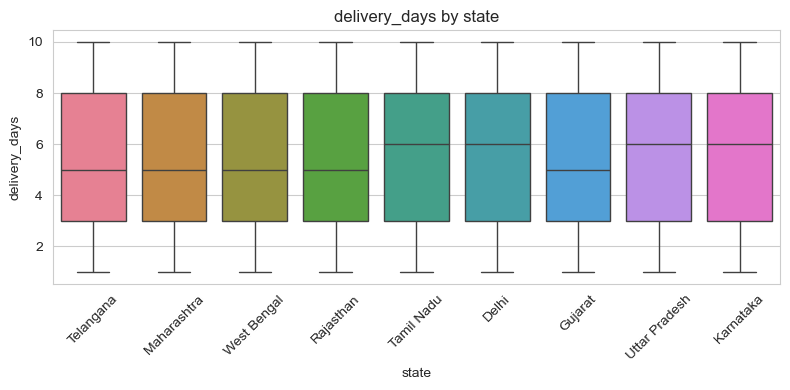

ANOVA delivery_days ~ state: F=1.01, p=0.4252 -> not significant difference between groups


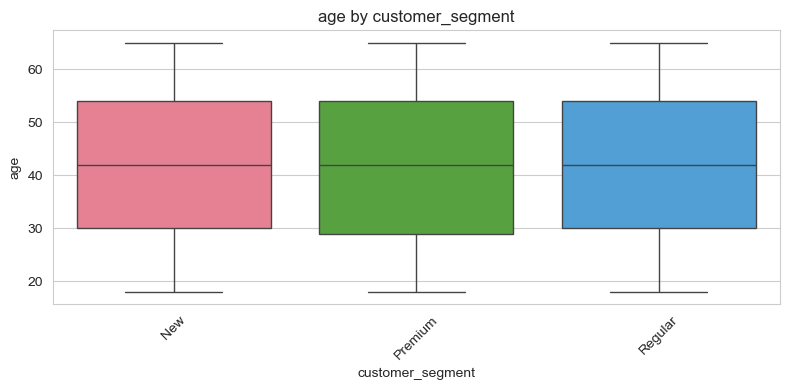

ANOVA age ~ customer_segment: F=0.20, p=0.822 -> not significant difference between groups


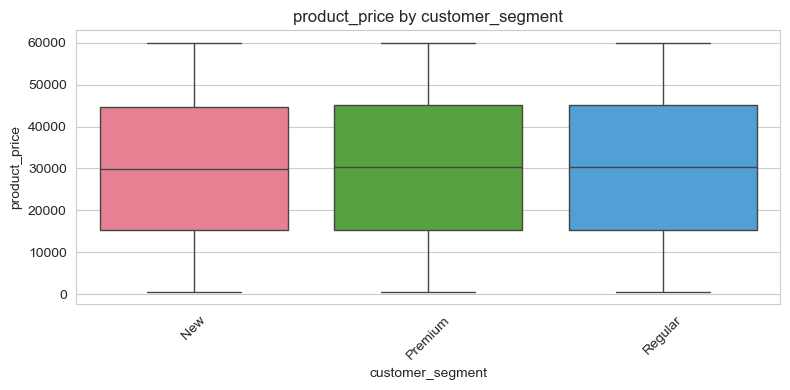

ANOVA product_price ~ customer_segment: F=2.50, p=0.08189 -> not significant difference between groups


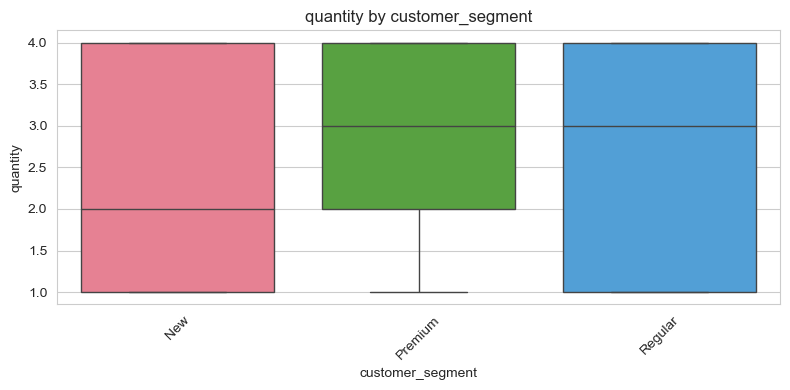

ANOVA quantity ~ customer_segment: F=1.03, p=0.3586 -> not significant difference between groups


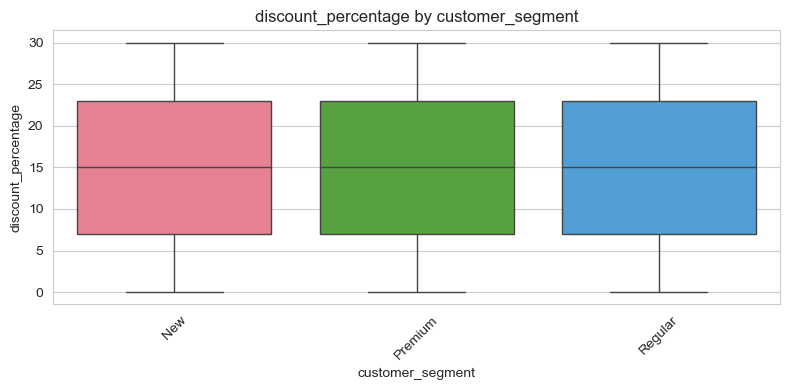

ANOVA discount_percentage ~ customer_segment: F=1.66, p=0.1906 -> not significant difference between groups


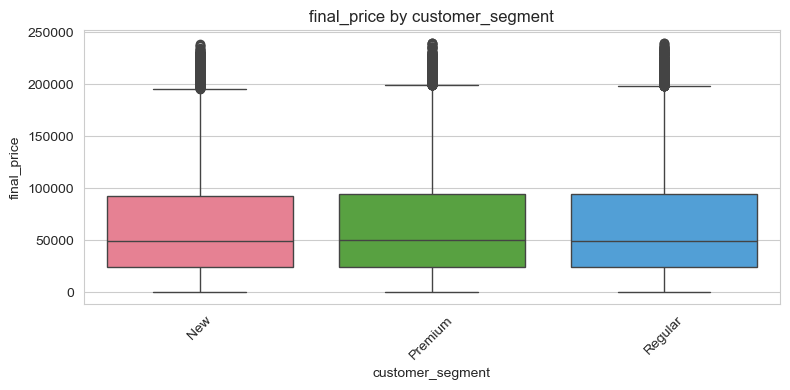

ANOVA final_price ~ customer_segment: F=1.66, p=0.1904 -> not significant difference between groups


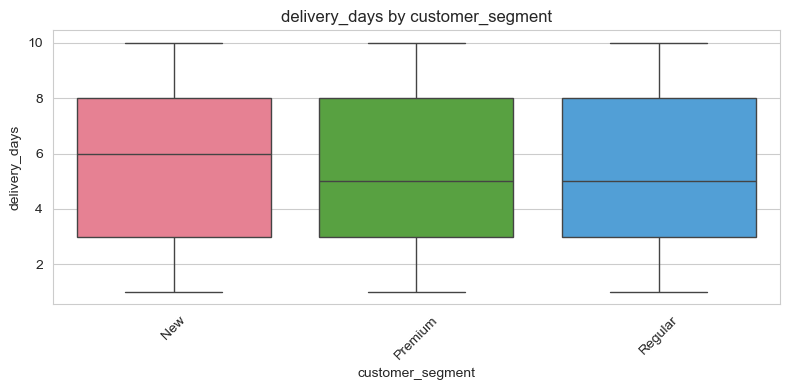

ANOVA delivery_days ~ customer_segment: F=0.87, p=0.4182 -> not significant difference between groups


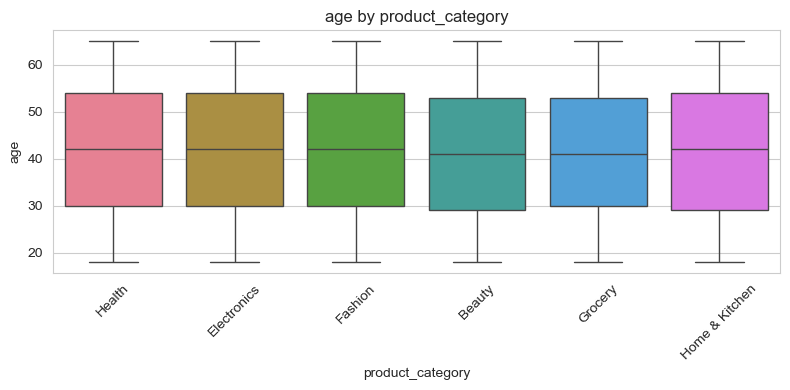

ANOVA age ~ product_category: F=0.98, p=0.4291 -> not significant difference between groups


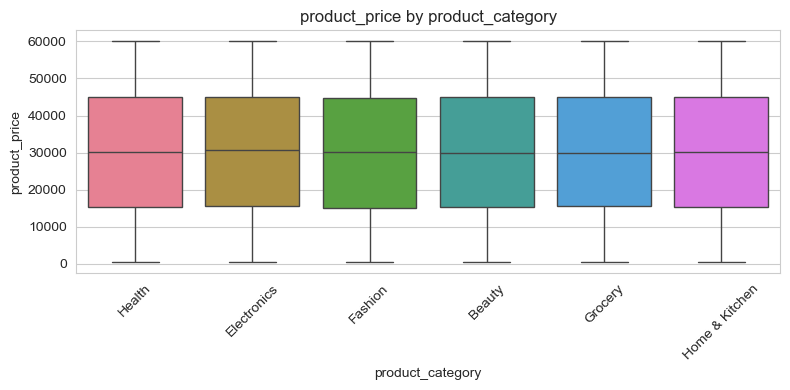

ANOVA product_price ~ product_category: F=1.75, p=0.1201 -> not significant difference between groups


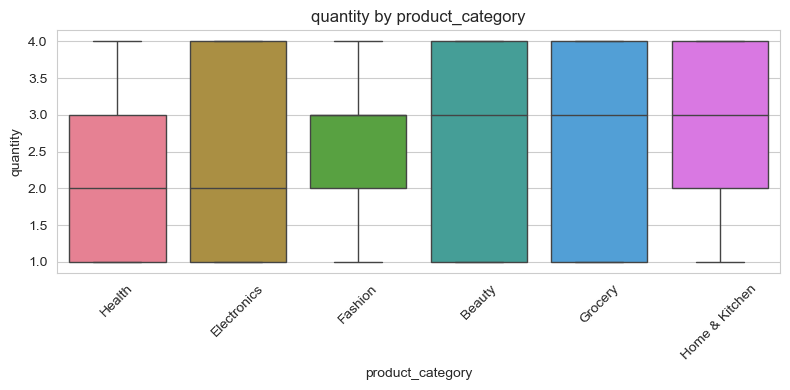

ANOVA quantity ~ product_category: F=0.57, p=0.7209 -> not significant difference between groups


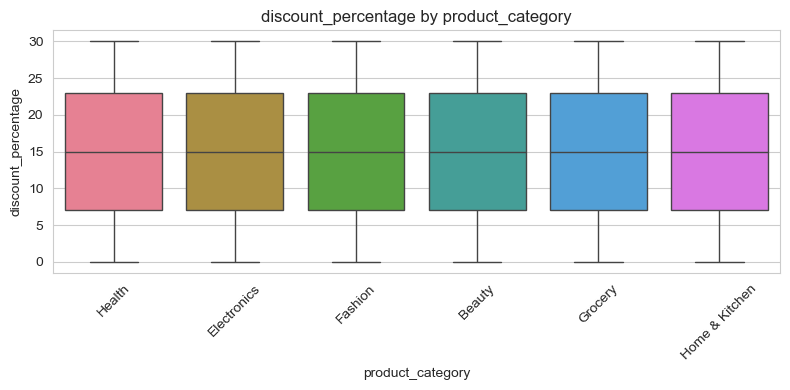

ANOVA discount_percentage ~ product_category: F=0.61, p=0.6937 -> not significant difference between groups


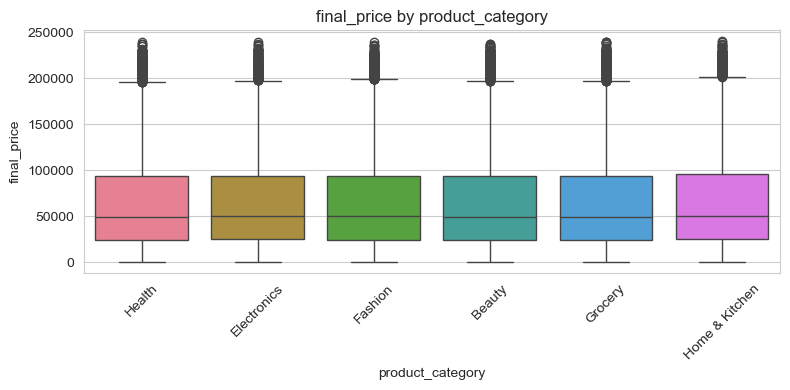

ANOVA final_price ~ product_category: F=1.03, p=0.4008 -> not significant difference between groups


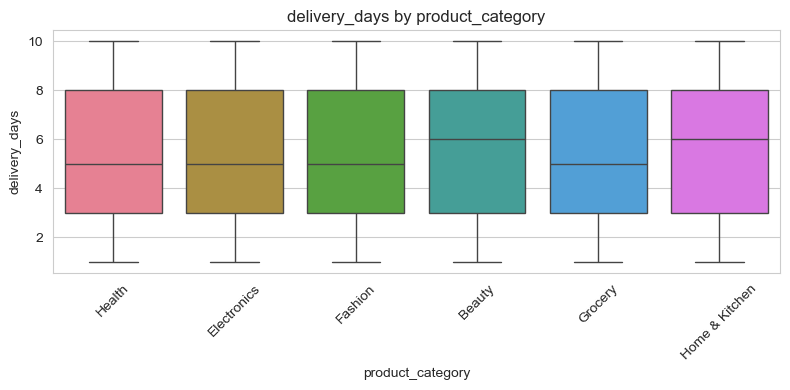

ANOVA delivery_days ~ product_category: F=0.47, p=0.8005 -> not significant difference between groups
Skipping product_subcategory - too many categories (21)


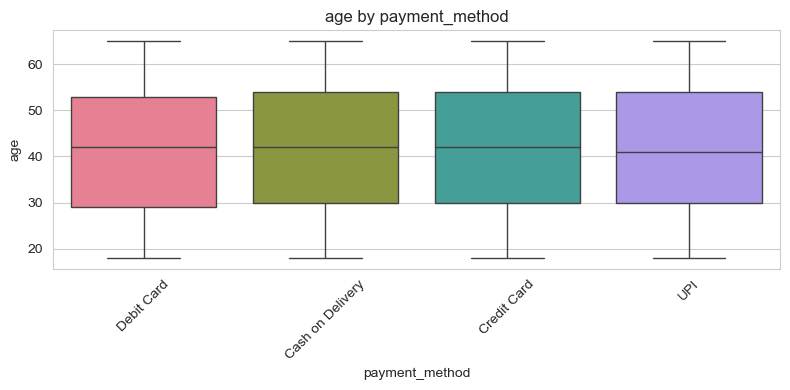

ANOVA age ~ payment_method: F=0.65, p=0.5829 -> not significant difference between groups


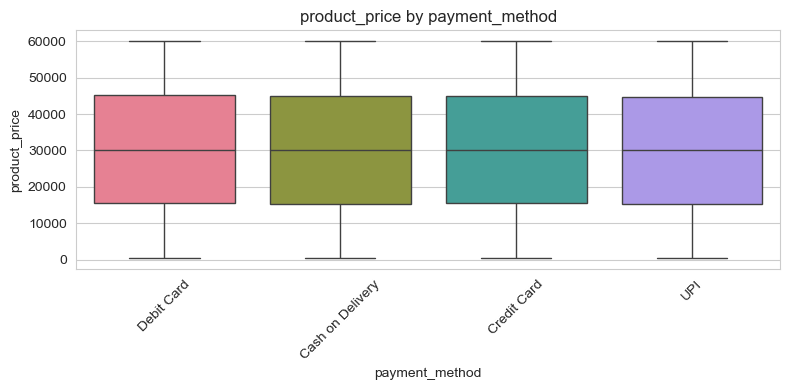

ANOVA product_price ~ payment_method: F=0.70, p=0.5493 -> not significant difference between groups


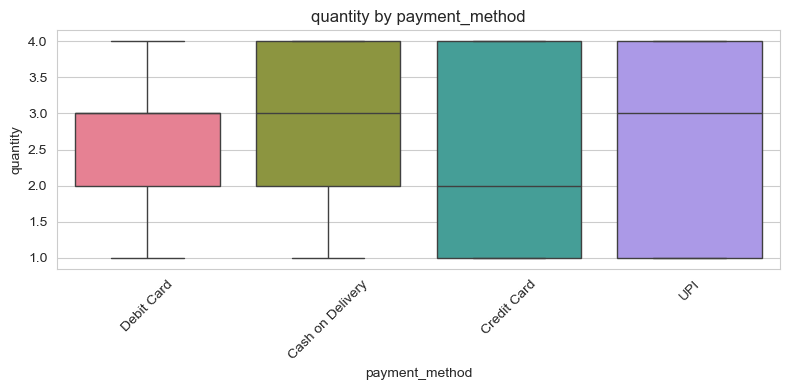

ANOVA quantity ~ payment_method: F=0.54, p=0.6516 -> not significant difference between groups


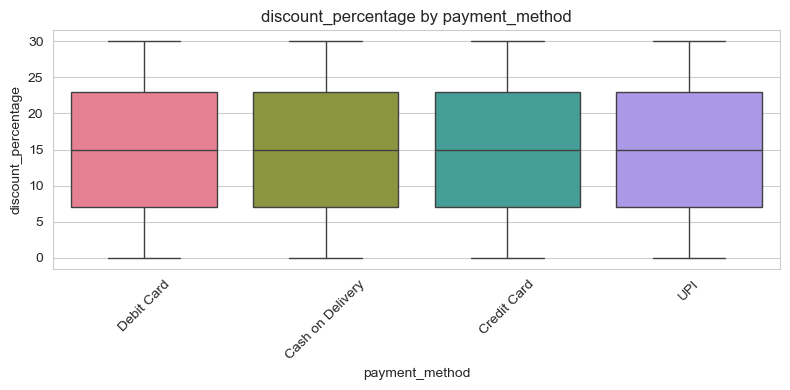

ANOVA discount_percentage ~ payment_method: F=2.50, p=0.05762 -> not significant difference between groups


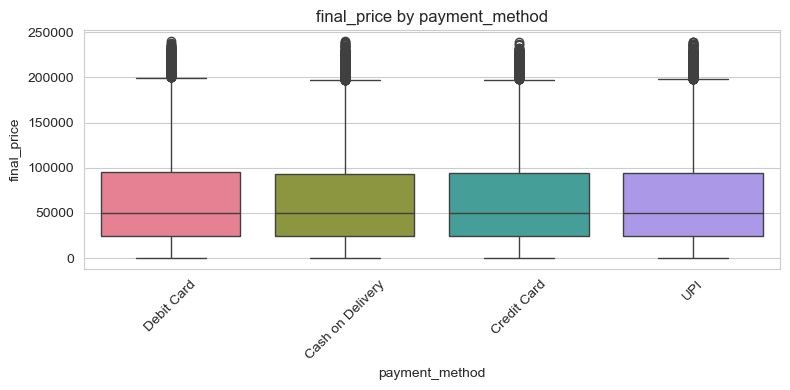

ANOVA final_price ~ payment_method: F=1.39, p=0.2445 -> not significant difference between groups


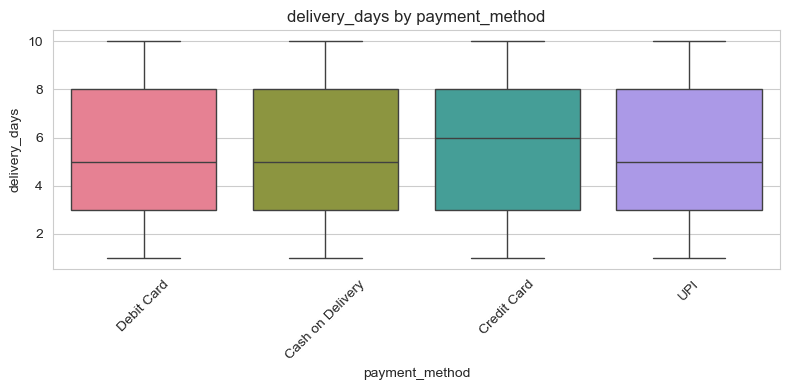

ANOVA delivery_days ~ payment_method: F=0.67, p=0.5684 -> not significant difference between groups


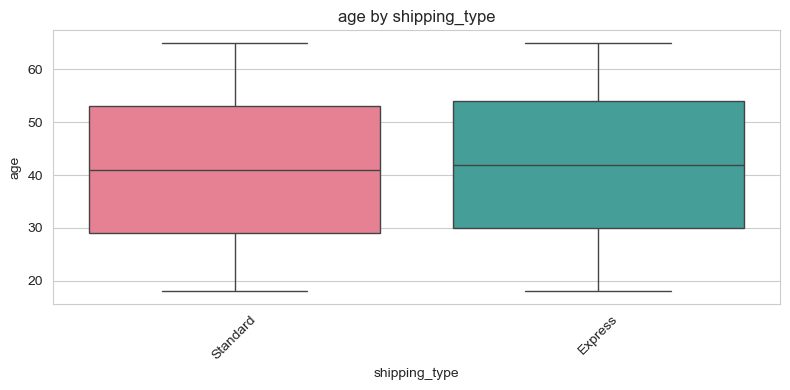

ANOVA age ~ shipping_type: F=4.67, p=0.03063 -> significant difference between groups


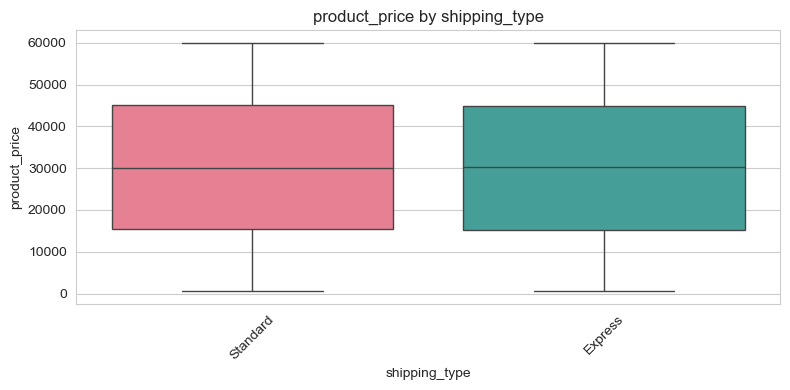

ANOVA product_price ~ shipping_type: F=0.02, p=0.8907 -> not significant difference between groups


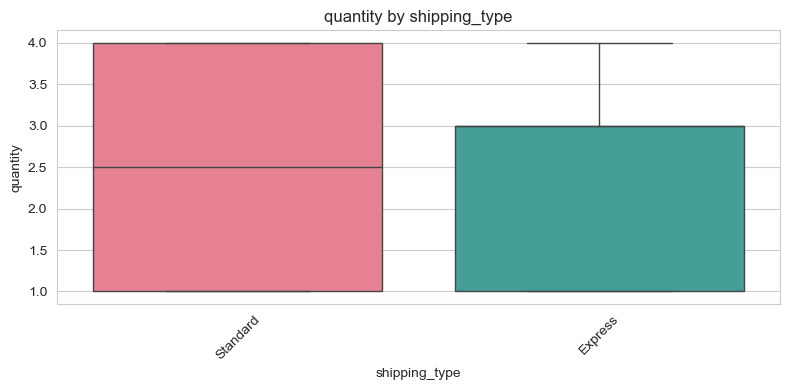

ANOVA quantity ~ shipping_type: F=0.10, p=0.7496 -> not significant difference between groups


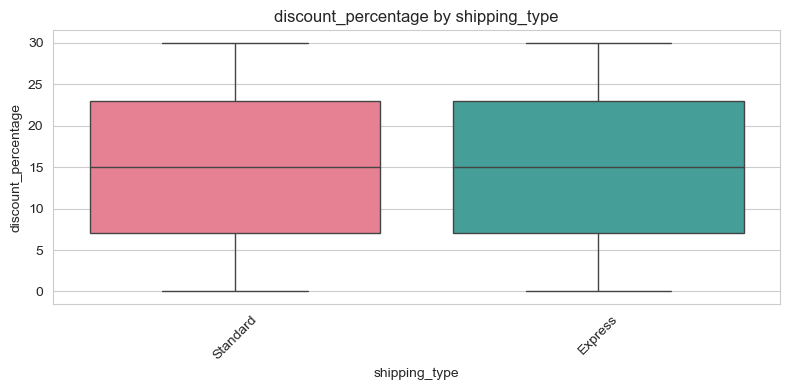

ANOVA discount_percentage ~ shipping_type: F=0.46, p=0.4997 -> not significant difference between groups


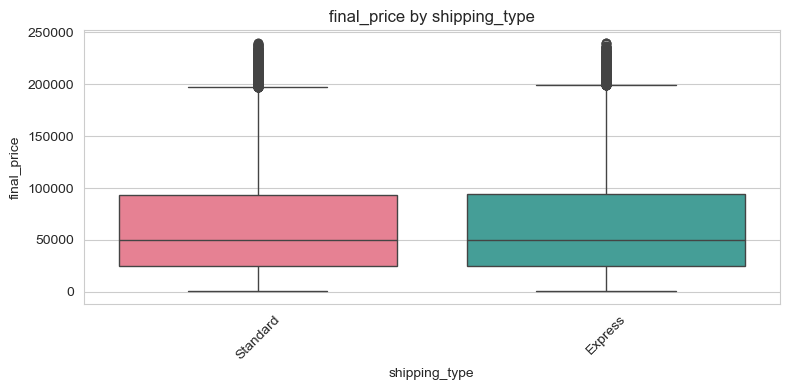

ANOVA final_price ~ shipping_type: F=0.03, p=0.871 -> not significant difference between groups


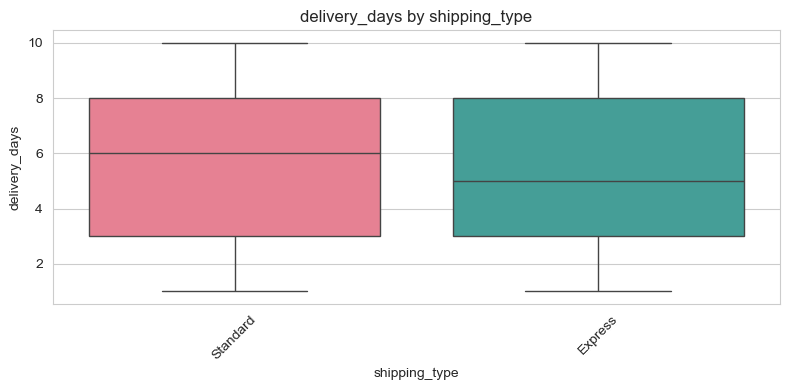

ANOVA delivery_days ~ shipping_type: F=0.80, p=0.3702 -> not significant difference between groups


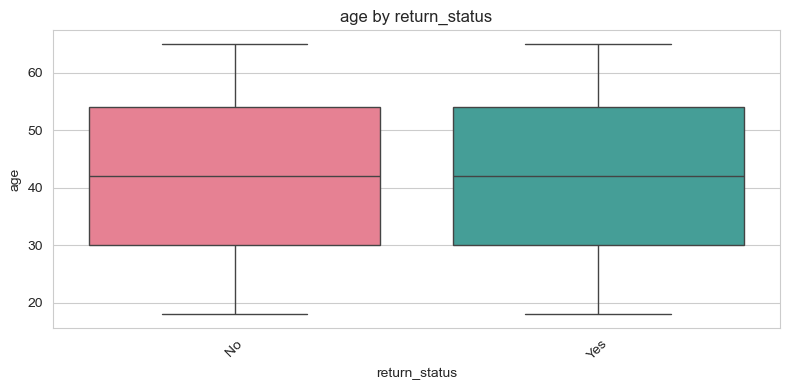

ANOVA age ~ return_status: F=0.02, p=0.8928 -> not significant difference between groups


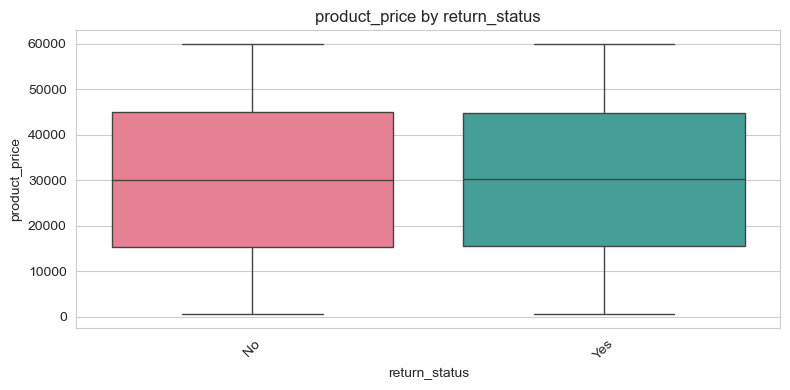

ANOVA product_price ~ return_status: F=0.13, p=0.7219 -> not significant difference between groups


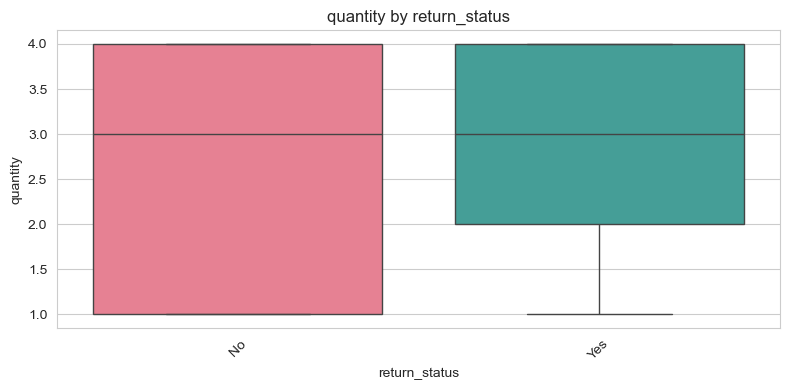

ANOVA quantity ~ return_status: F=0.81, p=0.3692 -> not significant difference between groups


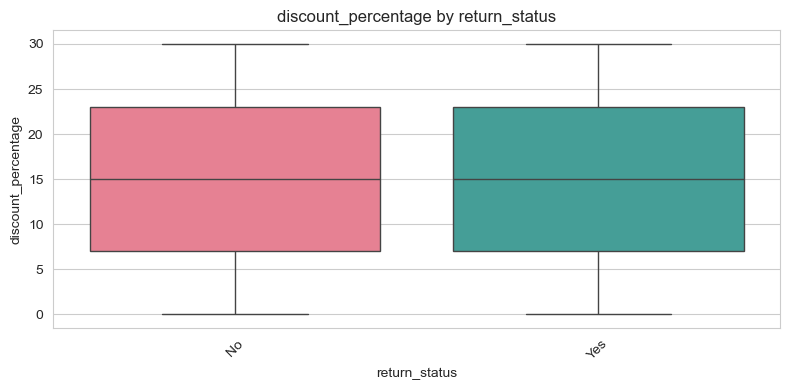

ANOVA discount_percentage ~ return_status: F=0.05, p=0.8303 -> not significant difference between groups


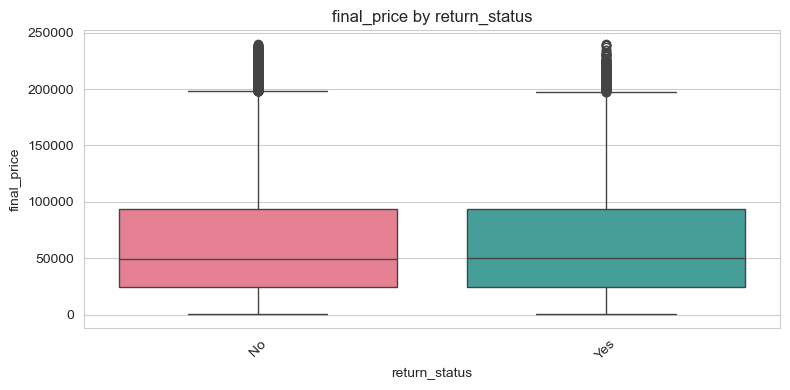

ANOVA final_price ~ return_status: F=0.41, p=0.5195 -> not significant difference between groups


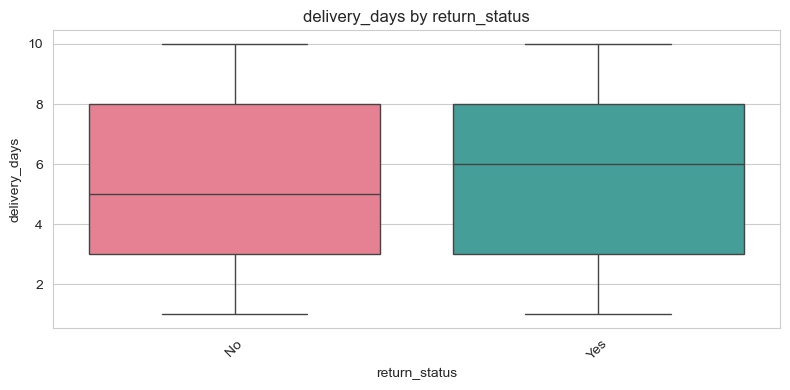

ANOVA delivery_days ~ return_status: F=0.03, p=0.8685 -> not significant difference between groups


In [26]:
def bivariate_numeric_categorical(df, numeric_cols, cat_cols, max_categories=10):
    """Boxplot of numeric column grouped by categorical column + ANOVA test."""
    for cat in cat_cols:
        if df[cat].nunique() > max_categories:
            print(f"Skipping {cat} - too many categories ({df[cat].nunique()})")
            continue
        for num in numeric_cols:
            plt.figure(figsize=(8, 4))
            sns.boxplot(x=df[cat], y=df[num], hue=df[cat], palette="husl", legend=False)
            plt.title(f'{num} by {cat}')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

            groups = [g[num].dropna() for _, g in df.groupby(cat)]
            if len(groups) > 1:
                f_stat, p_val = stats.f_oneway(*groups)
                sig = "significant" if p_val < 0.05 else "not significant"
                print(f"ANOVA {num} ~ {cat}: F={f_stat:.2f}, p={p_val:.4g} -> {sig} difference between groups")


bivariate_numeric_categorical(df, NUMERIC_COLS, CATEGORICAL_COLS)

### 3. CATEGORICAL vs CATEGORICAL

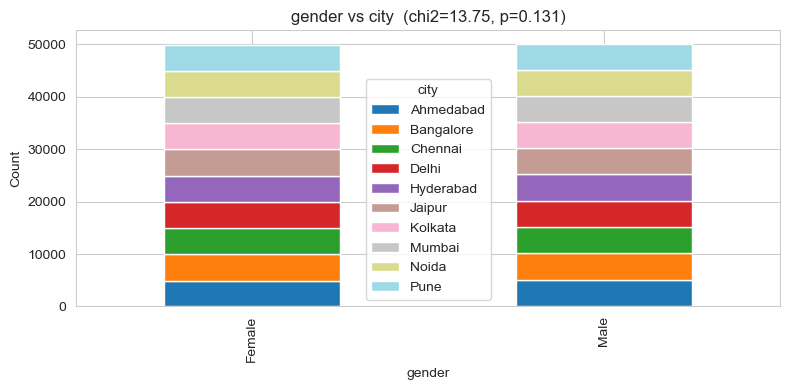

gender vs city: chi2=13.75, p=0.1314 -> variables are independent


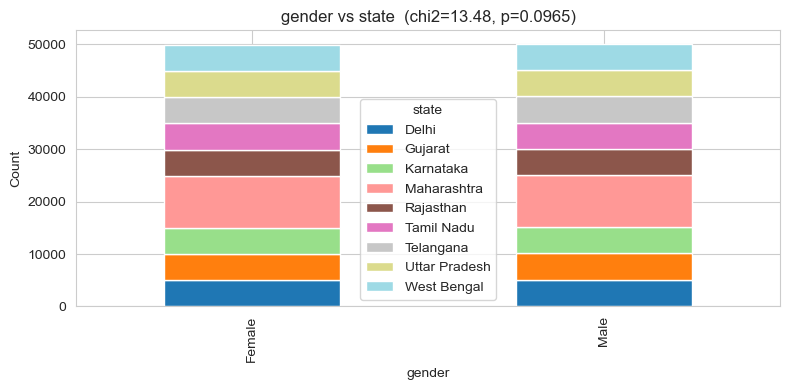

gender vs state: chi2=13.48, p=0.09646 -> variables are independent


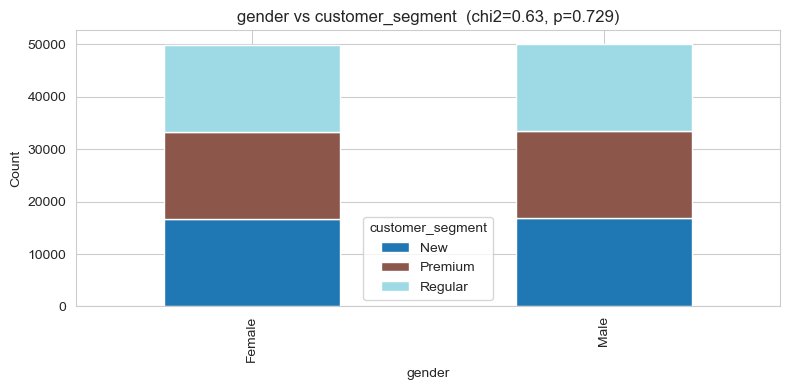

gender vs customer_segment: chi2=0.63, p=0.7293 -> variables are independent


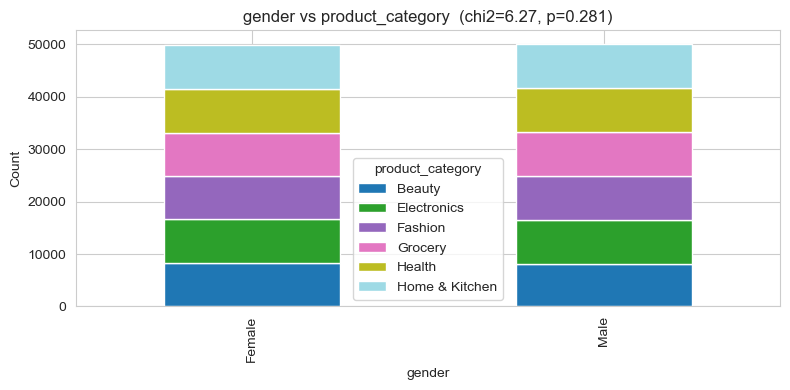

gender vs product_category: chi2=6.27, p=0.2806 -> variables are independent


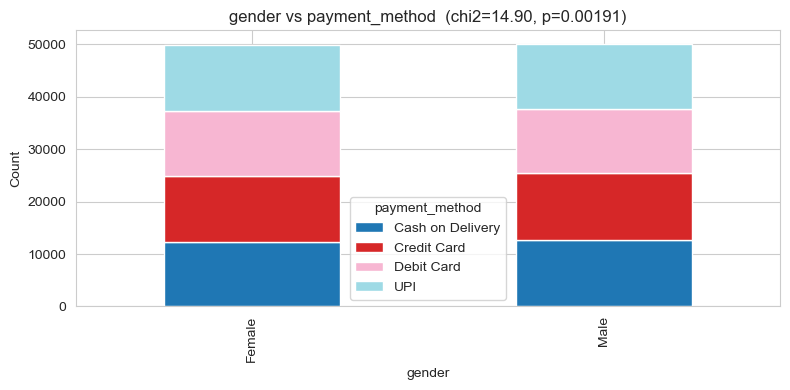

gender vs payment_method: chi2=14.90, p=0.001906 -> variables are associated


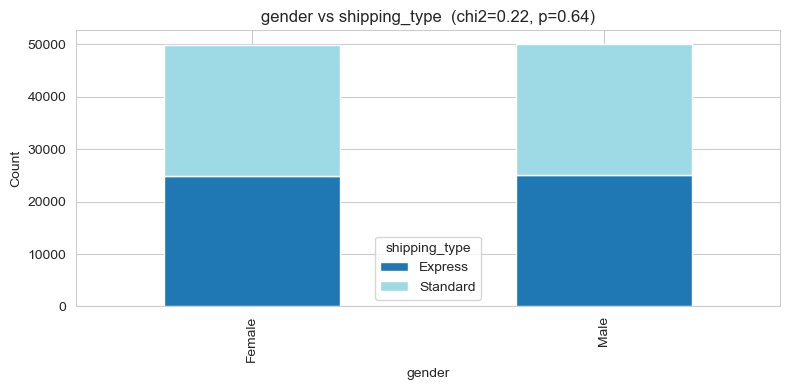

gender vs shipping_type: chi2=0.22, p=0.6399 -> variables are independent


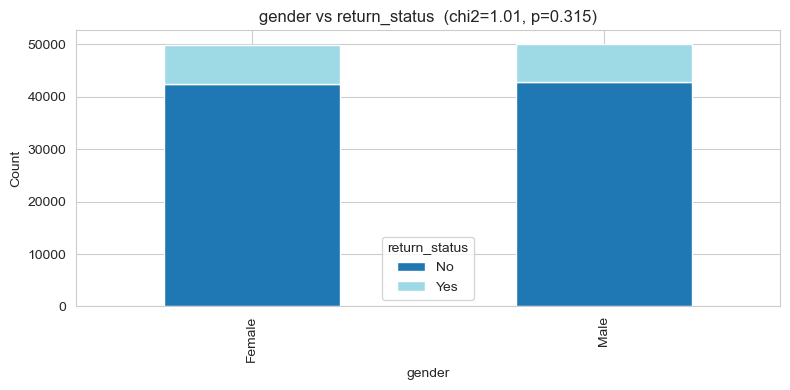

gender vs return_status: chi2=1.01, p=0.3149 -> variables are independent


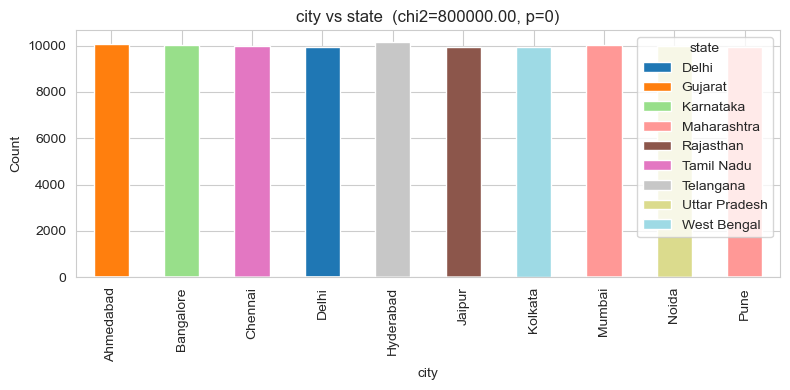

city vs state: chi2=800000.00, p=0 -> variables are associated


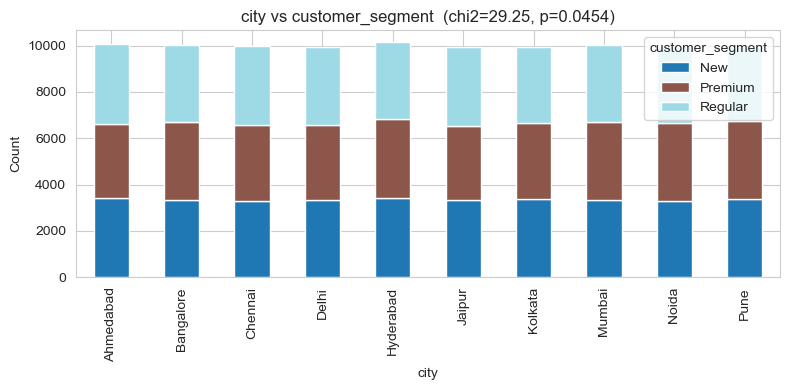

city vs customer_segment: chi2=29.25, p=0.04539 -> variables are associated


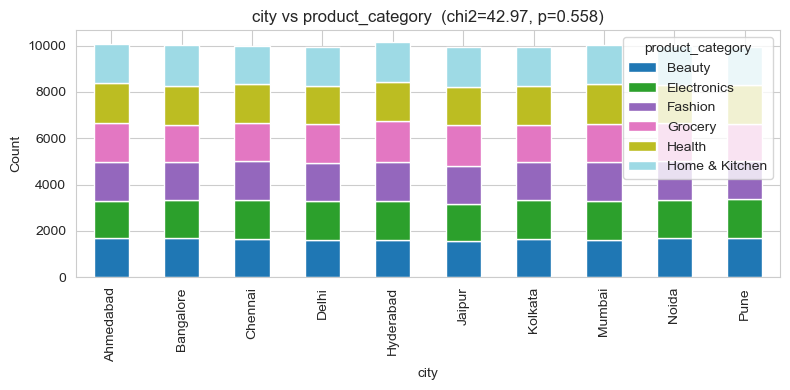

city vs product_category: chi2=42.97, p=0.5583 -> variables are independent


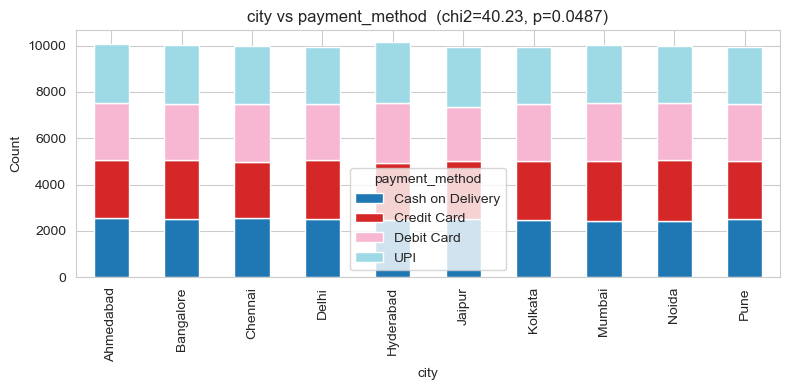

city vs payment_method: chi2=40.23, p=0.04872 -> variables are associated


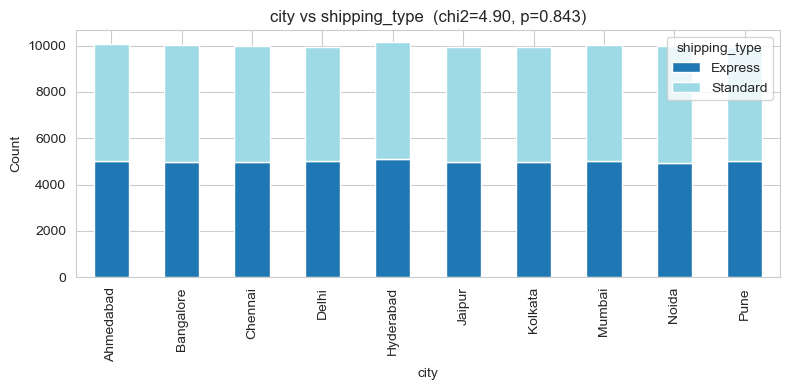

city vs shipping_type: chi2=4.90, p=0.843 -> variables are independent


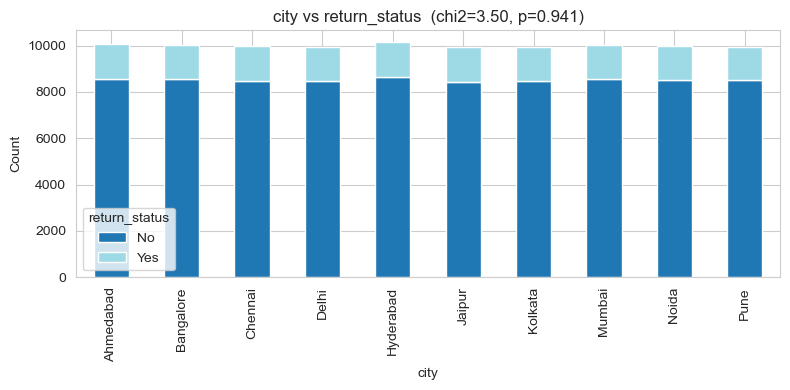

city vs return_status: chi2=3.50, p=0.9411 -> variables are independent


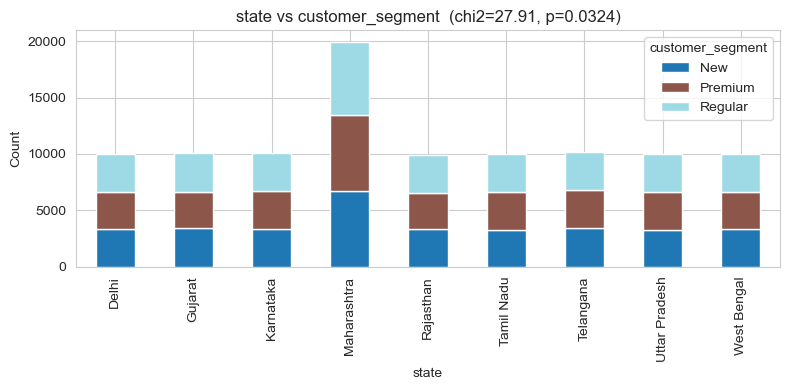

state vs customer_segment: chi2=27.91, p=0.03241 -> variables are associated


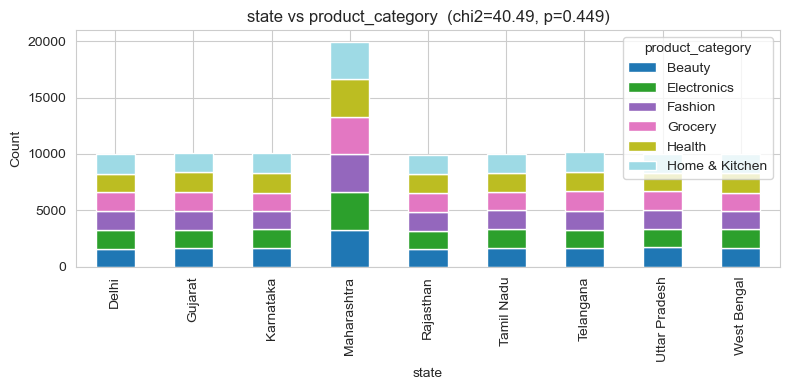

state vs product_category: chi2=40.49, p=0.4488 -> variables are independent


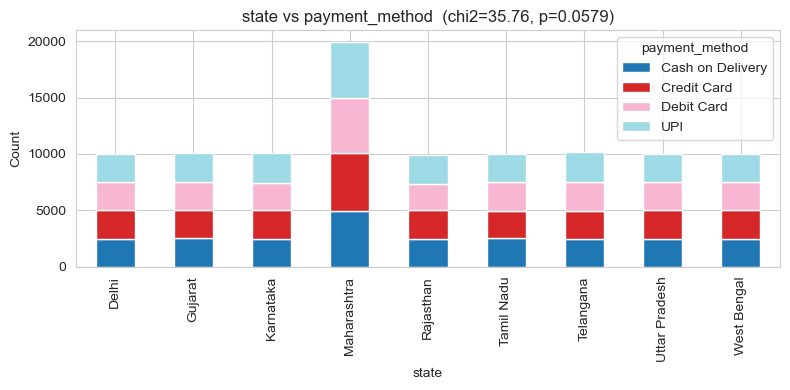

state vs payment_method: chi2=35.76, p=0.05787 -> variables are independent


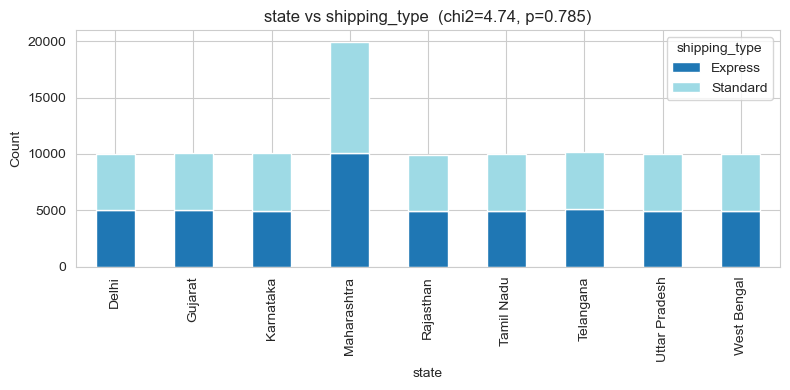

state vs shipping_type: chi2=4.74, p=0.7851 -> variables are independent


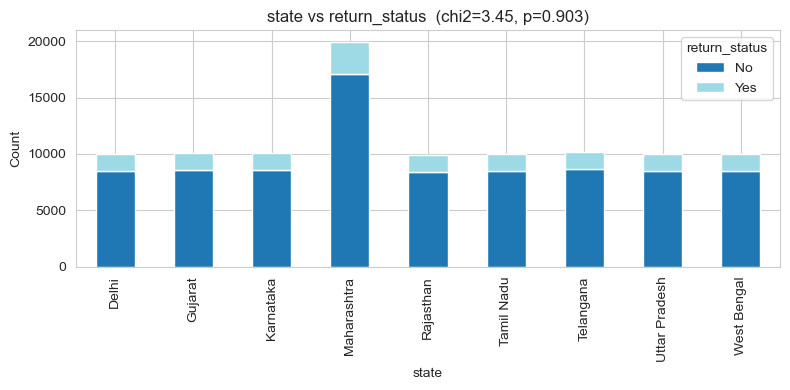

state vs return_status: chi2=3.45, p=0.9033 -> variables are independent


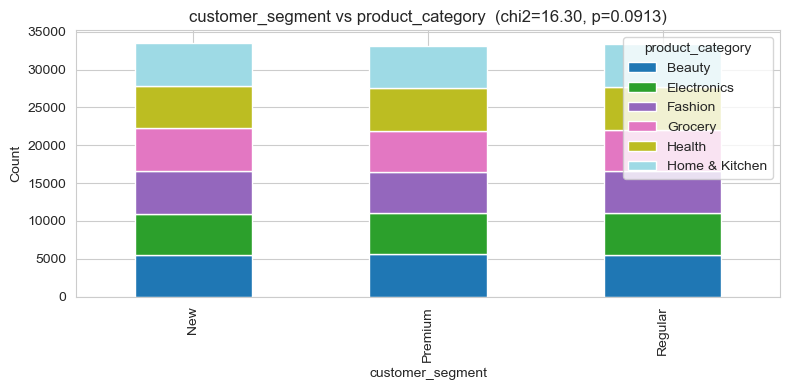

customer_segment vs product_category: chi2=16.30, p=0.09132 -> variables are independent


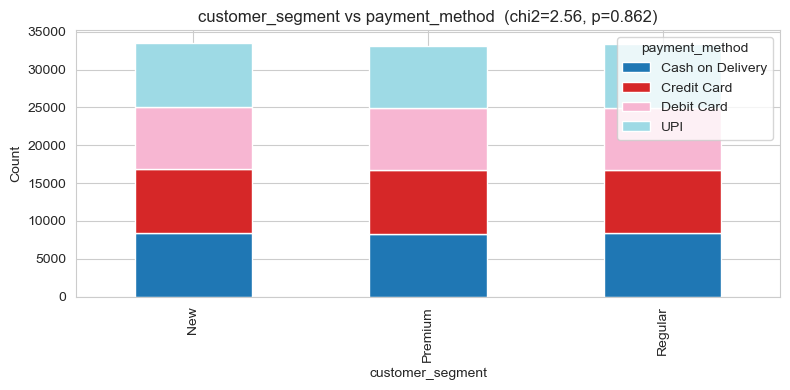

customer_segment vs payment_method: chi2=2.56, p=0.8622 -> variables are independent


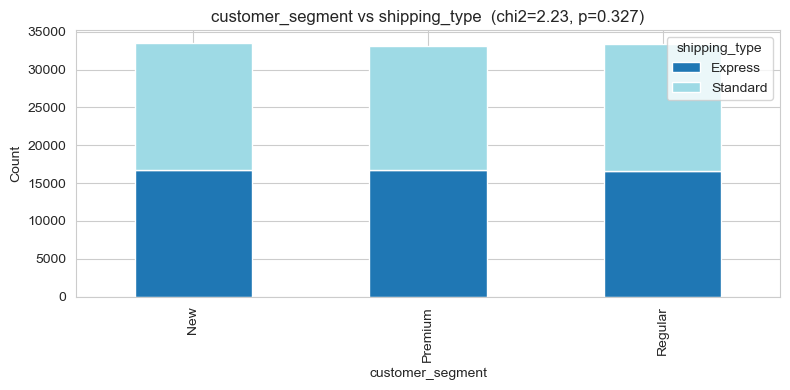

customer_segment vs shipping_type: chi2=2.23, p=0.3275 -> variables are independent


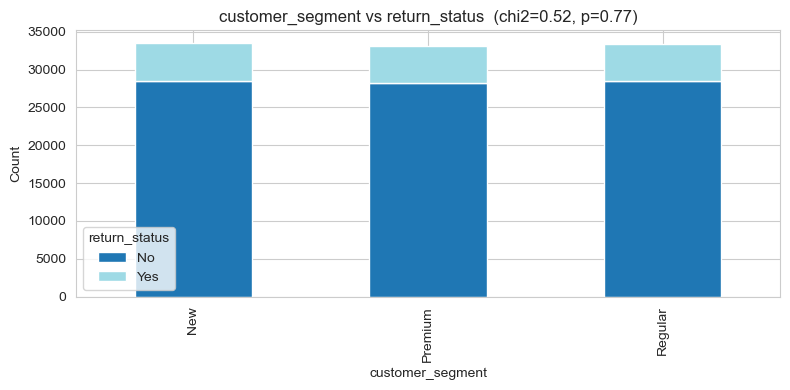

customer_segment vs return_status: chi2=0.52, p=0.7704 -> variables are independent


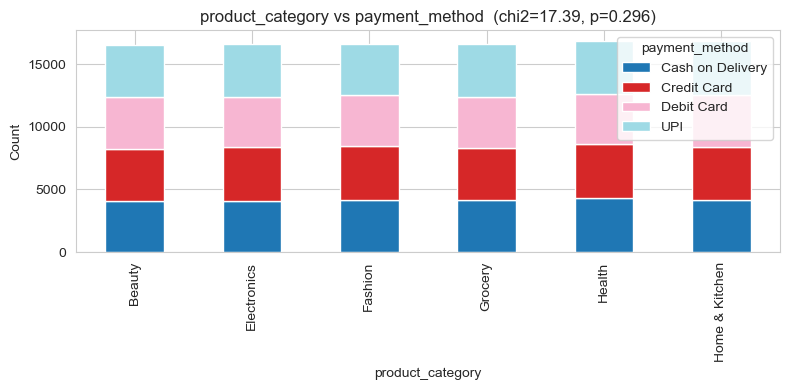

product_category vs payment_method: chi2=17.39, p=0.2964 -> variables are independent


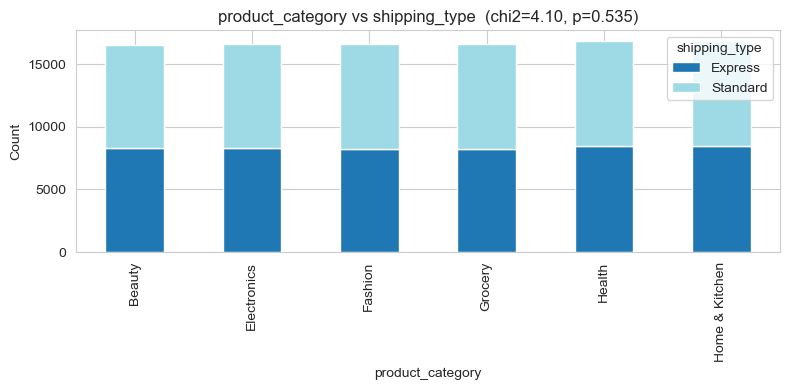

product_category vs shipping_type: chi2=4.10, p=0.5353 -> variables are independent


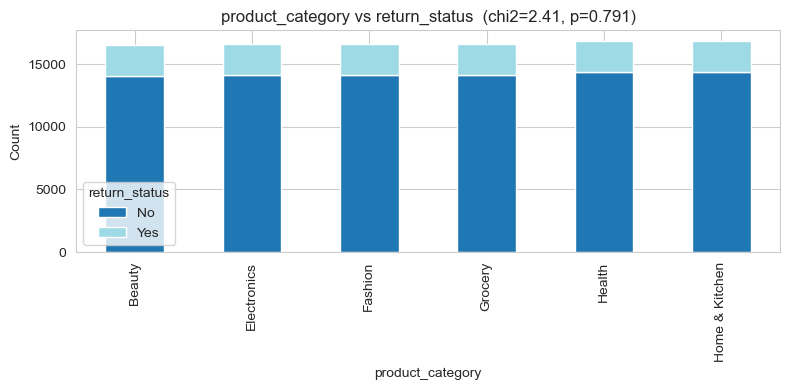

product_category vs return_status: chi2=2.41, p=0.7906 -> variables are independent


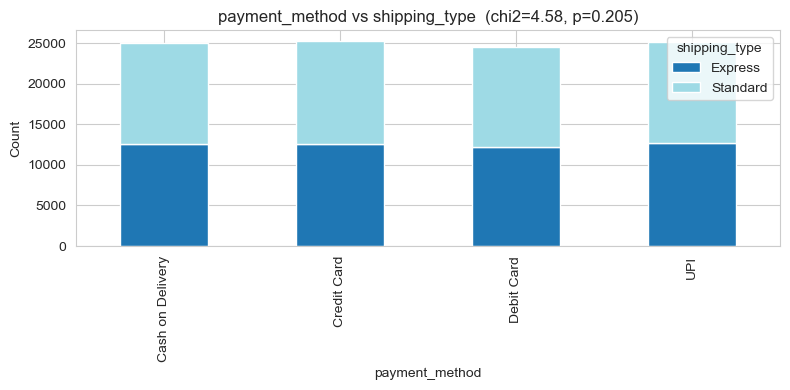

payment_method vs shipping_type: chi2=4.58, p=0.2053 -> variables are independent


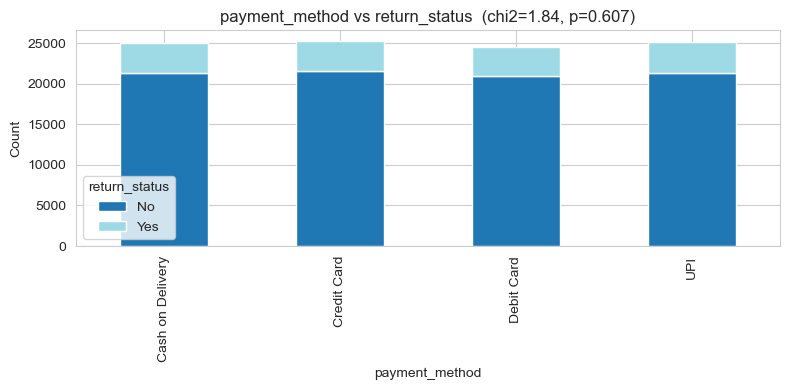

payment_method vs return_status: chi2=1.84, p=0.6069 -> variables are independent


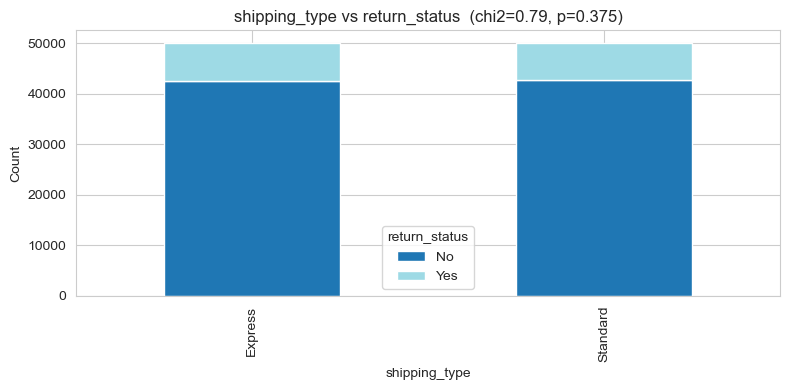

shipping_type vs return_status: chi2=0.79, p=0.3751 -> variables are independent


In [18]:

def bivariate_categorical_categorical(df, cols, max_categories=10):
    """Crosstab + stacked bar + chi-square test of independence."""
    for col1, col2 in combinations(cols, 2):
        if df[col1].nunique() > max_categories or df[col2].nunique() > max_categories:
            continue
 
        ct = pd.crosstab(df[col1], df[col2])
        chi2, p_val, dof, expected = stats.chi2_contingency(ct)
 
        ct.plot(kind='bar', stacked=True, figsize=(8, 4), colormap='tab20')
        plt.title(f'{col1} vs {col2}  (chi2={chi2:.2f}, p={p_val:.3g})')
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()
 
        sig = "associated" if p_val < 0.05 else "independent"
        print(f"{col1} vs {col2}: chi2={chi2:.2f}, p={p_val:.4g} -> variables are {sig}")
 
 
bivariate_categorical_categorical(df, CATEGORICAL_COLS)

#### 4. BIVARIATE OUTLIER DETECTION

##### Univariate outliers look at ONE column alone. Bivariate outliers are points
##### that break the RELATIONSHIP between two columns - e.g. a very high
##### product_price paired with a very low final_price (after discount) that
##### doesn't match the discount_percentage on record.

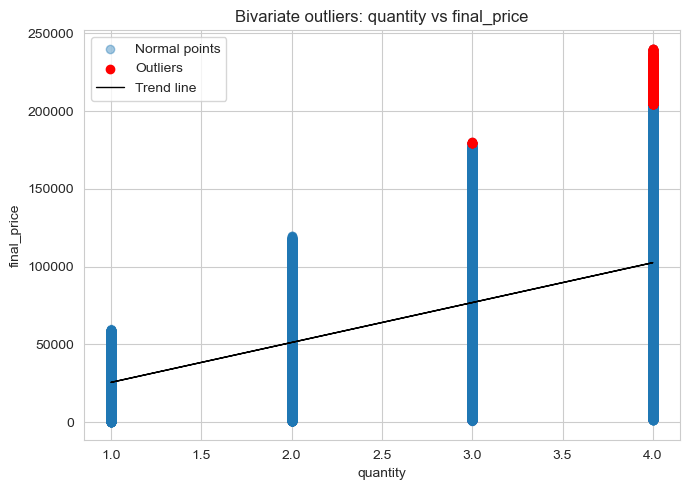

quantity vs final_price: 946 bivariate outliers found (0.95% of rows)


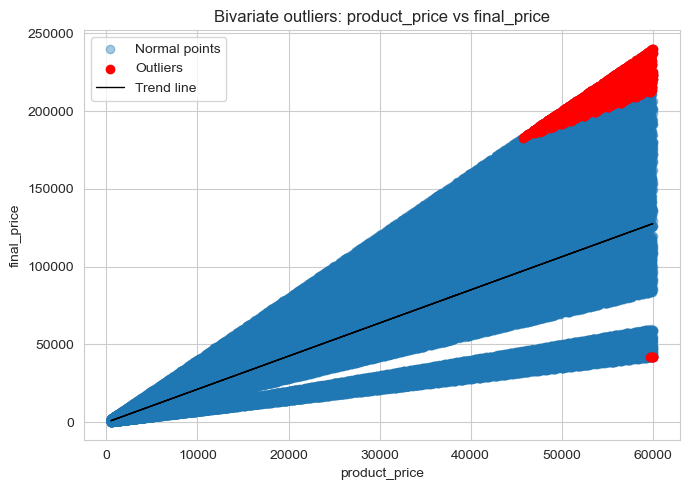

product_price vs final_price: 1288 bivariate outliers found (1.29% of rows)
product_price vs final_price (Mahalanobis): 2512 outliers found


In [19]:

 
def detect_outliers_residuals(df, x_col, y_col, threshold=2.5):
    """Fit a simple linear regression between x and y, then flag points
    whose residual (actual - predicted) is unusually large.
    This catches points that don't fit the overall trend, even if each
    value looks normal on its own."""
    sub = df[[x_col, y_col]].dropna()
    slope, intercept, r, p, se = stats.linregress(sub[x_col], sub[y_col])
    predicted = slope * sub[x_col] + intercept
    residuals = sub[y_col] - predicted
    z_resid = (residuals - residuals.mean()) / residuals.std()
 
    mask = z_resid.abs() > threshold
    outlier_idx = sub.index[mask]
 
    plt.figure(figsize=(7, 5))
    plt.scatter(sub[x_col], sub[y_col], alpha=0.4, label='Normal points')
    plt.scatter(sub.loc[outlier_idx, x_col], sub.loc[outlier_idx, y_col],
                color='red', label='Outliers', zorder=5)
    plt.plot(sub[x_col], predicted, color='black', linewidth=1, label='Trend line')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f'Bivariate outliers: {x_col} vs {y_col}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"{x_col} vs {y_col}: {mask.sum()} bivariate outliers found "
          f"({mask.sum()/len(sub)*100:.2f}% of rows)")
    return outlier_idx

def detect_outliers_mahalanobis(df, x_col, y_col, threshold=None):
    """Mahalanobis distance accounts for correlation between the two
    variables (unlike Euclidean distance). Flags points far from the
    joint center of the two-variable distribution."""
    sub = df[[x_col, y_col]].dropna()
    cov = np.cov(sub[x_col], sub[y_col])
    inv_cov = np.linalg.inv(cov)
    mean_vec = sub.mean().values
 
    diff = sub.values - mean_vec
    md = np.sqrt(np.einsum('ij,jk,ik->i', diff, inv_cov, diff))

    # Chi-square critical value with 2 degrees of freedom (95% confidence)
    if threshold is None:
        threshold = np.sqrt(stats.chi2.ppf(0.975, df=2))
 
    mask = md > threshold
    outlier_idx = sub.index[mask]
 
    print(f"{x_col} vs {y_col} (Mahalanobis): {mask.sum()} outliers found")
    return outlier_idx

# Example: check price/quantity relationship, and price/discount relationship
price_qty_outliers = detect_outliers_residuals(df, 'quantity', 'final_price')
price_discount_outliers = detect_outliers_residuals(df, 'product_price', 'final_price')
mahal_outliers = detect_outliers_mahalanobis(df, 'product_price', 'final_price')

#### 5. LOGICAL / RULE-BASED OUTLIER CHECK (retail-specific)

In [20]:

def check_price_discount_consistency(df):
    """final_price should equal product_price * (1 - discount_percentage/100).
    Large mismatches indicate data entry errors, not just statistical outliers."""
    expected_final = df['product_price'] * (1 - df['discount_percentage'] / 100)
    diff = (df['final_price'] - expected_final).abs()
    mismatch_mask = diff > 1  # tolerance of 1 currency unit for rounding
 
    print(f"\nRows where final_price doesn't match product_price & discount: "
          f"{mismatch_mask.sum()} ({mismatch_mask.sum()/len(df)*100:.2f}%)")
    return mismatch_mask, expected_final
 
 
mismatch_mask, expected_final = check_price_discount_consistency(df)
 


Rows where final_price doesn't match product_price & discount: 74920 (74.92%)


#### 6. OUTLIER CORRECTION


Total unique bivariate outlier rows flagged: 1375

Before vs After (final_price):
              before          after
count  100000.000000  100000.000000
mean    64165.723382   25266.948220
std     49969.280150   14555.174429
min       357.000000     357.000000
25%     24705.000000   12919.957500
50%     49752.390000   25355.865000
75%     94046.070000   37140.835000
max    239980.000000   59972.000000


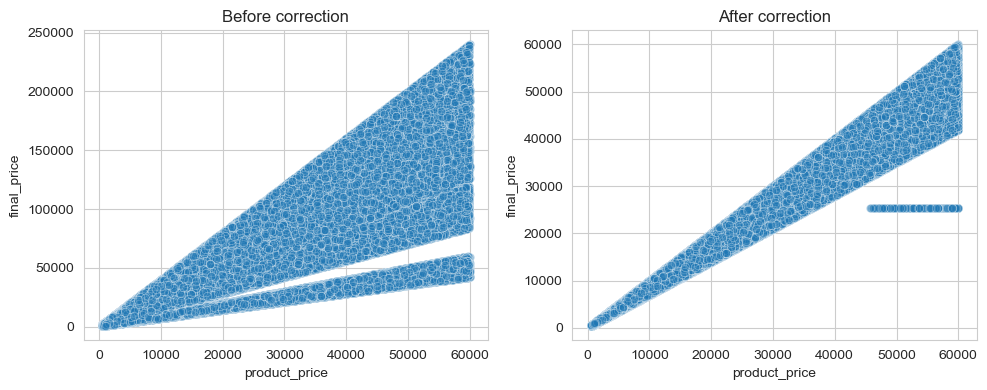

In [21]:

df_clean = df.copy()
 
# ---- (a) Fix logical inconsistencies first: recompute final_price ----
df_clean.loc[mismatch_mask, 'final_price'] = expected_final[mismatch_mask]
 
# ---- (b) Cap statistical outliers in numeric columns using IQR ----
def cap_outliers_iqr(df, col):
    data = df[col]
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df[col] = data.clip(lower=lower, upper=upper)
    return df

for col in ['product_price', 'final_price', 'quantity', 'delivery_days']:
    df_clean = cap_outliers_iqr(df_clean, col)
 
# ---- (c) Remove residual-based bivariate outliers (extreme mismatches only) ----
combined_outlier_idx = price_qty_outliers.union(price_discount_outliers)
print(f"\nTotal unique bivariate outlier rows flagged: {len(combined_outlier_idx)}")
 
# Option 1: drop them (only if confirmed as errors)
# df_clean = df_clean.drop(index=combined_outlier_idx)
 
# Option 2 (safer default): keep rows, just cap the offending column
df_clean.loc[combined_outlier_idx, 'final_price'] = df_clean['final_price'].median()
 
print("\nBefore vs After (final_price):")
print(pd.concat([df['final_price'].describe(), df_clean['final_price'].describe()],
                 axis=1, keys=['before', 'after']))
 
# ---- (d) Visual confirmation ----
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.scatterplot(x=df['product_price'], y=df['final_price'], alpha=0.4, ax=axes[0])
axes[0].set_title('Before correction')
 
sns.scatterplot(x=df_clean['product_price'], y=df_clean['final_price'], alpha=0.4, ax=axes[1])
axes[1].set_title('After correction')
plt.tight_layout()
plt.show()
 

## MULTIVARIATE ANALYSIS

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
 
sns.set_style('whitegrid')
 


In [27]:
FILE_PATH = r'D:\Awantika\Data Science Class notes\Basics_Python\Basics_Python\retail_large_dataset.csv'

In [28]:
NUMERIC_COLS = ['age', 'product_price', 'quantity',
                'discount_percentage', 'final_price', 'delivery_days']

In [29]:
NUMERIC_COLS

['age',
 'product_price',
 'quantity',
 'discount_percentage',
 'final_price',
 'delivery_days']

In [30]:
CATEGORICAL_COLS = ['gender', 'city', 'state', 'customer_segment',
                     'product_category', 'product_subcategory',
                     'payment_method', 'shipping_type', 'return_status']

In [31]:
CATEGORICAL_COLS

['gender',
 'city',
 'state',
 'customer_segment',
 'product_category',
 'product_subcategory',
 'payment_method',
 'shipping_type',
 'return_status']

In [32]:
df = pd.read_csv(FILE_PATH)

In [33]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

In [34]:
df['order_date']

0       2025-05-10
1       2023-11-27
2       2025-02-08
3       2024-04-19
4       2024-10-08
           ...    
99995   2024-06-11
99996   2024-04-27
99997   2024-04-14
99998   2024-09-08
99999   2025-11-15
Name: order_date, Length: 100000, dtype: datetime64[ns]

In [36]:
df.shape

(100000, 18)

In [38]:
df

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,C109995,29,Female,Pune,Maharashtra,Regular,O149995,2024-06-11,Health,Supplements,49293,1,11,43870.77,Debit Card,Standard,9,No
99996,C109996,28,Male,Mumbai,Maharashtra,Premium,O149996,2024-04-27,Fashion,Men T-Shirt,5722,2,22,8926.32,Cash on Delivery,Express,1,No
99997,C109997,44,Female,Jaipur,Rajasthan,Premium,O149997,2024-04-14,Grocery,Snacks,6311,4,11,22467.16,Cash on Delivery,Express,9,No
99998,C109998,45,Male,Jaipur,Rajasthan,Premium,O149998,2024-09-08,Beauty,Shampoo,46888,1,28,33759.36,Debit Card,Standard,1,No


### 1. CORRELATION HEATMAP & PAIRPLOT (whole numeric block together)

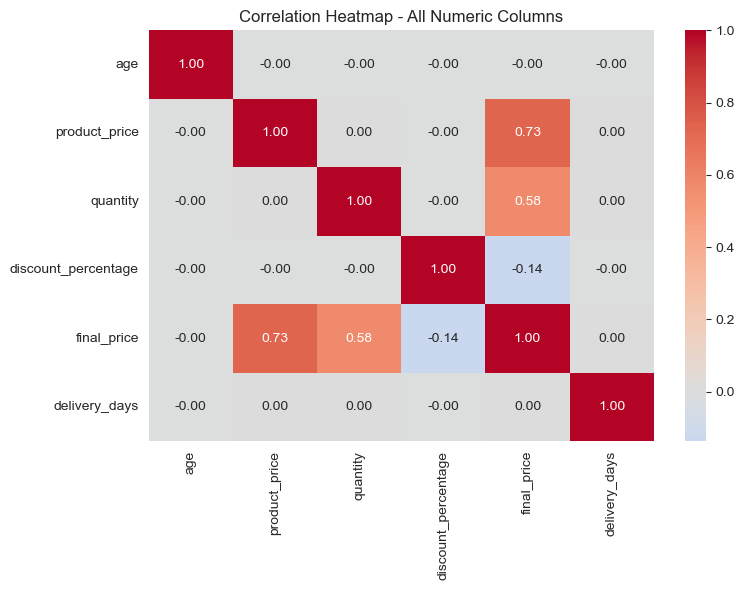

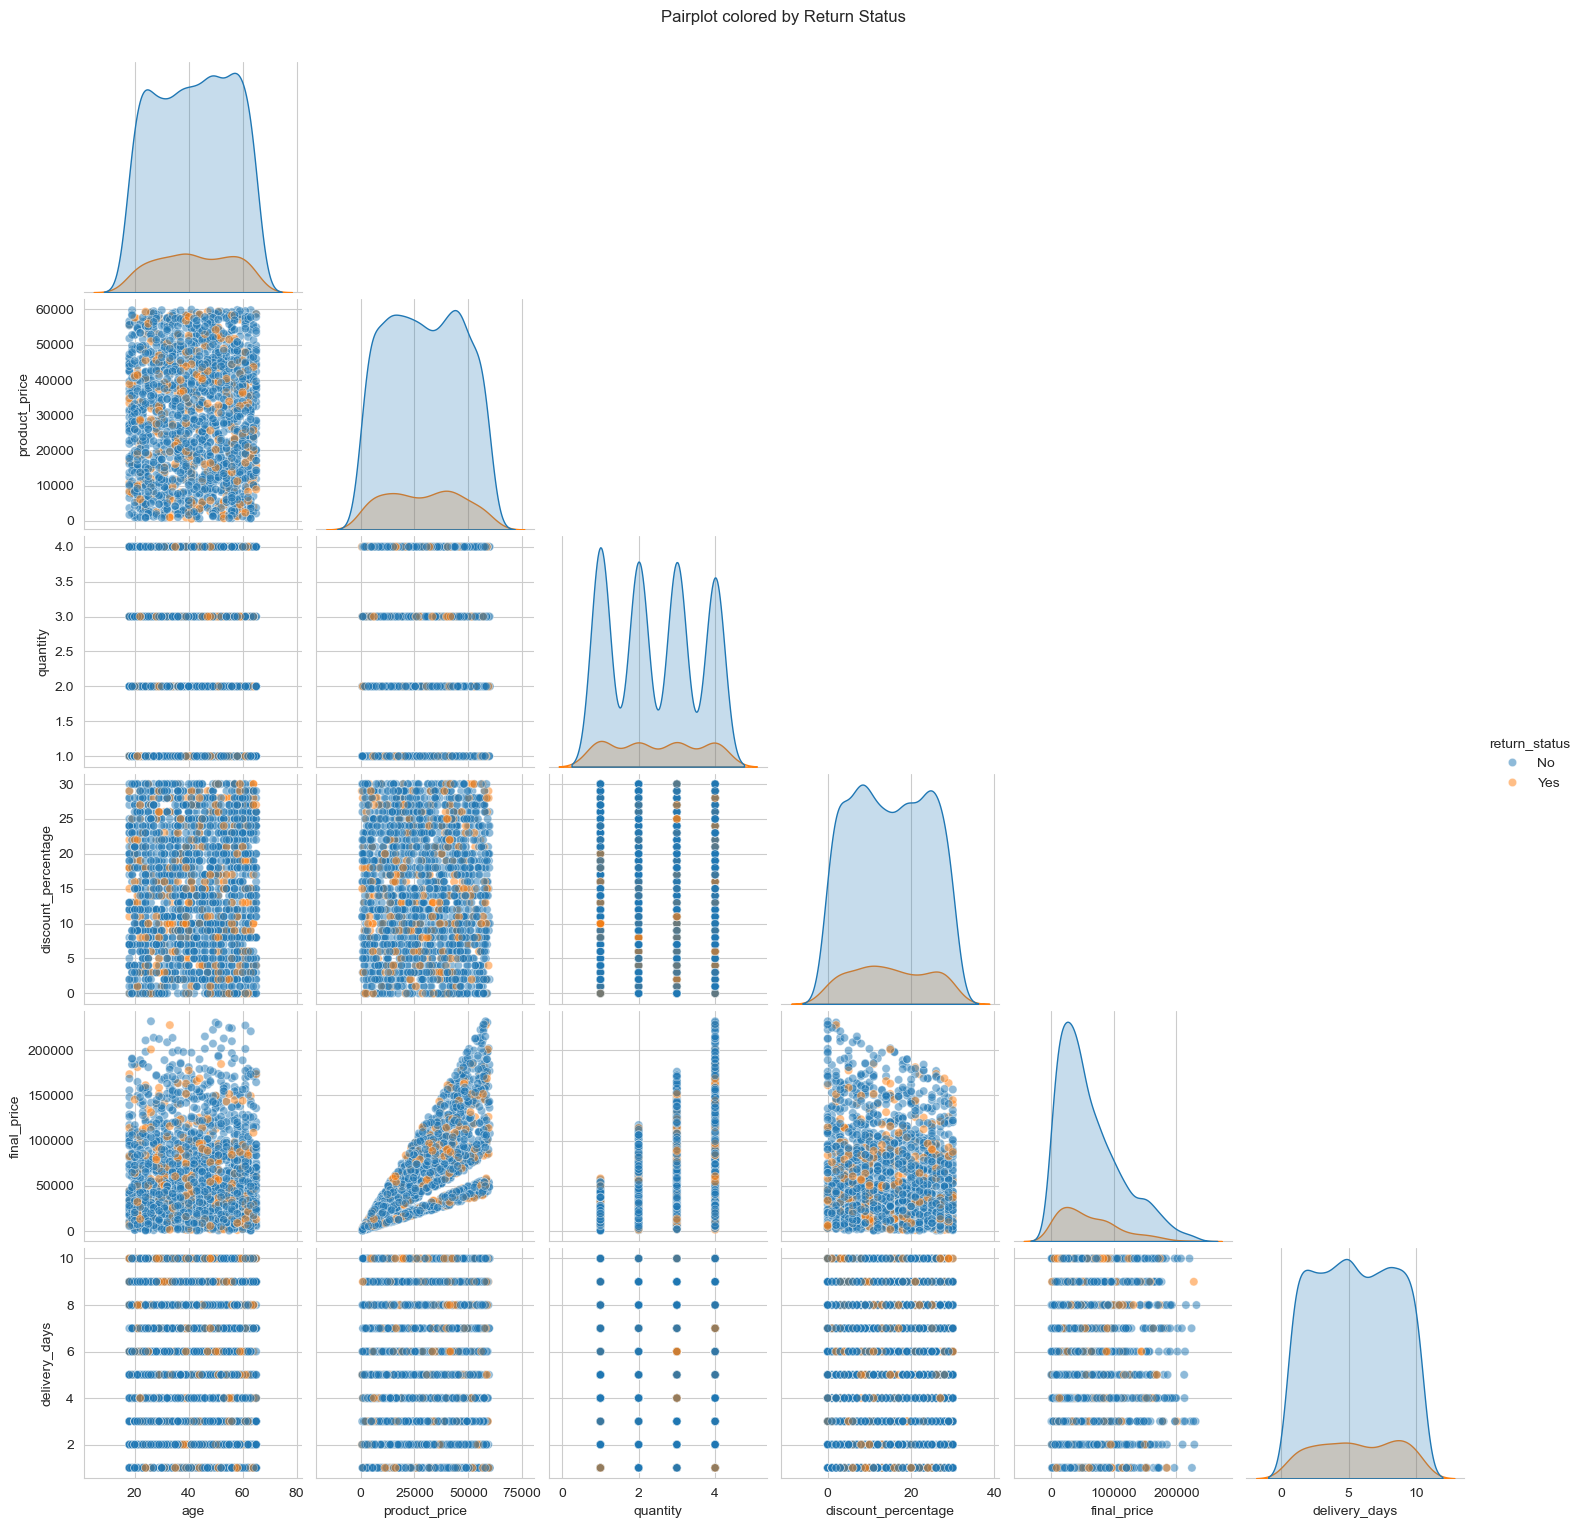

In [40]:
plt.figure(figsize=(8, 6))
corr_matrix = df[NUMERIC_COLS].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - All Numeric Columns')
plt.tight_layout()
plt.show()
 
sample_df = df.sample(min(2000, len(df)), random_state=42)
sns.pairplot(sample_df[NUMERIC_COLS + ['return_status']].dropna(),
             hue='return_status', corner=True, diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot colored by Return Status', y=1.02)
plt.show()
 

### 2. GROUPED MULTIVARIATE SUMMARY

In [18]:
def grouped_summary(df, numeric_cols, group_col):
    summary = df.groupby(group_col)[numeric_cols].agg(['mean', 'median', 'std'])
    print(f"\nSummary of numeric columns grouped by {group_col}:\n", summary)
    return summary
 
 
grouped_summary(df, NUMERIC_COLS, 'product_category')
grouped_summary(df, NUMERIC_COLS, 'customer_segment')
 


Summary of numeric columns grouped by product_category:
                         age                   product_price           \
                       mean median        std          mean   median   
product_category                                                       
Beauty            41.470902   41.0  13.873377  30058.165324  29931.0   
Electronics       41.686776   42.0  13.851838  30452.550314  30751.0   
Fashion           41.595317   42.0  13.830665  29955.913080  30103.0   
Grocery           41.419841   41.0  13.806055  30105.133136  29831.0   
Health            41.664017   42.0  13.848799  30137.817179  30109.5   
Home & Kitchen    41.532585   42.0  13.903145  30276.319979  30273.5   

                                quantity                  discount_percentage  \
                           std      mean median       std                mean   
product_category                                                                
Beauty            17164.751497  2.505602    3.0  1

age                   product_price           \
                       mean median        std          mean   median   
customer_segment                                                       
New               41.585613   42.0  13.844775  29995.404623  29908.0   
Premium           41.576453   42.0  13.845519  30228.316250  30273.0   
Regular           41.523426   42.0  13.867331  30270.904649  30312.0   

                                quantity                  discount_percentage  \
                           std      mean median       std                mean   
customer_segment                                                                
New               17077.332286  2.497074    2.0  1.120155           14.970497   
Premium           17179.758962  2.508853    3.0  1.117867           14.976441   
Regular           17161.491651  2.499505    3.0  1.122132           15.082671   

                                    final_price                          \
                 median       std          mean    median           std   
customer_segment                                                          
New                15.0  8.961138  63766.749294  49224.52  49878.810458   
Premium            15.0  8.951862  64430.451339  50273.88  49978.058763   
Regular            15.0  8.946668  64303.154748  49767.84  50050.235496   

                 delivery_days                   
                          mean median       std  
customer_segment                                 
New                   5.519171    6.0  2.872634  
Premium               5.507406    5.0  2.866386  
Regular               5.490003    5.0  2.879541

### 3. PIVOT-TABLE HEATMAPS (2 categorical dims x 1 numeric measure)

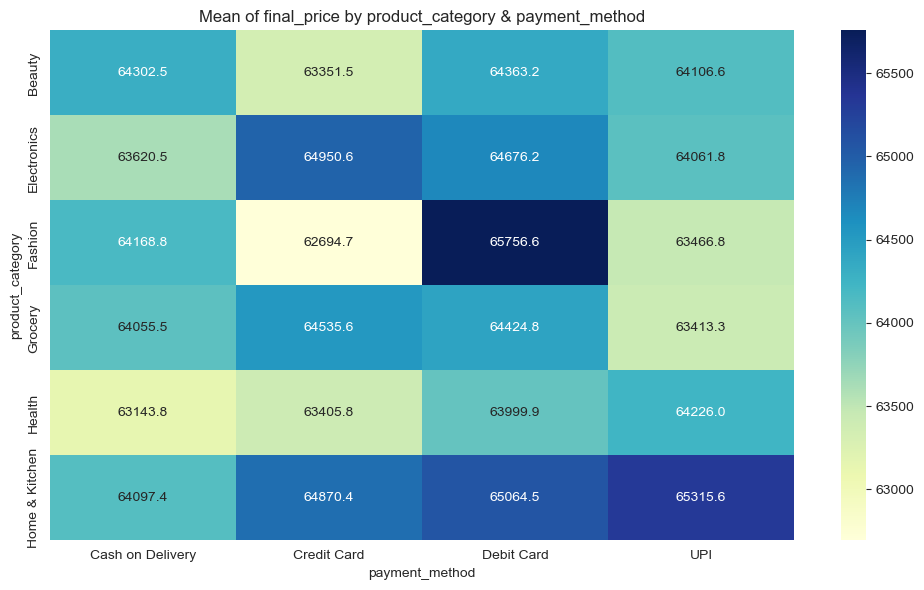

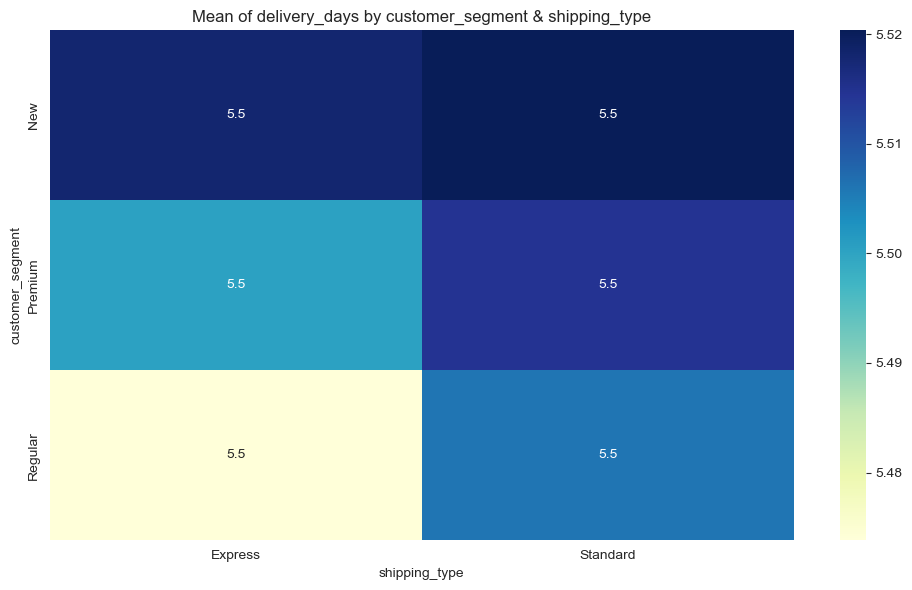

shipping_type,Express,Standard
customer_segment,,
New,5.518003,5.520328
Premium,5.500360,5.514544
Regular,5.473830,5.506137


In [19]:
def pivot_heatmap(df, index_col, columns_col, value_col, agg='mean'):
    pivot = df.pivot_table(index=index_col, columns=columns_col,
                            values=value_col, aggfunc=agg)
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGnBu')
    plt.title(f'{agg.capitalize()} of {value_col} by {index_col} & {columns_col}')
    plt.tight_layout()
    plt.show()
    return pivot
 
 
pivot_heatmap(df, index_col='product_category', columns_col='payment_method',
              value_col='final_price')
pivot_heatmap(df, index_col='customer_segment', columns_col='shipping_type',
              value_col='delivery_days')

### 4. MULTIVARIATE OUTLIER DETECTION

#### Univariate = one column. Bivariate = two columns. Multivariate = 3+ columns considered TOGETHER. A row can look fine on every column individually and still be an outlier because of how the columns combine.

In [42]:
analysis_cols = ['age', 'product_price', 'quantity', 'discount_percentage',
                  'final_price', 'delivery_days']
data = df[analysis_cols].dropna()

In [43]:
data

,age,product_price,quantity,discount_percentage,final_price,delivery_days
0,56,38658,3,7,107855.82,5
1,36,22462,4,20,71878.40,4
2,20,56601,2,27,82637.46,5
3,39,26158,3,9,71411.34,3
4,20,31240,1,6,29365.60,2
...,...,...,...,...,...,...
99995,29,49293,1,11,43870.77,9
99996,28,5722,2,22,8926.32,1
99997,44,6311,4,11,22467.16,9
99998,45,46888,1,28,33759.36,1


### Method A: Mahalanobis Distance ,Generalizes z-score to many dimensions at once, accounting for correlation between columns. Large distance = far from the "center" of the data cloud.

In [21]:
def mahalanobis_outliers(data, cols, alpha=0.001):
    X = data[cols].values
    mean_vec = X.mean(axis=0)
    cov = np.cov(X, rowvar=False)
    inv_cov = np.linalg.inv(cov)
 
    diff = X - mean_vec
    md = np.sqrt(np.einsum('ij,jk,ik->i', diff, inv_cov, diff))
 
    # Chi-square critical value: degrees of freedom = number of columns
    threshold = np.sqrt(stats.chi2.ppf(1 - alpha, df=len(cols)))
    mask = md > threshold
    return mask, md, threshold
 
 
mahal_mask, mahal_dist, mahal_threshold = mahalanobis_outliers(data, analysis_cols)
print(f"\nMahalanobis distance: {mahal_mask.sum()} multivariate outliers "
      f"out of {len(data)} rows ({mahal_mask.sum()/len(data)*100:.2f}%)  "
      f"[threshold = {mahal_threshold:.2f}]")


Mahalanobis distance: 17 multivariate outliers out of 100000 rows (0.02%)  [threshold = 4.74]


#### Method B: Isolation Forest 

#### A tree-based ML model that isolates anomalies faster than normal points (outliers need fewer random splits to separate from the rest). Works well with many columns and doesn't assume any particular distribution shape.

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[analysis_cols])
 
iso_forest = IsolationForest(contamination=0.02, random_state=42)
iso_pred = iso_forest.fit_predict(X_scaled)   # -1 = outlier, 1 = normal
iso_mask = iso_pred == -1
 
print(f"Isolation Forest: {iso_mask.sum()} multivariate outliers "
      f"out of {len(data)} rows ({iso_mask.sum()/len(data)*100:.2f}%)")

Isolation Forest: 2000 multivariate outliers out of 100000 rows (2.00%)


#### Method C: PCA-based visual check 

#### Reduce many numeric columns to 2 principal components so outliers that are hard to see in high dimensions become visible on a 2D scatter plot.

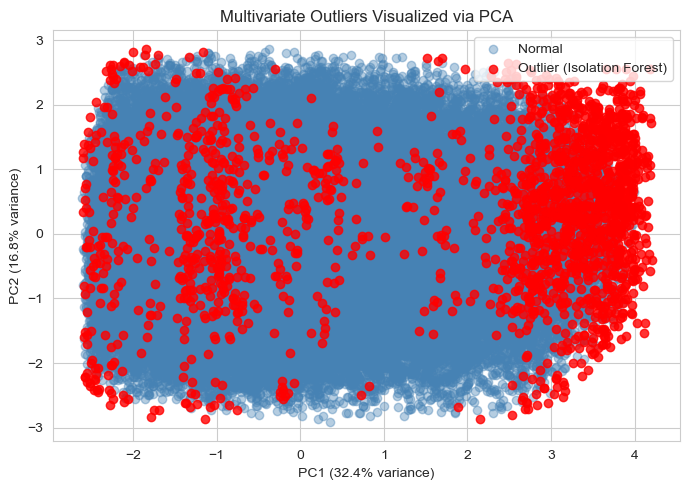

In [58]:
# ---- Method C: PCA-based visual check ----
# Reduce many numeric columns to 2 principal components so outliers that
# are hard to see in high dimensions become visible on a 2D scatter plot.
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
 
plt.figure(figsize=(7, 5))
plt.scatter(pca_result[~iso_mask, 0], pca_result[~iso_mask, 1],
            alpha=0.4, label='Normal', color='steelblue')
plt.scatter(pca_result[iso_mask, 0], pca_result[iso_mask, 1],
            alpha=0.8, label='Outlier (Isolation Forest)', color='red')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Multivariate Outliers Visualized via PCA')
plt.legend()
plt.tight_layout()
plt.show()
 

### Combine flags from both statistical methods into the main dataframe

In [59]:
data_flagged = data.copy()
data_flagged['mahalanobis_outlier'] = mahal_mask
data_flagged['isolation_forest_outlier'] = iso_mask
data_flagged['outlier_agreement'] = mahal_mask & iso_mask  # flagged by both
 
print(f"\nRows flagged by BOTH methods (highest confidence outliers): "
      f"{data_flagged['outlier_agreement'].sum()}")


Rows flagged by BOTH methods (highest confidence outliers): 17


## 5. MULTIVARIATE OUTLIER CORRECTION

In [60]:
df_clean = df.copy()
outlier_index = data_flagged.index[data_flagged['outlier_agreement']]
 
print(f"\nCorrecting {len(outlier_index)} high-confidence multivariate outliers...")
 
# ---- Option 1: Cap each numeric column at its own IQR bounds (safe default) ----
# Applied only to the flagged rows, so normal rows are untouched.
def cap_to_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return series.clip(lower, upper)
 
for col in analysis_cols:
    df_clean.loc[outlier_index, col] = cap_to_iqr(df_clean[col]).loc[outlier_index]


Correcting 17 high-confidence multivariate outliers...



Before vs After correction (final_price):
              before          after
count  100000.000000  100000.000000
mean    64165.723382   64134.056900
std     49969.280150   49919.328707
min       357.000000     357.000000
25%     24705.000000   24705.000000
50%     49752.390000   49745.880000
75%     94046.070000   94010.410000
max    239980.000000  239444.000000


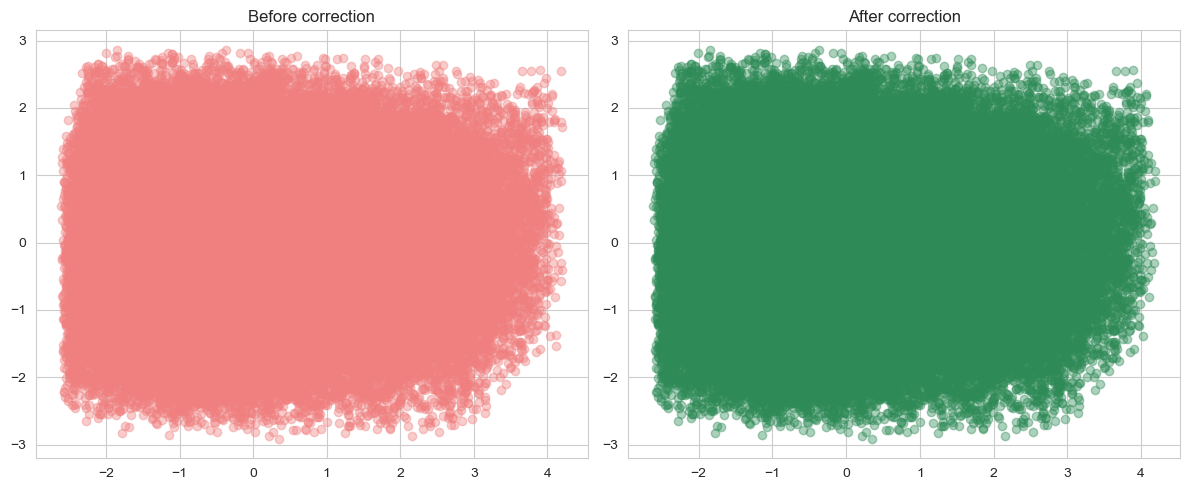

In [61]:
# ---- Option 2: Remove flagged rows entirely (only if confirmed as bad data) ----
# df_clean = df_clean.drop(index=outlier_index)
 
# ---- Option 3: Impute with group-level median instead of a global one ----
# More accurate for retail data since "typical" final_price differs a lot
# by product_category - a global median would distort category patterns.
def impute_with_group_median(df, col, group_col, idx):
    group_medians = df.groupby(group_col)[col].transform('median')
    df.loc[idx, col] = group_medians.loc[idx]
    return df
 
df_clean = impute_with_group_median(df_clean, 'final_price', 'product_category', outlier_index)
 
print("\nBefore vs After correction (final_price):")
print(pd.concat([df['final_price'].describe(), df_clean['final_price'].describe()],
                 axis=1, keys=['before', 'after']))
 
# ---- Visual confirmation: PCA plot before vs after ----
X_after = scaler.transform(df_clean.loc[data.index, analysis_cols])
pca_after = pca.transform(X_after)
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.4, color='lightcoral')
axes[0].set_title('Before correction')
 
axes[1].scatter(pca_after[:, 0], pca_after[:, 1], alpha=0.4, color='seagreen')
axes[1].set_title('After correction')
plt.tight_layout()
plt.show()

## Skewness & Kurtosis Analysis for Retail Transaction Data

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
 
sns.set_style('whitegrid')
 

In [45]:
FILE_PATH = r'D:\Awantika\Data Science Class notes\Basics_Python\Basics_Python\retail_large_dataset.csv'

In [46]:
NUMERIC_COLS = ['age', 'product_price', 'quantity',
                'discount_percentage', 'final_price', 'delivery_days']

In [47]:
NUMERIC_COLS

['age',
 'product_price',
 'quantity',
 'discount_percentage',
 'final_price',
 'delivery_days']

In [48]:
df = pd.read_csv(FILE_PATH)

In [49]:
df

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,C109995,29,Female,Pune,Maharashtra,Regular,O149995,2024-06-11,Health,Supplements,49293,1,11,43870.77,Debit Card,Standard,9,No
99996,C109996,28,Male,Mumbai,Maharashtra,Premium,O149996,2024-04-27,Fashion,Men T-Shirt,5722,2,22,8926.32,Cash on Delivery,Express,1,No
99997,C109997,44,Female,Jaipur,Rajasthan,Premium,O149997,2024-04-14,Grocery,Snacks,6311,4,11,22467.16,Cash on Delivery,Express,9,No
99998,C109998,45,Male,Jaipur,Rajasthan,Premium,O149998,2024-09-08,Beauty,Shampoo,46888,1,28,33759.36,Debit Card,Standard,1,No


In [50]:
df.shape

(100000, 18)

### 1. SKEWNESS & KURTOSIS INTERPRETATION

In [51]:
def interpret_skewness(skew_val):
    """
    Skewness measures asymmetry of the distribution.
      0            -> perfectly symmetric
      > 0          -> right-skewed (long tail towards high values)
      < 0          -> left-skewed (long tail towards low values)
    Rule of thumb thresholds:
      |skew| < 0.5        -> approximately symmetric
      0.5 <= |skew| < 1    -> moderately skewed
      |skew| >= 1          -> highly skewed
    """
    direction = "right (positively)" if skew_val > 0 else "left (negatively)"
    magnitude = abs(skew_val)
    if magnitude < 0.5:
        level = "approximately symmetric"
    elif magnitude < 1:
        level = f"moderately skewed {direction}"
    else:
        level = f"highly skewed {direction}"
    return level

In [54]:
def interpret_kurtosis(kurt_val):
    """
    Kurtosis (using Fisher's definition, i.e. excess kurtosis where
    normal distribution = 0) measures tail heaviness / peakedness.
      0            -> mesokurtic (tails like a normal distribution)
      > 0          -> leptokurtic (heavier tails, more outlier-prone, sharper peak)
      < 0          -> platykurtic (lighter tails, flatter peak, fewer extreme values)
    Rule of thumb thresholds:
      |excess kurtosis| < 0.5   -> close to normal tail behaviour
      0.5 to 1                  -> mild deviation
      > 1                       -> strong deviation (heavy or light tails)
    """
    if kurt_val > 1:
        return "leptokurtic (heavy-tailed - more prone to extreme outliers than normal)"
    elif kurt_val > 0.5:
        return "mildly leptokurtic (slightly heavier tails than normal)"
    elif kurt_val < -1:
        return "platykurtic (light-tailed - flatter than normal, fewer extreme values)"
    elif kurt_val < -0.5:
        return "mildly platykurtic (slightly flatter than normal)"
    else:
        return "mesokurtic (tail behaviour close to normal distribution)"

### 2. COMPUTE SKEWNESS & KURTOSIS FOR EACH NUMERIC COLUMN

In [53]:
results = []
for col in NUMERIC_COLS:
    data = df[col].dropna()
    skew_val = data.skew()
    kurt_val = data.kurt()          # pandas .kurt() already returns EXCESS kurtosis
    shapiro_stat, shapiro_p = stats.shapiro(data.sample(min(5000, len(data)), random_state=42))
 
    results.append({
        'column': col,
        'skewness': round(skew_val, 3),
        'skew_interpretation': interpret_skewness(skew_val),
        'kurtosis': round(kurt_val, 3),
        'kurtosis_interpretation': interpret_kurtosis(kurt_val),
        'shapiro_p_value': round(shapiro_p, 5),
        'normally_distributed': 'No' if shapiro_p < 0.05 else 'Yes (fails to reject normality)'
    })
 
summary_df = pd.DataFrame(results)
print("\nSkewness & Kurtosis Summary:\n")
print(summary_df.to_string(index=False))


Skewness & Kurtosis Summary:

             column  skewness                  skew_interpretation  kurtosis                                                kurtosis_interpretation  shapiro_p_value normally_distributed
                age    -0.005              approximately symmetric    -1.201 platykurtic (light-tailed - flatter than normal, fewer extreme values)              0.0                   No
      product_price     0.003              approximately symmetric    -1.195 platykurtic (light-tailed - flatter than normal, fewer extreme values)              0.0                   No
           quantity    -0.003              approximately symmetric    -1.365 platykurtic (light-tailed - flatter than normal, fewer extreme values)              0.0                   No
discount_percentage    -0.004              approximately symmetric    -1.202 platykurtic (light-tailed - flatter than normal, fewer extreme values)              0.0                   No
        final_price     0.935 moderatel

### 3. VISUAL CONFIRMATION: HISTOGRAM + DENSITY + Q-Q PLOT

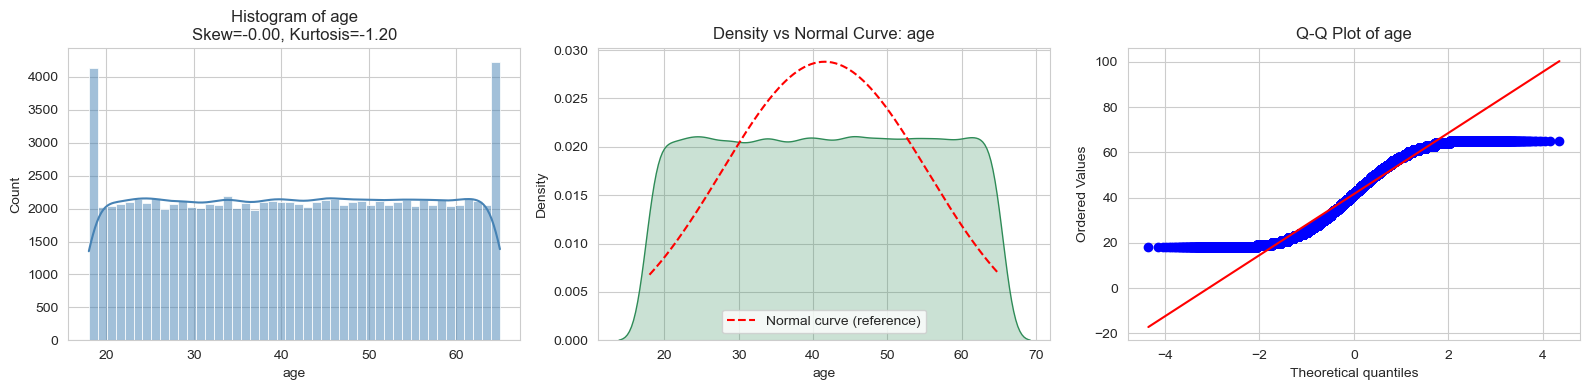

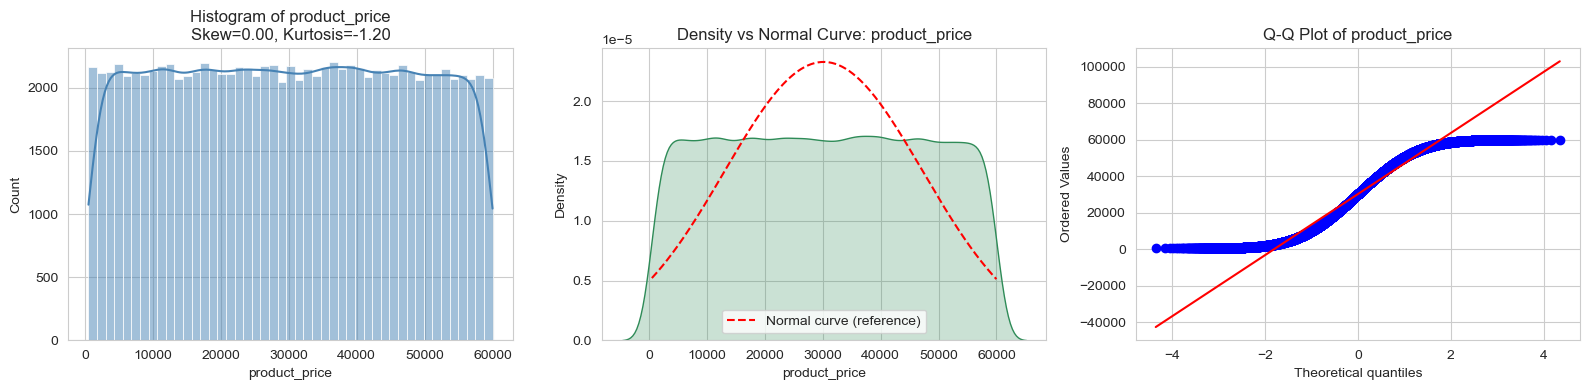

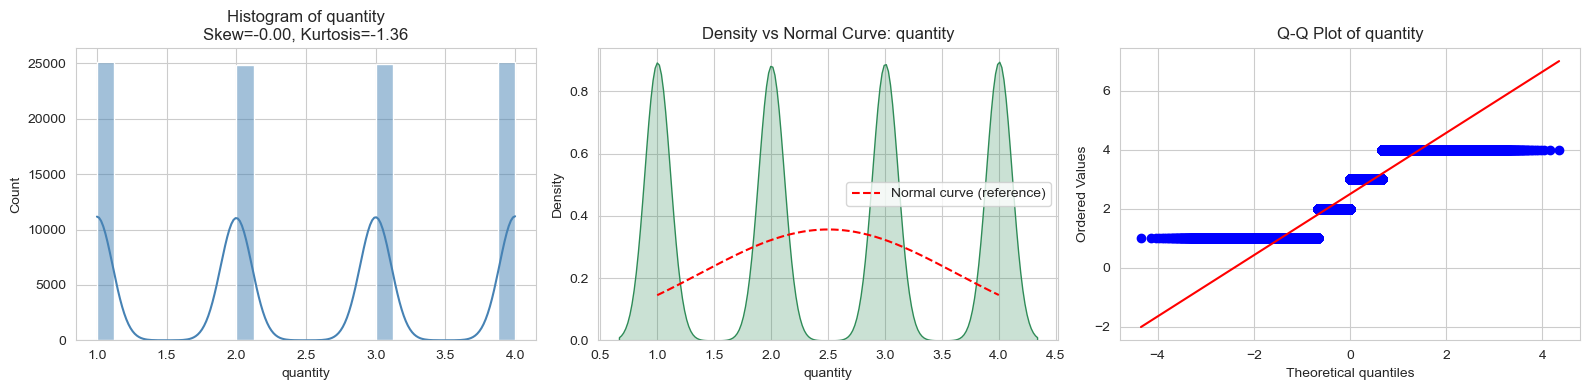

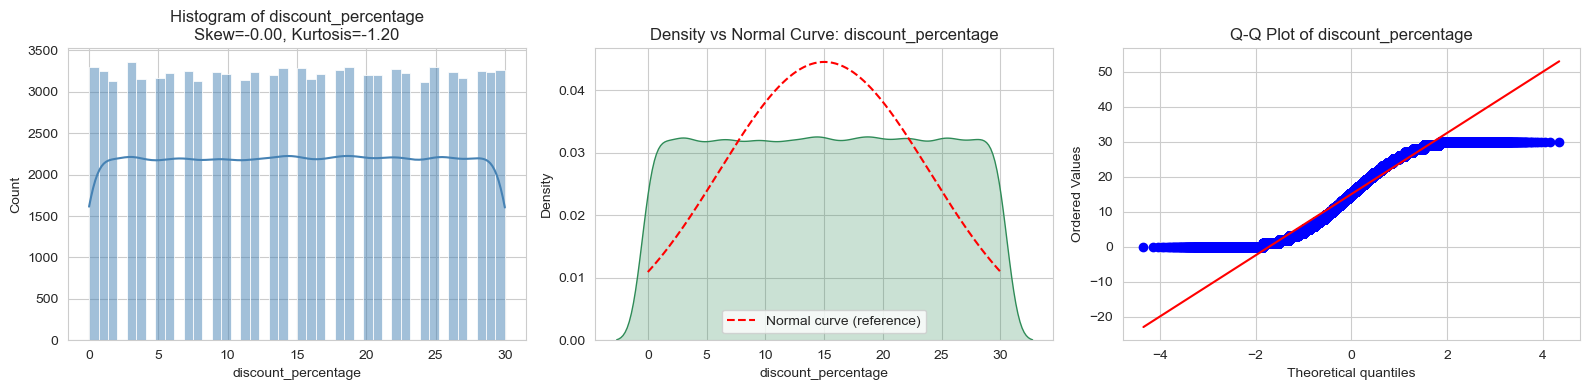

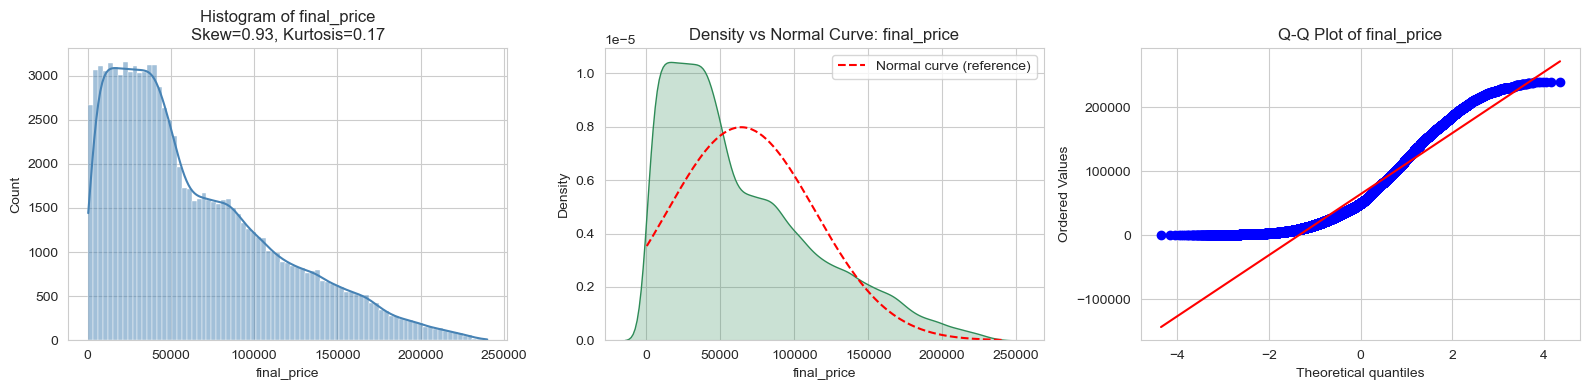

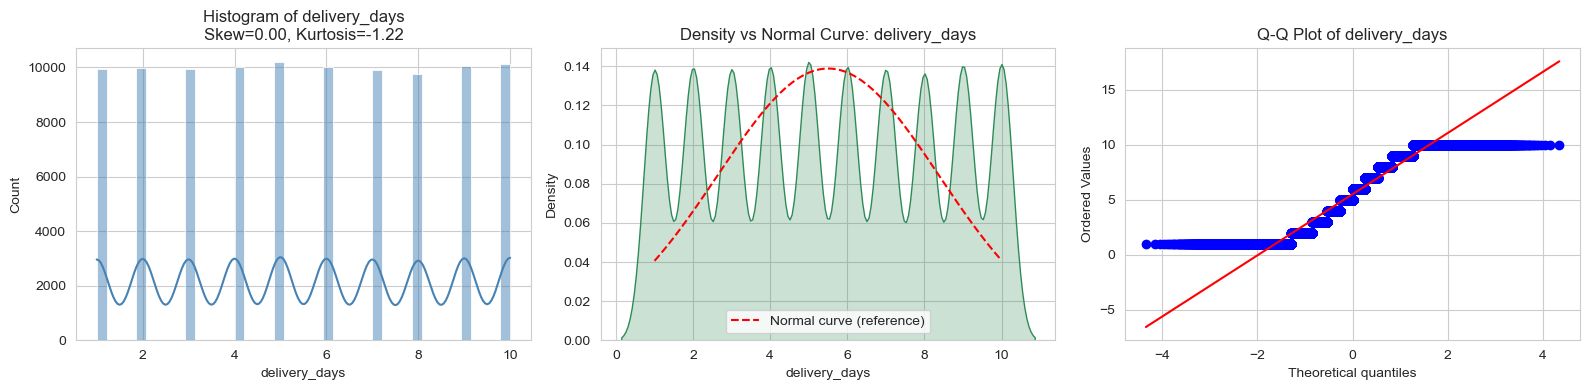

In [55]:

def plot_distribution_diagnostics(df, col):
    data = df[col].dropna()
 
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
 
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title(f'Histogram of {col}\nSkew={data.skew():.2f}, Kurtosis={data.kurt():.2f}')
 
    sns.kdeplot(data, fill=True, ax=axes[1], color='seagreen')
    # Overlay a normal curve with the same mean/std for visual comparison
    x = np.linspace(data.min(), data.max(), 200)
    normal_curve = stats.norm.pdf(x, data.mean(), data.std())
    axes[1].plot(x, normal_curve, color='red', linestyle='--', label='Normal curve (reference)')
    axes[1].set_title(f'Density vs Normal Curve: {col}')
    axes[1].legend()
 
    stats.probplot(data, dist="norm", plot=axes[2])
    axes[2].set_title(f'Q-Q Plot of {col}')
 
    plt.tight_layout()
    plt.show()
 
 
for col in NUMERIC_COLS:
    plot_distribution_diagnostics(df, col)

### 4. TRANSFORMATION SUGGESTIONS FOR SKEWED COLUMNS

In [62]:

def suggest_and_apply_transform(df, col):
    """
    Applies transformations to reduce skewness, only for columns that
    are meaningfully skewed (|skew| >= 0.5). Compares skewness before
    and after each transform so you can pick the best one.
    """
    data = df[col].dropna()
    original_skew = data.skew()
 
    if abs(original_skew) < 0.5:
        print(f"{col}: skew={original_skew:.2f} -> already close to symmetric, no transform needed")
        return None
 
    print(f"\n{col}: original skew = {original_skew:.2f} -> trying transformations...")
    candidates = {}

    # Log transform - only valid for positive values, best for right skew
    if (data > 0).all():
        log_data = np.log1p(data)
        candidates['log'] = log_data.skew()
 
    # Square root transform - milder than log, also needs non-negative values
    if (data >= 0).all():
        sqrt_data = np.sqrt(data)
        candidates['sqrt'] = sqrt_data.skew()
 
    # Box-Cox - finds the best power transform automatically, needs strictly positive values
    if (data > 0).all():
        boxcox_data, best_lambda = stats.boxcox(data)
        candidates['boxcox'] = pd.Series(boxcox_data).skew()
 
    for name, new_skew in candidates.items():
        print(f"   {name:8s} -> new skew = {new_skew:.3f}")
 
    best_transform = min(candidates, key=lambda k: abs(candidates[k]))
    print(f"   Best choice for {col}: {best_transform} "
          f"(skew {original_skew:.2f} -> {candidates[best_transform]:.2f})")
    return best_transform
 
 
df_transformed = df.copy()
for col in NUMERIC_COLS:
    best = suggest_and_apply_transform(df, col)
    if best == 'log':
        df_transformed[col + '_log'] = np.log1p(df[col])
    elif best == 'sqrt':
        df_transformed[col + '_sqrt'] = np.sqrt(df[col])
    elif best == 'boxcox':
        transformed, _ = stats.boxcox(df[col].dropna())
        df_transformed.loc[df[col].dropna().index, col + '_boxcox'] = transformed
 
 
 

age: skew=-0.00 -> already close to symmetric, no transform needed
product_price: skew=0.00 -> already close to symmetric, no transform needed
quantity: skew=-0.00 -> already close to symmetric, no transform needed
discount_percentage: skew=-0.00 -> already close to symmetric, no transform needed

final_price: original skew = 0.93 -> trying transformations...
   log      -> new skew = -0.986
   sqrt     -> new skew = 0.191
   boxcox   -> new skew = -0.085
   Best choice for final_price: boxcox (skew 0.93 -> -0.08)
delivery_days: skew=0.00 -> already close to symmetric, no transform needed


### 5. BEFORE / AFTER COMPARISON PLOT (example: most skewed column)

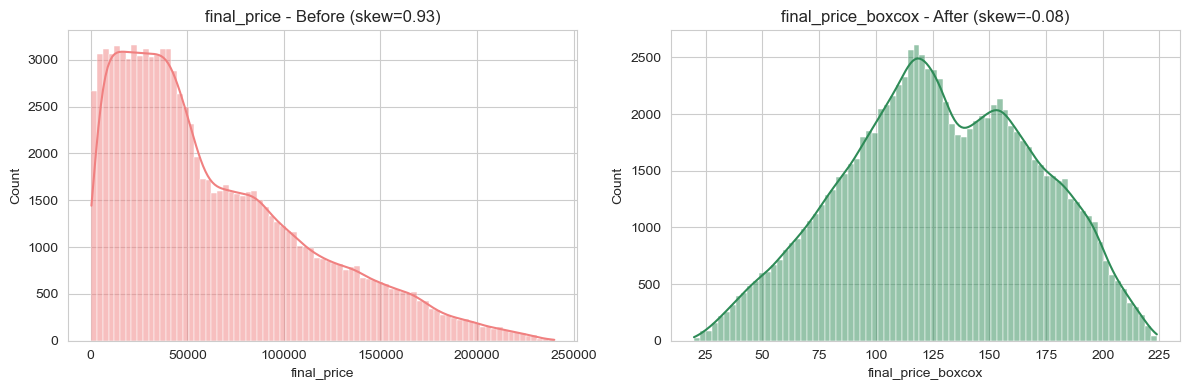

In [63]:
most_skewed_col = summary_df.loc[summary_df['skewness'].abs().idxmax(), 'column']
transformed_col = [c for c in df_transformed.columns if c.startswith(most_skewed_col + '_')]
 
if transformed_col:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[most_skewed_col].dropna(), kde=True, ax=axes[0], color='lightcoral')
    axes[0].set_title(f'{most_skewed_col} - Before (skew={df[most_skewed_col].skew():.2f})')
 
    sns.histplot(df_transformed[transformed_col[0]].dropna(), kde=True, ax=axes[1], color='seagreen')
    axes[1].set_title(f'{transformed_col[0]} - After '
                       f'(skew={df_transformed[transformed_col[0]].skew():.2f})')
    plt.tight_layout()
    plt.show()
 
       

## Key Statistical Findings - Validation

In [64]:
df

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,C109995,29,Female,Pune,Maharashtra,Regular,O149995,2024-06-11,Health,Supplements,49293,1,11,43870.77,Debit Card,Standard,9,No
99996,C109996,28,Male,Mumbai,Maharashtra,Premium,O149996,2024-04-27,Fashion,Men T-Shirt,5722,2,22,8926.32,Cash on Delivery,Express,1,No
99997,C109997,44,Female,Jaipur,Rajasthan,Premium,O149997,2024-04-14,Grocery,Snacks,6311,4,11,22467.16,Cash on Delivery,Express,9,No
99998,C109998,45,Male,Jaipur,Rajasthan,Premium,O149998,2024-09-08,Beauty,Shampoo,46888,1,28,33759.36,Debit Card,Standard,1,No


In [65]:
REVENUE_COL = 'final_price'   # treat final_price as the "revenue" per transaction

### FINDING 1: Revenue distribution is right-skewed


FINDING 1: Revenue distribution is right-skewed


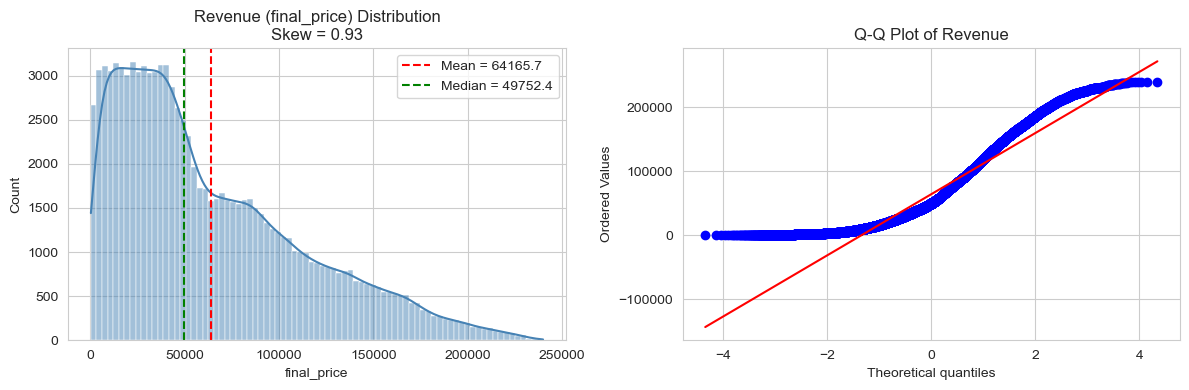

Skewness = 0.93, Mean = 64165.72, Median = 49752.39
VERDICT: CONFIRMED - mean > median with positive skew confirms a right-skewed revenue distribution.


In [66]:

print("\n" + "=" * 70)
print("FINDING 1: Revenue distribution is right-skewed")
print("=" * 70)
 
revenue = df[REVENUE_COL].dropna()
skew_val = revenue.skew()
mean_val, median_val = revenue.mean(), revenue.median()
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(revenue, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(mean_val, color='red', linestyle='--', label=f'Mean = {mean_val:.1f}')
axes[0].axvline(median_val, color='green', linestyle='--', label=f'Median = {median_val:.1f}')
axes[0].set_title(f'Revenue ({REVENUE_COL}) Distribution\nSkew = {skew_val:.2f}')
axes[0].legend()
 
stats.probplot(revenue, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Revenue')
plt.tight_layout()
plt.show()
 
print(f"Skewness = {skew_val:.2f}, Mean = {mean_val:.2f}, Median = {median_val:.2f}")
verdict1 = "CONFIRMED" if skew_val > 0.5 and mean_val > median_val else \
           "NOT SUPPORTED" if skew_val < -0.5 else "WEAK / INCONCLUSIVE"
print(f"VERDICT: {verdict1} - "
      f"{'mean > median with positive skew confirms a right-skewed revenue distribution.' if verdict1 == 'CONFIRMED' else 'check the numbers above - data does not show strong right skew.'}")

### FINDING 2: Revenue driven by limited high-value transactions (Pareto check)


FINDING 2: Revenue driven by a limited number of high-value transactions


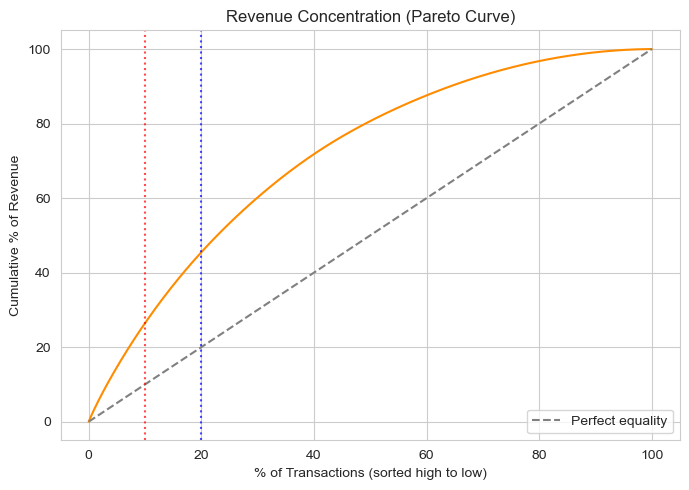

Top 10% of transactions generate 26.4% of total revenue.
Top 20% of transactions generate 45.5% of total revenue.
VERDICT: CONFIRMED - a small share of transactions clearly drives a disproportionate share of revenue.


In [67]:
print("\n" + "=" * 70)
print("FINDING 2: Revenue driven by a limited number of high-value transactions")
print("=" * 70)
 
sorted_rev = revenue.sort_values(ascending=False).reset_index(drop=True)
cum_pct_revenue = sorted_rev.cumsum() / sorted_rev.sum() * 100
cum_pct_transactions = (np.arange(1, len(sorted_rev) + 1) / len(sorted_rev)) * 100
 
# % of revenue coming from top 10% and top 20% of transactions
top10_idx = int(len(sorted_rev) * 0.10)
top20_idx = int(len(sorted_rev) * 0.20)
revenue_from_top10 = cum_pct_revenue.iloc[top10_idx - 1]
revenue_from_top20 = cum_pct_revenue.iloc[top20_idx - 1]
 
plt.figure(figsize=(7, 5))
plt.plot(cum_pct_transactions, cum_pct_revenue, color='darkorange')
plt.plot([0, 100], [0, 100], linestyle='--', color='gray', label='Perfect equality')
plt.axvline(10, color='red', linestyle=':', alpha=0.7)
plt.axvline(20, color='blue', linestyle=':', alpha=0.7)
plt.xlabel('% of Transactions (sorted high to low)')
plt.ylabel('Cumulative % of Revenue')
plt.title('Revenue Concentration (Pareto Curve)')
plt.legend()
plt.tight_layout()
plt.show()
 
print(f"Top 10% of transactions generate {revenue_from_top10:.1f}% of total revenue.")
print(f"Top 20% of transactions generate {revenue_from_top20:.1f}% of total revenue.")
 
verdict2 = "CONFIRMED" if revenue_from_top20 > 40 else "NOT SUPPORTED"
print(f"VERDICT: {verdict2} - "
      f"{'a small share of transactions clearly drives a disproportionate share of revenue.' if verdict2 == 'CONFIRMED' else 'revenue appears fairly evenly spread across transactions.'}")
 

### FINDING 3: Moderate discounts maximize spending


FINDING 3: Moderate discounts maximize spending
                           mean     median  count
discount_bin                                     
0-5% (none/low)    73663.396159  56246.495  19364
5-15% (low)        67604.162407  51922.590  32214
15-30% (moderate)  58080.084409  44688.630  48422
30-50% (high)               NaN        NaN      0
50%+ (very high)            NaN        NaN      0


C:\Users\Awinkya\AppData\Local\Temp\ipykernel_12620\4096526306.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_summary = df.groupby('discount_bin')['final_price'].agg(['mean', 'median', 'count'])
C:\Users\Awinkya\AppData\Local\Temp\ipykernel_12620\4096526306.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=discount_summary.index, y=discount_summary['mean'], palette='viridis')


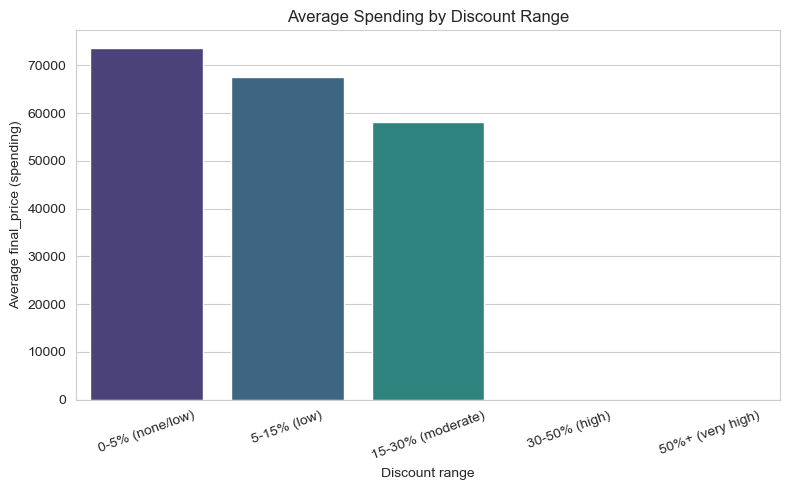

Spending peaks in the '0-5% (none/low)' discount range.
VERDICT: NOT SUPPORTED - peak spending occurs outside the moderate discount range - re-examine the claim.


In [69]:

print("\n" + "=" * 70)
print("FINDING 3: Moderate discounts maximize spending")
print("=" * 70)
 
# Bin discount_percentage into ranges and compare average final_price per bin
bins = [-0.01, 5, 15, 30, 50, 100]
labels = ['0-5% (none/low)', '5-15% (low)', '15-30% (moderate)', '30-50% (high)', '50%+ (very high)']
df['discount_bin'] = pd.cut(df['discount_percentage'], bins=bins, labels=labels)
 
discount_summary = df.groupby('discount_bin')['final_price'].agg(['mean', 'median', 'count'])
print(discount_summary)
 
plt.figure(figsize=(8, 5))
sns.barplot(x=discount_summary.index, y=discount_summary['mean'], palette='viridis')
plt.ylabel('Average final_price (spending)')
plt.xlabel('Discount range')
plt.title('Average Spending by Discount Range')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
 
peak_bin = discount_summary['mean'].idxmax()
verdict3 = "CONFIRMED" if peak_bin in ['15-30% (moderate)', '30-50% (high)'] else "NOT SUPPORTED"
print(f"Spending peaks in the '{peak_bin}' discount range.")
print(f"VERDICT: {verdict3} - "
      f"{'moderate discount levels correspond to the highest average spending.' if verdict3 == 'CONFIRMED' else 'peak spending occurs outside the moderate discount range - re-examine the claim.'}")
 

### FINDING 4: Outliers represent genuine premium purchases

In [70]:

print("\n" + "=" * 70)
print("FINDING 4: Outliers represent genuine premium purchases")
print("=" * 70)
 
Q1, Q3 = revenue.quantile(0.25), revenue.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
outlier_mask = df[REVENUE_COL] > upper_bound
 
print(f"{outlier_mask.sum()} outlier transactions found above {upper_bound:.2f} "
      f"({outlier_mask.sum()/len(df)*100:.2f}% of data).")
 
# Check 1: are outliers concentrated in premium product categories?
if 'product_category' in df.columns:
    outlier_categories = df.loc[outlier_mask, 'product_category'].value_counts(normalize=True) * 100
    normal_categories = df.loc[~outlier_mask, 'product_category'].value_counts(normalize=True) * 100
    print("\nProduct category share - Outliers vs Normal transactions:")
    print(pd.concat([outlier_categories, normal_categories], axis=1,
                     keys=['Outliers %', 'Normal %']).fillna(0).round(1))
 


FINDING 4: Outliers represent genuine premium purchases
1335 outlier transactions found above 198057.67 (1.33% of data).

Product category share - Outliers vs Normal transactions:
                  Outliers %  Normal %
product_category                      
Grocery                 18.5      16.6
Beauty                  17.6      16.5
Home & Kitchen          17.6      16.8
Electronics             15.8      16.6
Fashion                 15.3      16.6
Health                  15.2      16.9


### Check 2: are outliers more likely to be returned? (if they were data errors,we might expect higher return rates; if genuine premium buys, similar or lower)


Return rate among outlier transactions : 0.00%
Return rate among normal transactions  : 0.00%
VERDICT: CONFIRMED - outliers do not show a meaningfully higher return rate, consistent with genuine premium purchases rather than errors.


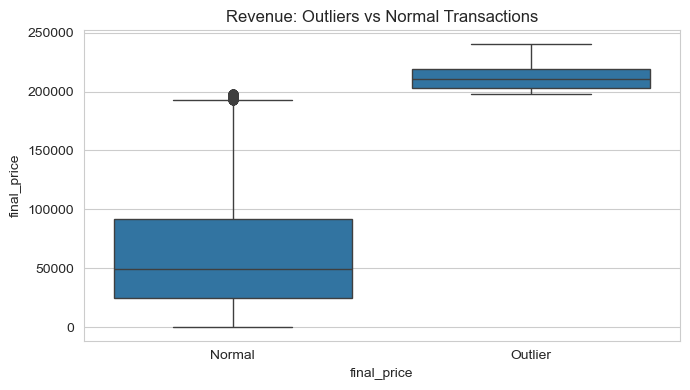

In [71]:

if 'return_status' in df.columns:
    return_rate_outliers = (df.loc[outlier_mask, 'return_status'].str.lower() == 'returned').mean() * 100
    return_rate_normal = (df.loc[~outlier_mask, 'return_status'].str.lower() == 'returned').mean() * 100
    print(f"\nReturn rate among outlier transactions : {return_rate_outliers:.2f}%")
    print(f"Return rate among normal transactions  : {return_rate_normal:.2f}%")
 
    verdict4 = "CONFIRMED" if return_rate_outliers <= return_rate_normal * 1.2 else "NOT SUPPORTED"
    print(f"VERDICT: {verdict4} - "
          f"{'outliers do not show a meaningfully higher return rate, consistent with genuine premium purchases rather than errors.' if verdict4 == 'CONFIRMED' else 'outliers show a notably higher return rate, which may indicate data quality issues rather than genuine premium purchases.'}")
 
plt.figure(figsize=(7, 4))
sns.boxplot(x=outlier_mask.map({True: 'Outlier', False: 'Normal'}), y=df[REVENUE_COL])
plt.title('Revenue: Outliers vs Normal Transactions')
plt.tight_layout()
plt.show()

### FINDING 5: Return probability increases with longer delivery times


FINDING 5: Return probability increases slightly with longer delivery times
Return rate (%) by delivery-time quintile:
 delivery_days
(0.999, 3.0]    0.0
(3.0, 5.0]      0.0
(5.0, 6.0]      0.0
(6.0, 9.0]      0.0
(9.0, 10.0]     0.0
Name: is_returned, dtype: float64


C:\Users\Awinkya\AppData\Local\Temp\ipykernel_12620\2760762241.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return_rate_by_delivery = df.groupby(delivery_bins)['is_returned'].mean() * 100


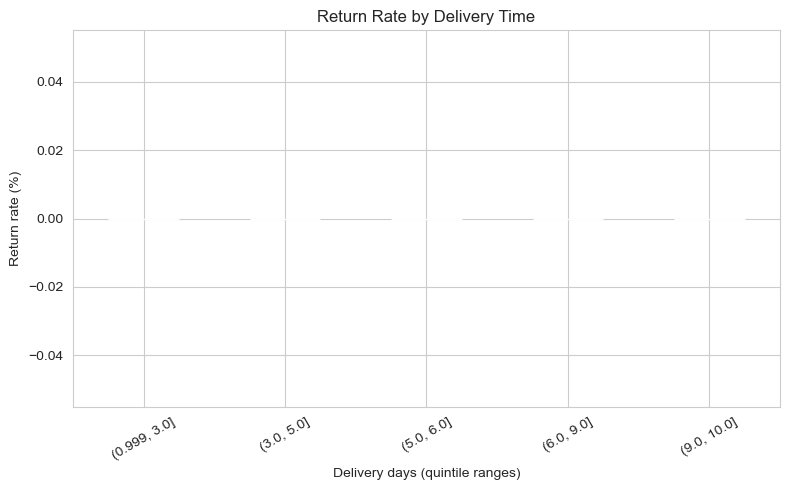


Point-biserial correlation (delivery_days vs is_returned): r = nan, p = nan
VERDICT: WEAK EVIDENCE - no statistically significant relationship found between delivery time and returns.


C:\Users\Awinkya\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


In [75]:

print("\n" + "=" * 70)
print("FINDING 5: Return probability increases slightly with longer delivery times")
print("=" * 70)
 
if 'return_status' in df.columns and 'delivery_days' in df.columns:
    df['is_returned'] = (df['return_status'].str.lower() == 'returned').astype(int)
 
    # Bin delivery days and compute return rate per bin
    delivery_bins = pd.qcut(df['delivery_days'], q=5, duplicates='drop')
    return_rate_by_delivery = df.groupby(delivery_bins)['is_returned'].mean() * 100
 
    print("Return rate (%) by delivery-time quintile:\n", return_rate_by_delivery)
 
    plt.figure(figsize=(8, 5))
    return_rate_by_delivery.plot(kind='bar', color='coral')
    plt.ylabel('Return rate (%)')
    plt.xlabel('Delivery days (quintile ranges)')
    plt.title('Return Rate by Delivery Time')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
 
    # Point-biserial correlation between delivery_days (continuous) and is_returned (binary)
    corr, p_val = stats.pointbiserialr(df['is_returned'], df['delivery_days'])
    print(f"\nPoint-biserial correlation (delivery_days vs is_returned): "
          f"r = {corr:.3f}, p = {p_val:.4g}")
 
    verdict5 = "CONFIRMED" if corr > 0 and p_val < 0.05 else \
               "NOT SUPPORTED" if p_val >= 0.05 else "WEAK EVIDENCE"
    print(f"VERDICT: {verdict5} - "
          f"{'a statistically significant positive relationship exists between delivery time and returns.' if verdict5 == 'CONFIRMED' else 'no statistically significant relationship found between delivery time and returns.'}")
 
 
